在12中,我们更加频繁的更新了模型的权重.但是对于一些持续上涨的状况,如铜价持续上涨,模型虽然把近期的误差纳入训练,但是等权MSE近期的误差占比仍然很小.因此,为了提高近期的影响,我们使用加权MSE进行实验.

# A 等权训练 vs B 加权 MSE（半衰期 60）

A：沿用12的逐月重训方案；复用前三个月验证所选的种子，把预测月之前全部可用数据纳入训练。B：同一训练集、同一种子、相同标准化器拟合方式及超参数，只更换训练损失。两阶段都采用对应损失，第一阶段冻结后以样本内预测训练第二阶段。

半衰期按 **60条有效日度记录**，不是60个日历日；数据一年有271条记录，因此也不直接称60个交易日。以每次训练集最新一条记录为年龄0，向前递增：

$$w_i=2^{-a_i/60},\qquad L_B=\frac{\sum_i w_i(\hat y_i-y_i)^2}{\sum_i w_i},\qquad L_A=\frac1N\sum_i(\hat y_i-y_i)^2.$$

损失在标准化目标上计算；归一化权重均值为1，避免仅因损失尺度变化改变优化强度。标准化仍等权拟合，避免同时更改预处理。保持16→32隐藏层、ReLU、Adam学习率0.01、全批量、两阶段各100轮，每月重新初始化。

为单独比较损失，不为B另选种子。复用A种子有利于配对控制，但本实验不能代表B独立调参后的最佳表现。以2020年相同日期普通MSE、MAPE比较；报告月度与全年结果，不以测试误差反向选择半衰期。

输入包含同日市场数据，这是历史同日股价拟合的样本外实验；2020年已被多次查看，不是新的盲测。


In [1]:
from pathlib import Path
import os,json,hashlib,random
import numpy as np
import pandas as pd
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import display,Image
ROOT=next((p for p in [Path.cwd(),*Path.cwd().parents] if (p/'src/pickle/Dataset.pkl').exists()),Path('/Users/admin/数据分析/ZiJin-Mining/ZiJin-Mining-stock-prediction-'))
OUT=Path(os.environ.get('MLP13_OUT',str(ROOT/'results/mlp_weighted_mse_13')));OUT.mkdir(parents=True,exist_ok=True)
SEEDS=[965409, 640934, 550343, 798291, 374583, 42716, 785634, 565766, 385735, 741131]
EXCLUDED_SEEDS=[0, 1, 7, 21, 42, 100, 123, 999, 2024, 2025]
EPOCHS=100;LR=0.01;VALIDATION_MONTHS=3
torch.set_num_threads(1);torch.use_deterministic_algorithms(True)
assert len(set(SEEDS))==10 and not set(SEEDS)&set(EXCLUDED_SEEDS)
dataset=ROOT/'src/pickle/Dataset.pkl';d=pd.read_pickle(dataset)
raw=d['X'].copy();target=d['Y'].copy();assert raw.index.equals(target.index)
assert raw.index.is_unique and raw.index.is_monotonic_increasing
raw=raw.loc[raw.index<'2021-01-01'];BASE=list(raw.columns);assert len(BASE)==7
y=pd.Series(np.asarray(target).reshape(-1),index=target.index,name='Actual').loc[raw.index]
x=raw.copy();RETURNS=[]
for metal,col in [('gold','Gold Futures Price'),('copper','Copper Futures Price')]:
    name=f'{metal}_daily';x[name]=raw[col]/raw[col].shift(1)-1;RETURNS.append(name)
    for k in [5,20]:
        name=f'{metal}_vs_ma{k}';x[name]=raw[col]/raw[col].rolling(k,min_periods=k).mean()-1;RETURNS.append(name)
valid=np.isfinite(x.to_numpy()).all(axis=1)&np.isfinite(y.to_numpy())
x=x.loc[valid];y=y.loc[x.index];assert (y>0).all()
whole=x.index[x.index.year==2020];assert len(whole)==271
config=dict(seeds=SEEDS,excluded_prior_seeds=EXCLUDED_SEEDS,epochs_per_stage=EPOCHS,validation_months=VALIDATION_MONTHS,hidden=[16,32],activation='ReLU',optimizer='Adam',lr=LR,batch='full',base_features=BASE,stage2_features=['base_prediction']+RETURNS,stage2_training='in-sample predictions; base frozen',refit_after_selection=False,target='same-date original price',selection='minimum preceding-three-calendar-month MAPE; ties by candidate order',test_year=2020,dataset_sha256=hashlib.sha256(dataset.read_bytes()).hexdigest(),torch_version=str(torch.__version__))
(OUT/'config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))
x.join(y).to_csv(OUT/'features_and_target.csv',index_label='Date')
print('Frozen candidate seeds:',SEEDS)


HALF_LIFE=60
PRIOR=OUT.parent/'mlp_monthly_refit_12'
if not (PRIOR/'reused_selection.csv').exists(): PRIOR=ROOT/'results/mlp_monthly_refit_12'
selection=pd.read_csv(PRIOR/'reused_selection.csv')
previous=pd.read_csv(PRIOR/'stitched_comparison.csv',parse_dates=['Date'])
prior_config=json.loads((PRIOR/'config.json').read_text())
assert prior_config['dataset_sha256']==config['dataset_sha256']
config.update(half_life=HALF_LIFE,age_unit='valid observations',weight_normalization='sum(weights)',weighted_stages=['Base','Stacking'],scaler='unweighted StandardScaler',refit_after_selection=True,selection='reuse A seeds; no B reranking',selection_sha256=hashlib.sha256((PRIOR/'reused_selection.csv').read_bytes()).hexdigest())
(OUT/'config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))
selection.to_csv(OUT/'reused_selection.csv',index=False)


Frozen candidate seeds: [965409, 640934, 550343, 798291, 374583, 42716, 785634, 565766, 385735, 741131]


In [2]:
history=[]
def fit_stage(X,train_idx,seed,stage,month):
    random.seed(seed);np.random.seed(seed);torch.manual_seed(seed)
    sx=StandardScaler().fit(X.loc[train_idx]);sy=StandardScaler().fit(y.loc[train_idx].to_numpy().reshape(-1,1))
    xt=torch.tensor(sx.transform(X.loc[train_idx]),dtype=torch.float32);yt=torch.tensor(sy.transform(y.loc[train_idx].to_numpy().reshape(-1,1)),dtype=torch.float32)
    model=nn.Sequential(nn.Linear(X.shape[1],16),nn.ReLU(),nn.Linear(16,32),nn.ReLU(),nn.Linear(32,1))
    ages=np.arange(len(train_idx)-1,-1,-1)
    weights=np.ones(len(train_idx)) if METHOD=='A' else 2.0**(-ages/HALF_LIFE)
    wt=torch.tensor(weights/weights.mean(),dtype=torch.float32).reshape(-1,1)
    opt=torch.optim.Adam(model.parameters(),lr=LR)
    for epoch in range(1,EPOCHS+1):
        model.train();opt.zero_grad();loss=(wt*(model(xt)-yt)**2).mean();assert torch.isfinite(loss)
        loss.backward();opt.step();model.eval()
        with torch.no_grad():z=model(xt).numpy()
        p=sy.inverse_transform(z).ravel();mse=float(np.mean((p-y.loc[train_idx].to_numpy())**2))
        history.append(dict(Method=METHOD,Month=month,Seed=seed,Stage=stage,Epoch=epoch,Weighted_MSE=float(np.average((p-y.loc[train_idx].to_numpy())**2,weights=weights)),Train_MSE=mse,Train_MSE_standardized=mse/float(sy.scale_[0]**2)))
    torch.save(dict(state_dict=model.state_dict(),features=list(X.columns),seed=seed,epochs=EPOCHS,train_start=str(train_idx.min()),train_end=str(train_idx.max()),sx_mean=sx.mean_.tolist(),sx_scale=sx.scale_.tolist(),sy_mean=sy.mean_.tolist(),sy_scale=sy.scale_.tolist()),OUT/f'{METHOD}_{month}_{stage}_seed{seed}.pt')
    return model,sx,sy

def predict(bundle,X):
    model,sx,sy=bundle;model.eval()
    with torch.no_grad():z=model(torch.tensor(sx.transform(X),dtype=torch.float32)).numpy()
    p=sy.inverse_transform(z).ravel();assert np.isfinite(p).all();return pd.Series(p,index=X.index)

def score(pred,idx):
    err=pred.loc[idx].to_numpy()-y.loc[idx].to_numpy()
    return dict(N=len(idx),MAPE=float(100*np.mean(np.abs(err)/np.abs(y.loc[idx].to_numpy()))),MSE=float(np.mean(err**2)))

def stack_predict(base,stack,X):
    bp=predict(base,X[BASE]);meta=X[RETURNS].copy();meta.insert(0,'base_prediction',bp)
    return predict(stack,meta)



In [3]:
frames=[];splits=[];weight_rows=[]
for row in selection.itertuples(index=False):
    month=row.Month;seed=int(row.Selected_seed);start=pd.Timestamp(month+'-01');end=start+pd.DateOffset(months=1)
    tr=x.index[x.index<start];te=x.index[(x.index>=start)&(x.index<end)]
    assert tr.max()<te.min()
    ages=np.arange(len(tr)-1,-1,-1);w=2.0**(-ages/HALF_LIFE)
    assert np.isclose(w[-61]/w[-1],.5)
    weight_rows.append(dict(Month=month,N=len(tr),Effective_sample_size=w.sum()**2/(w*w).sum(),Recent60_weight_share=w[-60:].sum()/w.sum()))
    for split,idx in [('Train',tr),('Test',te)]:splits.append(dict(Month=month,Split=split,N=len(idx),Start=str(idx.min().date()),End=str(idx.max().date())))
    result=pd.DataFrame(dict(Date=te,Month=month,Seed=seed,Actual=y.loc[te].to_numpy()))
    for METHOD in ['A','B']:
        known=x.loc[tr]
        base=fit_stage(known[BASE],tr,seed,'Base',month)
        meta=known[RETURNS].copy();meta.insert(0,'base_prediction',predict(base,known[BASE]))
        stack=fit_stage(meta,tr,seed,'Stacking',month)
        result[METHOD]=stack_predict(base,stack,x.loc[te]).to_numpy()
    frames.append(result)
    print(month,'completed',flush=True)
comparison=pd.concat(frames,ignore_index=True)
assert comparison.Date.is_unique and pd.DatetimeIndex(comparison.Date).equals(whole)
assert np.allclose(comparison.A,previous.set_index('Date').loc[comparison.Date,'Refit_prediction'],rtol=0,atol=1e-6), 'A must reproduce prior monthly refit'
rows=[]
for month,g in comparison.groupby('Month'):
    r=dict(Month=month,N=len(g))
    for method in ['A','B']:
        err=g[method]-g.Actual
        r[method+'_MAPE']=100*(err.abs()/g.Actual.abs()).mean();r[method+'_MSE']=(err**2).mean()
    r['B_minus_A_MAPE_pp']=r['B_MAPE']-r['A_MAPE'];r['B_minus_A_MSE']=r['B_MSE']-r['A_MSE'];rows.append(r)
monthly=pd.DataFrame(rows)
summary=pd.DataFrame([dict(Method=method,Annual_MSE=((comparison[method]-comparison.Actual)**2).mean(),Annual_MAPE=100*((comparison[method]-comparison.Actual).abs()/comparison.Actual.abs()).mean(),Monthly_equal_MAPE=monthly[method+'_MAPE'].mean()) for method in ['A','B']])
assert len(history)==4800
for name,frame in [('predictions',comparison),('monthly_comparison',monthly),('summary',summary),('splits',pd.DataFrame(splits)),('weight_diagnostics',pd.DataFrame(weight_rows)),('training_history',pd.DataFrame(history))]:frame.to_csv(OUT/f'{name}.csv',index=False)
display(summary.round(5));display(monthly.round(5));display(pd.DataFrame(weight_rows).round(4))
print('B improves monthly MAPE:',int((monthly.B_minus_A_MAPE_pp<0).sum()),'/12')
print('A reproduction verified against 12; train/test chronology and half-life verified.')


,Method,Annual_MSE,Annual_MAPE,Monthly_equal_MAPE
0,A,0.33809,8.14992,8.15282
1,B,0.25027,6.65766,6.73328


,Month,N,A_MAPE,A_MSE,B_MAPE,B_MSE,B_minus_A_MAPE_pp,B_minus_A_MSE
0,2020-01,24,8.46359,0.17072,5.41813,0.08200,-3.04546,-0.08872
1,2020-02,21,6.28027,0.09135,9.12746,0.18983,2.84719,0.09848
2,2020-03,22,10.84908,0.26235,5.63887,0.07003,-5.21021,-0.19231
3,2020-04,23,7.38192,0.12098,3.02372,0.02325,-4.35820,-0.09773
4,2020-05,23,4.24132,0.03969,4.28797,0.04238,0.04665,0.00269
5,2020-06,23,9.28895,0.15408,6.66233,0.09103,-2.62662,-0.06305
6,2020-07,23,14.01698,0.73172,7.17390,0.22510,-6.84309,-0.50662
7,2020-08,21,5.47506,0.17177,9.14712,0.43597,3.67206,0.26420
8,2020-09,24,11.49300,0.69790,6.28722,0.23293,-5.20578,-0.46497
9,2020-10,23,3.69089,0.08192,6.62530,0.22484,2.93440,0.14292


,Month,N,Effective_sample_size,Recent60_weight_share
0,2020-01,2035,173.1253,0.5
1,2020-02,2059,173.1253,0.5
2,2020-03,2080,173.1253,0.5
3,2020-04,2102,173.1253,0.5
4,2020-05,2125,173.1253,0.5
5,2020-06,2148,173.1253,0.5
6,2020-07,2171,173.1253,0.5
7,2020-08,2194,173.1253,0.5
8,2020-09,2215,173.1253,0.5
9,2020-10,2239,173.1253,0.5


2020-01 completed
2020-02 completed
2020-03 completed
2020-04 completed
2020-05 completed
2020-06 completed
2020-07 completed
2020-08 completed
2020-09 completed
2020-10 completed
2020-11 completed
2020-12 completed
B improves monthly MAPE: 7 /12
A reproduction verified against 12; train/test chronology and half-life verified.


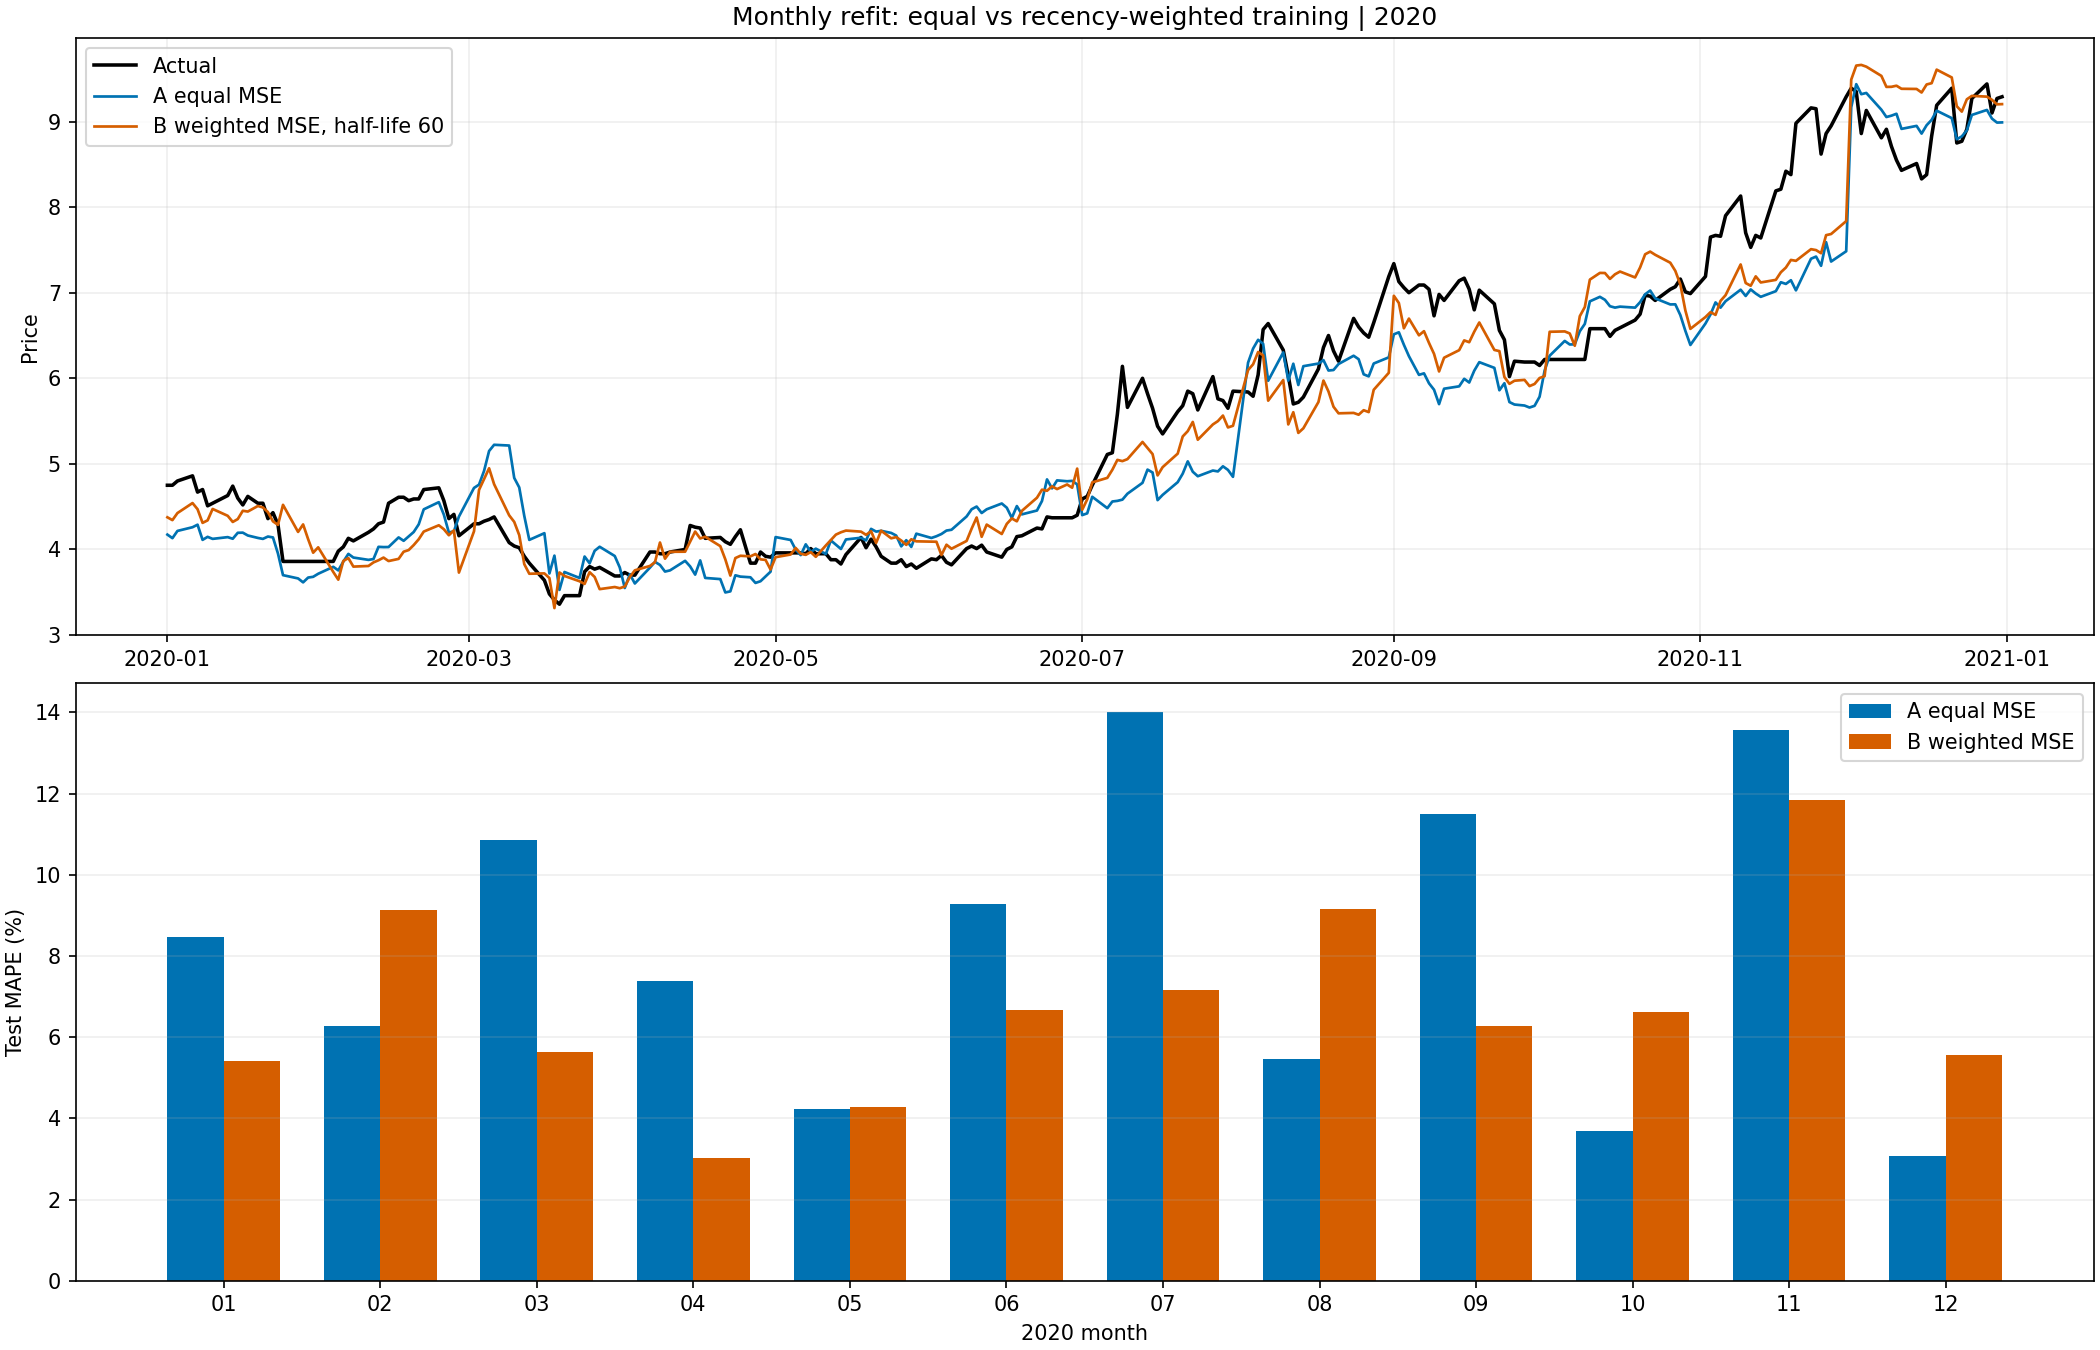

In [4]:
fig,axes=plt.subplots(2,1,figsize=(14,9),constrained_layout=True)
axes[0].plot(comparison.Date,comparison.Actual,color='black',label='Actual',lw=1.7)
for method,color in [('A','#0072B2'),('B','#D55E00')]:
    axes[0].plot(comparison.Date,comparison[method],label=method+(' equal MSE' if method=='A' else ' weighted MSE, half-life 60'),color=color,lw=1.3)
axes[0].set(title='Monthly refit: equal vs recency-weighted training | 2020',ylabel='Price');axes[0].legend();axes[0].grid(alpha=.2)
p=np.arange(12)
axes[1].bar(p-.18,monthly.A_MAPE,width=.36,label='A equal MSE',color='#0072B2');axes[1].bar(p+.18,monthly.B_MAPE,width=.36,label='B weighted MSE',color='#D55E00')
axes[1].set(xticks=p,xticklabels=monthly.Month.str[-2:],ylabel='Test MAPE (%)',xlabel='2020 month');axes[1].legend();axes[1].grid(axis='y',alpha=.2)
fig.savefig(OUT/'comparison.png',dpi=150);plt.close(fig);display(Image(filename=str(OUT/'comparison.png')))


## 本次结果

| 测试指标 | A 等权 MSE | B 加权 MSE（60） |
|---|---:|---:|
| 全年逐记录 MAPE | 8.1499% | 6.6577% |
| 全年普通 MSE | 0.338087 | 0.250269 |
| 12个月等权平均 MAPE | 8.1528% | 6.7333% |

B全年MAPE下降1.4923个百分点（相对下降18.31%），普通MSE下降25.98%。7/12个月的MAPE改善，7月改善最大（14.02%→7.17%），8月退步最大（5.48%→9.15%）；2、5、8、10、12月误差上升。

**结论：在固定A种子、固定100轮等条件下，半衰期60的加权训练改善了2020年的总体误差，但并非逐月稳定改善。** 这不足以证明60是最优半衰期，也不能仅凭误差改善断言具体由铜价趋势引起。后续比较保留A作为统一基准。

验证已通过：A复现12中原预测（绝对容差1e-6）；每月训练截止日期严格早于测试；60条记录权重减半；271条测试记录日期唯一且对齐；共4800条逐轮训练记录。


看来加上近期的修正后,总体的误差得以改善.我们再尝试一下不同的半衰期.此外可以看出,一个月更新一次仍然会有较明显的跳变问题.

# 扩展比较：半衰期30、60、120、240与等权A

延续上一节控制条件，新增30、120、240条有效日度记录的半衰期。复用A和60的已验证预测；每月仍使用同一既定种子、月前全部历史、两阶段各100轮、等权标准化，仅改变两阶段损失的时间权重。B不单独重新选择种子。

统一用同一271条2020年测试记录计算普通MSE与MAPE，同时报告12个月等权MAPE、相对A改善月份数、最差月份MAPE。不同方案的加权训练损失不可直接横向作为优劣依据。2020年结果仅用于探索，不能据此证明最优半衰期能泛化到未参与选择的年份。


In [1]:
from pathlib import Path
import os,json,hashlib,random
import numpy as np
import pandas as pd
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import display,Image
ROOT=next((p for p in [Path.cwd(),*Path.cwd().parents] if (p/'src/pickle/Dataset.pkl').exists()),Path('/Users/admin/数据分析/ZiJin-Mining/ZiJin-Mining-stock-prediction-'))
OUT=Path(os.environ.get('MLP13_GRID_OUT',str(ROOT/'results/mlp_half_life_comparison_13')));OUT.mkdir(parents=True,exist_ok=True)
SEEDS=[965409, 640934, 550343, 798291, 374583, 42716, 785634, 565766, 385735, 741131]
EXCLUDED_SEEDS=[0, 1, 7, 21, 42, 100, 123, 999, 2024, 2025]
EPOCHS=100;LR=0.01;VALIDATION_MONTHS=3
torch.set_num_threads(1);torch.use_deterministic_algorithms(True)
assert len(set(SEEDS))==10 and not set(SEEDS)&set(EXCLUDED_SEEDS)
dataset=ROOT/'src/pickle/Dataset.pkl';d=pd.read_pickle(dataset)
raw=d['X'].copy();target=d['Y'].copy();assert raw.index.equals(target.index)
assert raw.index.is_unique and raw.index.is_monotonic_increasing
raw=raw.loc[raw.index<'2021-01-01'];BASE=list(raw.columns);assert len(BASE)==7
y=pd.Series(np.asarray(target).reshape(-1),index=target.index,name='Actual').loc[raw.index]
x=raw.copy();RETURNS=[]
for metal,col in [('gold','Gold Futures Price'),('copper','Copper Futures Price')]:
    name=f'{metal}_daily';x[name]=raw[col]/raw[col].shift(1)-1;RETURNS.append(name)
    for k in [5,20]:
        name=f'{metal}_vs_ma{k}';x[name]=raw[col]/raw[col].rolling(k,min_periods=k).mean()-1;RETURNS.append(name)
valid=np.isfinite(x.to_numpy()).all(axis=1)&np.isfinite(y.to_numpy())
x=x.loc[valid];y=y.loc[x.index];assert (y>0).all()
whole=x.index[x.index.year==2020];assert len(whole)==271
config=dict(seeds=SEEDS,excluded_prior_seeds=EXCLUDED_SEEDS,epochs_per_stage=EPOCHS,validation_months=VALIDATION_MONTHS,hidden=[16,32],activation='ReLU',optimizer='Adam',lr=LR,batch='full',base_features=BASE,stage2_features=['base_prediction']+RETURNS,stage2_training='in-sample predictions; base frozen',refit_after_selection=False,target='same-date original price',selection='minimum preceding-three-calendar-month MAPE; ties by candidate order',test_year=2020,dataset_sha256=hashlib.sha256(dataset.read_bytes()).hexdigest(),torch_version=str(torch.__version__))
(OUT/'config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))
x.join(y).to_csv(OUT/'features_and_target.csv',index_label='Date')
print('Frozen candidate seeds:',SEEDS)


HALF_LIFE=60
PRIOR=OUT.parent/'mlp_monthly_refit_12'
if not (PRIOR/'reused_selection.csv').exists(): PRIOR=ROOT/'results/mlp_monthly_refit_12'
selection=pd.read_csv(PRIOR/'reused_selection.csv')
previous=pd.read_csv(PRIOR/'stitched_comparison.csv',parse_dates=['Date'])
prior_config=json.loads((PRIOR/'config.json').read_text())
assert prior_config['dataset_sha256']==config['dataset_sha256']
config.update(half_life=HALF_LIFE,age_unit='valid observations',weight_normalization='sum(weights)',weighted_stages=['Base','Stacking'],scaler='unweighted StandardScaler',refit_after_selection=True,selection='reuse A seeds; no B reranking',selection_sha256=hashlib.sha256((PRIOR/'reused_selection.csv').read_bytes()).hexdigest())
(OUT/'config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))
selection.to_csv(OUT/'reused_selection.csv',index=False)

config.update(half_lives=[30,60,120,240],reused_methods=['A','H60'])
config.pop('half_life',None)
(OUT/'config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))
CACHED=OUT.parent/'mlp_weighted_mse_13'
if not (CACHED/'predictions.csv').exists(): CACHED=ROOT/'results/mlp_weighted_mse_13'
cached_config=json.loads((CACHED/'config.json').read_text())
assert cached_config['dataset_sha256']==config['dataset_sha256']
assert cached_config['selection_sha256']==config['selection_sha256']
comparison=pd.read_csv(CACHED/'predictions.csv',parse_dates=['Date']).rename(columns={'B':'H60'})
assert pd.DatetimeIndex(comparison.Date).equals(whole)
assert np.allclose(comparison.Actual,y.loc[whole])
config['cached_predictions_sha256']=hashlib.sha256((CACHED/'predictions.csv').read_bytes()).hexdigest()
(OUT/'config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))


Frozen candidate seeds: [965409, 640934, 550343, 798291, 374583, 42716, 785634, 565766, 385735, 741131]


In [2]:
history=[]
def fit_stage(X,train_idx,seed,stage,month):
    random.seed(seed);np.random.seed(seed);torch.manual_seed(seed)
    sx=StandardScaler().fit(X.loc[train_idx]);sy=StandardScaler().fit(y.loc[train_idx].to_numpy().reshape(-1,1))
    xt=torch.tensor(sx.transform(X.loc[train_idx]),dtype=torch.float32);yt=torch.tensor(sy.transform(y.loc[train_idx].to_numpy().reshape(-1,1)),dtype=torch.float32)
    model=nn.Sequential(nn.Linear(X.shape[1],16),nn.ReLU(),nn.Linear(16,32),nn.ReLU(),nn.Linear(32,1))
    ages=np.arange(len(train_idx)-1,-1,-1)
    weights=np.ones(len(train_idx)) if METHOD=='A' else 2.0**(-ages/HALF_LIFE)
    wt=torch.tensor(weights/weights.mean(),dtype=torch.float32).reshape(-1,1)
    opt=torch.optim.Adam(model.parameters(),lr=LR)
    for epoch in range(1,EPOCHS+1):
        model.train();opt.zero_grad();loss=(wt*(model(xt)-yt)**2).mean();assert torch.isfinite(loss)
        loss.backward();opt.step();model.eval()
        with torch.no_grad():z=model(xt).numpy()
        p=sy.inverse_transform(z).ravel();mse=float(np.mean((p-y.loc[train_idx].to_numpy())**2))
        history.append(dict(Method=METHOD,Month=month,Seed=seed,Stage=stage,Epoch=epoch,Weighted_MSE=float(np.average((p-y.loc[train_idx].to_numpy())**2,weights=weights)),Train_MSE=mse,Train_MSE_standardized=mse/float(sy.scale_[0]**2)))
    torch.save(dict(state_dict=model.state_dict(),features=list(X.columns),seed=seed,epochs=EPOCHS,train_start=str(train_idx.min()),train_end=str(train_idx.max()),sx_mean=sx.mean_.tolist(),sx_scale=sx.scale_.tolist(),sy_mean=sy.mean_.tolist(),sy_scale=sy.scale_.tolist()),OUT/f'{METHOD}_{month}_{stage}_seed{seed}.pt')
    return model,sx,sy

def predict(bundle,X):
    model,sx,sy=bundle;model.eval()
    with torch.no_grad():z=model(torch.tensor(sx.transform(X),dtype=torch.float32)).numpy()
    p=sy.inverse_transform(z).ravel();assert np.isfinite(p).all();return pd.Series(p,index=X.index)

def score(pred,idx):
    err=pred.loc[idx].to_numpy()-y.loc[idx].to_numpy()
    return dict(N=len(idx),MAPE=float(100*np.mean(np.abs(err)/np.abs(y.loc[idx].to_numpy()))),MSE=float(np.mean(err**2)))

def stack_predict(base,stack,X):
    bp=predict(base,X[BASE]);meta=X[RETURNS].copy();meta.insert(0,'base_prediction',bp)
    return predict(stack,meta)



In [3]:
splits=[];weight_rows=[]
for HALF_LIFE in [30,120,240]:
    METHOD=f'H{HALF_LIFE}';frames=[]
    for row in selection.itertuples(index=False):
        month=row.Month;seed=int(row.Selected_seed);start=pd.Timestamp(month+'-01');end=start+pd.DateOffset(months=1)
        tr=x.index[x.index<start];te=x.index[(x.index>=start)&(x.index<end)]
        assert tr.max()<te.min()
        ages=np.arange(len(tr)-1,-1,-1);w=2.0**(-ages/HALF_LIFE)
        assert np.isclose(w[-HALF_LIFE-1]/w[-1],.5)
        weight_rows.append(dict(Method=METHOD,Month=month,N=len(tr),Effective_sample_size=w.sum()**2/(w*w).sum(),Recent60_weight_share=w[-60:].sum()/w.sum()))
        for split,idx in [('Train',tr),('Test',te)]:splits.append(dict(Method=METHOD,Month=month,Split=split,N=len(idx),Start=str(idx.min().date()),End=str(idx.max().date())))
        known=x.loc[tr];base=fit_stage(known[BASE],tr,seed,'Base',month)
        meta=known[RETURNS].copy();meta.insert(0,'base_prediction',predict(base,known[BASE]))
        stack=fit_stage(meta,tr,seed,'Stacking',month)
        frames.append(pd.DataFrame({'Date':te,METHOD:stack_predict(base,stack,x.loc[te]).to_numpy()}))
    pred=pd.concat(frames,ignore_index=True)
    comparison=comparison.merge(pred,on='Date',validate='one_to_one')
    print(METHOD,'12 months completed',flush=True)
assert len(history)==7200 and len(comparison)==271
METHODS=['A','H30','H60','H120','H240']
rows=[]
for month,g in comparison.groupby('Month'):
    for method in METHODS:
        err=g[method]-g.Actual
        rows.append(dict(Month=month,Method=method,N=len(g),MAPE=100*(err.abs()/g.Actual.abs()).mean(),MSE=(err**2).mean()))
monthly=pd.DataFrame(rows)
base_month=monthly[monthly.Method=='A'].set_index('Month')
monthly['MAPE_minus_A_pp']=monthly.MAPE-monthly.Month.map(base_month.MAPE)
monthly['MSE_minus_A']=monthly.MSE-monthly.Month.map(base_month.MSE)
rows=[]
for method in METHODS:
    g=monthly[monthly.Method==method];err=comparison[method]-comparison.Actual;worst=g.loc[g.MAPE.idxmax()]
    rows.append(dict(Method=method,Annual_MSE=(err**2).mean(),Annual_MAPE=100*(err.abs()/comparison.Actual.abs()).mean(),Monthly_equal_MAPE=g.MAPE.mean(),Months_MAPE_better_than_A=int((g.MAPE_minus_A_pp<0).sum()),Months_MSE_better_than_A=int((g.MSE_minus_A<0).sum()),Worst_month=worst.Month,Worst_month_MAPE=worst.MAPE))
summary=pd.DataFrame(rows)
summary['MSE_reduction_vs_A_pct']=100*(1-summary.Annual_MSE/summary.iloc[0].Annual_MSE)
summary['MAPE_reduction_vs_A_pp']=summary.iloc[0].Annual_MAPE-summary.Annual_MAPE
for method,old in [('A','A'),('H60','B')]:
    cached_summary=pd.read_csv(CACHED/'summary.csv').set_index('Method')
    assert np.isclose(summary.set_index('Method').loc[method,'Annual_MAPE'],cached_summary.loc[old,'Annual_MAPE'])
for name,frame in [('predictions',comparison),('monthly_comparison',monthly),('summary',summary),('splits',pd.DataFrame(splits)),('weight_diagnostics',pd.DataFrame(weight_rows)),('training_history',pd.DataFrame(history))]:frame.to_csv(OUT/f'{name}.csv',index=False)
display(summary.round(5));display(monthly.pivot(index='Month',columns='Method',values='MAPE')[METHODS].round(4))
print('Verified: identical test dates and seeds; strict train/test chronology; half-life ratios; cached A and H60 metrics; 7200 new training records.')


,Method,Annual_MSE,Annual_MAPE,Monthly_equal_MAPE,Months_MAPE_better_than_A,Months_MSE_better_than_A,Worst_month,Worst_month_MAPE,MSE_reduction_vs_A_pct,MAPE_reduction_vs_A_pp
0,A,0.33809,8.14992,8.15282,0,0,2020-07,14.01698,0.00000,0.00000
1,H30,0.30173,7.24232,7.32659,6,6,2020-07,14.31399,10.75246,0.90761
2,H60,0.25027,6.65766,6.73328,7,7,2020-11,11.83856,25.97487,1.49226
3,H120,0.31525,7.19927,7.27848,8,8,2020-11,13.06308,6.75434,0.95065
4,H240,0.31576,7.18515,7.23373,8,8,2020-11,12.72767,6.60457,0.96477


Method,A,H30,H60,H120,H240
Month,,,,,
2020-01,8.4636,5.2222,5.4181,7.0414,2.8423
2020-02,6.2803,8.7127,9.1275,11.8474,8.3325
2020-03,10.8491,7.4416,5.6389,9.1178,8.6104
2020-04,7.3819,3.0859,3.0237,2.8896,3.3405
2020-05,4.2413,4.3607,4.2880,2.8454,2.8184
2020-06,9.2889,5.9555,6.6623,3.7756,9.3388
2020-07,14.0170,14.3140,7.1739,9.2999,9.1303
2020-08,5.4751,9.3918,9.1471,6.6209,5.2165
2020-09,11.4930,4.7254,6.2872,7.2786,8.9893


H30 12 months completed
H120 12 months completed
H240 12 months completed
Verified: identical test dates and seeds; strict train/test chronology; half-life ratios; cached A and H60 metrics; 7200 new training records.


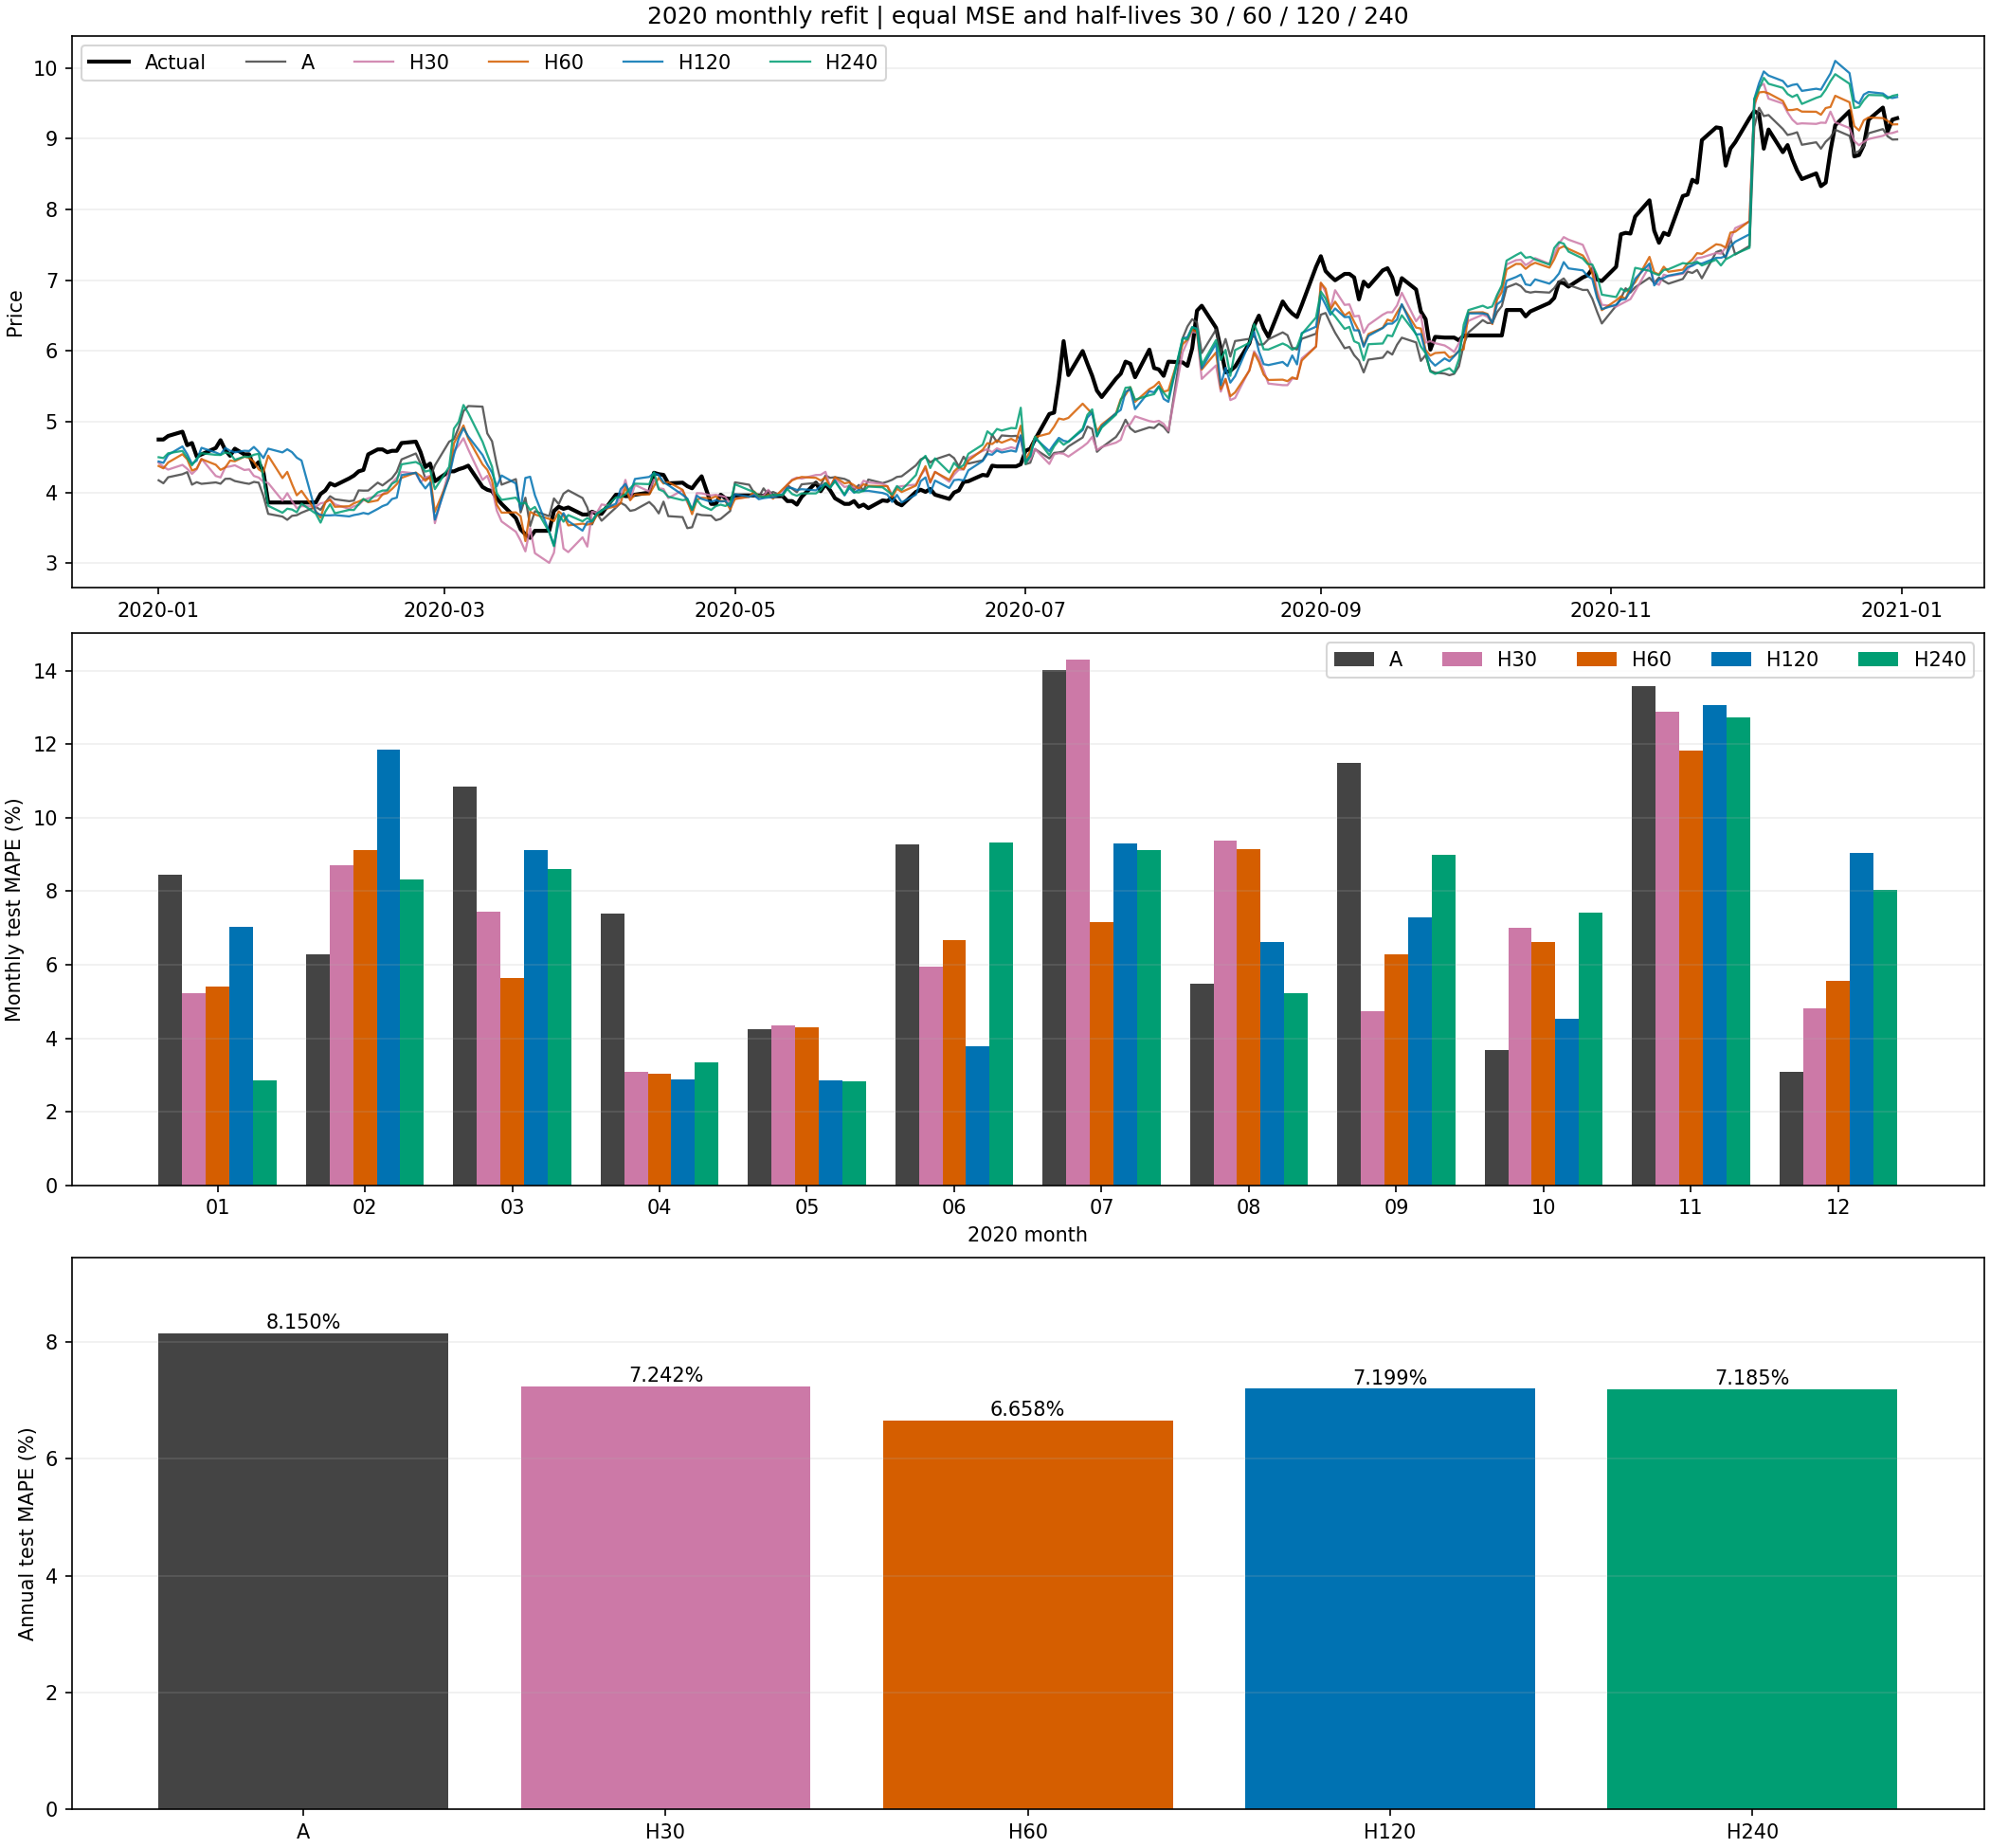

In [4]:
colors={'A':'#444444','H30':'#CC79A7','H60':'#D55E00','H120':'#0072B2','H240':'#009E73'}
fig,axes=plt.subplots(3,1,figsize=(14,13),constrained_layout=True)
axes[0].plot(comparison.Date,comparison.Actual,color='black',lw=2,label='Actual')
for method in METHODS:axes[0].plot(comparison.Date,comparison[method],color=colors[method],lw=1.1,label=method,alpha=.85)
axes[0].set(title='2020 monthly refit | equal MSE and half-lives 30 / 60 / 120 / 240',ylabel='Price');axes[0].legend(ncol=6)
p=np.arange(12)
for j,method in enumerate(METHODS):
    g=monthly[monthly.Method==method]
    axes[1].bar(p+(j-2)*.16,g.MAPE,width=.16,color=colors[method],label=method)
axes[1].set(xticks=p,xticklabels=g.Month.str[-2:],ylabel='Monthly test MAPE (%)',xlabel='2020 month');axes[1].legend(ncol=5)
axes[2].bar(summary.Method,summary.Annual_MAPE,color=[colors[m] for m in METHODS])
for i,v in enumerate(summary.Annual_MAPE):axes[2].text(i,v+.08,f'{v:.3f}%',ha='center')
axes[2].set(ylabel='Annual test MAPE (%)',ylim=(0,summary.Annual_MAPE.max()*1.16))
for ax in axes:ax.grid(axis='y',alpha=.2)
fig.savefig(OUT/'comparison.png',dpi=150);plt.close(fig);display(Image(filename=str(OUT/'comparison.png')))


## 半衰期比较结果与判断

| 方案 | 全年MAPE | 全年普通MSE | MAPE优于A月份数 | 最差月份MAPE |
|---|---:|---:|---:|---:|
| A 等权 | 8.1499% | 0.338087 | — | 14.0170% |
| 30 | 7.2423% | 0.301734 | 6/12 | 14.3140% |
| 60 | **6.6577%** | **0.250269** | 7/12 | **11.8386%** |
| 120 | 7.1993% | 0.315252 | 8/12 | 13.0631% |
| 240 | 7.1852% | 0.315758 | 8/12 | 12.7277% |

**60在本轮四个半衰期中表现最好**：全年MAPE、普通MSE、12个月等权MAPE及最差月份MAPE均最低。相对A，全年MAPE下降1.4923个百分点，普通MSE下降25.97%。

120、240虽然都有8个月优于A，但改善月份更多不等于全年总误差更低。30在7月MAPE为14.31%，比A还高；120和240在12月分别达到9.04%与8.03%，明显高于A的3.08%，这是延长半衰期未能持续改善的具体例子。

本轮暂保留60为后续加权训练参照，A仍作为统一等权基准。不自动增加更多半衰期搜索。结论限定于当前固定种子、100轮、同日输入的2020年开发实验，不能解释为60是普遍最优值。

新增三组共完成72个阶段模型、7200条逐轮记录；A和60复用上一节预测并校验指标。测试日期、数据指纹、种子选择记录与训练时间边界检查均通过。


目前看来是60的半衰期最好,但并不确定.我们先默认用60的半衰期.再用多次修正加加权MSE计算一下.

# 半衰期60：金铜MA20±3%双向穿越更新 vs 每月更新

沿用12的双向触发规则：金或铜任一的 `abs(P/MA20-1)` 在 `<3%` 与 `>=3%` 两种状态之间转换即触发；同日信号合并，无冷却期。持续超出不重复触发；从+4%直接到-4%仍属区间外，不额外推断盘中穿越。触发当天用旧模型，下条有效记录才使用新模型，训练标签最多到触发日。

两种更新方式均采用半衰期60条有效日度记录、两阶段加权MSE、等权标准化、16→32隐藏层、ReLU、Adam 0.01、全批量各100轮，从头重训。主对比为：M60 每月更新，E60 3%双向穿越更新。

**种子控制**：为延续本章月度60的口径，M60复用上一节结果；E60复用12中每次事件根据此前三个月验证MAPE选出的种子，仅将最终重训损失改为半衰期60，不重新运行候选选择。两种策略都沿用各自旧的等权候选选择记录，因此这是固定选种规则下的更新策略比较，不是同一种子贯穿全年的纯频率实验，也不是加权候选重新调参后的比较。

补充保留A月度等权、E等权双向触发的历史结果，便于区分损失变化和更新策略变化。年初初始化单列，事件次数和月度次数按相同口径报告。仍为2020年同日输入的历史开发实验。


In [1]:
from pathlib import Path
import os,json,hashlib,random
import numpy as np
import pandas as pd
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import display,Image
ROOT=next((p for p in [Path.cwd(),*Path.cwd().parents] if (p/'src/pickle/Dataset.pkl').exists()),Path('/Users/admin/数据分析/ZiJin-Mining/ZiJin-Mining-stock-prediction-'))
OUT=Path(os.environ.get('MLP13_CROSS60_OUT',str(ROOT/'results/mlp_crossing_h60_13')));OUT.mkdir(parents=True,exist_ok=True)
SEEDS=[965409, 640934, 550343, 798291, 374583, 42716, 785634, 565766, 385735, 741131]
EXCLUDED_SEEDS=[0, 1, 7, 21, 42, 100, 123, 999, 2024, 2025]
EPOCHS=100;LR=0.01;VALIDATION_MONTHS=3
torch.set_num_threads(1);torch.use_deterministic_algorithms(True)
assert len(set(SEEDS))==10 and not set(SEEDS)&set(EXCLUDED_SEEDS)
dataset=ROOT/'src/pickle/Dataset.pkl';d=pd.read_pickle(dataset)
raw=d['X'].copy();target=d['Y'].copy();assert raw.index.equals(target.index)
assert raw.index.is_unique and raw.index.is_monotonic_increasing
raw=raw.loc[raw.index<'2021-01-01'];BASE=list(raw.columns);assert len(BASE)==7
y=pd.Series(np.asarray(target).reshape(-1),index=target.index,name='Actual').loc[raw.index]
x=raw.copy();RETURNS=[]
for metal,col in [('gold','Gold Futures Price'),('copper','Copper Futures Price')]:
    name=f'{metal}_daily';x[name]=raw[col]/raw[col].shift(1)-1;RETURNS.append(name)
    for k in [5,20]:
        name=f'{metal}_vs_ma{k}';x[name]=raw[col]/raw[col].rolling(k,min_periods=k).mean()-1;RETURNS.append(name)
valid=np.isfinite(x.to_numpy()).all(axis=1)&np.isfinite(y.to_numpy())
x=x.loc[valid];y=y.loc[x.index];assert (y>0).all()
whole=x.index[x.index.year==2020];assert len(whole)==271
config=dict(seeds=SEEDS,excluded_prior_seeds=EXCLUDED_SEEDS,epochs_per_stage=EPOCHS,validation_months=VALIDATION_MONTHS,hidden=[16,32],activation='ReLU',optimizer='Adam',lr=LR,batch='full',base_features=BASE,stage2_features=['base_prediction']+RETURNS,stage2_training='in-sample predictions; base frozen',refit_after_selection=False,target='same-date original price',selection='minimum preceding-three-calendar-month MAPE; ties by candidate order',test_year=2020,dataset_sha256=hashlib.sha256(dataset.read_bytes()).hexdigest(),torch_version=str(torch.__version__))
(OUT/'config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))
x.join(y).to_csv(OUT/'features_and_target.csv',index_label='Date')
print('Frozen candidate seeds:',SEEDS)

THRESHOLD=.03
config.update(trigger='individual metal abs(MA20 deviation) crosses outward or inward at 3%; same-date events merged',threshold=THRESHOLD,effective='next available record',refit_after_selection=True,validation_window='three calendar months immediately before effective date',cooldown=None)
(OUT/'config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))
# 在完整历史计算状态，使2020年初状态继承自2019年；只执行2020年触发。
deviations=x[['gold_vs_ma20','copper_vs_ma20']]
outside=deviations.abs().ge(THRESHOLD)
previous=outside.shift(1)
valid_previous=previous.notna().all(axis=1)
entry=outside & previous.eq(False)
reentry=~outside & previous.eq(True)
crossing=(entry|reentry)&valid_previous.to_numpy()[:,None]
trigger_dates=reentry.index[(crossing.any(axis=1))&(reentry.index.year==2020)]
eventrows=[]
for day in trigger_dates:
    pos=x.index.get_loc(day);nextday=x.index[pos+1] if pos+1<len(x) else pd.NaT
    executable=pd.notna(nextday) and nextday.year==2020
    eventrows.append(dict(Trigger_date=day,Effective_date=nextday,Gold_trigger=bool(crossing.loc[day,'gold_vs_ma20']),Copper_trigger=bool(crossing.loc[day,'copper_vs_ma20']),Gold_direction=('outward' if entry.loc[day,'gold_vs_ma20'] else 'inward' if reentry.loc[day,'gold_vs_ma20'] else ''),Copper_direction=('outward' if entry.loc[day,'copper_vs_ma20'] else 'inward' if reentry.loc[day,'copper_vs_ma20'] else ''),Gold_deviation_percent=100*deviations.loc[day,'gold_vs_ma20'],Copper_deviation_percent=100*deviations.loc[day,'copper_vs_ma20'],Executable_in_2020=executable))
events=pd.DataFrame(eventrows)
events.to_csv(OUT/'trigger_events.csv',index=False)
schedule=[dict(Update_ID='initial',Kind='Initial',Trigger_date=pd.NaT,Effective_date=whole.min())]
for i,r in enumerate(events[events.Executable_in_2020].itertuples(index=False),1):
    schedule.append(dict(Update_ID=f'update_{i:02d}',Kind='Triggered',Trigger_date=r.Trigger_date,Effective_date=r.Effective_date))
schedule=pd.DataFrame(schedule).sort_values('Effective_date').reset_index(drop=True)
assert schedule.Effective_date.is_unique
print(f'触发日 {len(events)} 次；年内计划更新 {len(schedule)-1} 次；另有年初初始化1次。')
display(events)

HALF_LIFE=60;METHOD='E60'
PRIOR=OUT.parent/'mlp_crossing_update_12'
if not (PRIOR/'updates.csv').exists():PRIOR=ROOT/'results/mlp_crossing_update_12'
MONTHLY=OUT.parent/'mlp_weighted_mse_13'
if not (MONTHLY/'predictions.csv').exists():MONTHLY=ROOT/'results/mlp_weighted_mse_13'
old_updates=pd.read_csv(PRIOR/'updates.csv',parse_dates=['Effective_date'])
prior_cfg=json.loads((PRIOR/'config.json').read_text());month_cfg=json.loads((MONTHLY/'config.json').read_text())
assert prior_cfg['dataset_sha256']==month_cfg['dataset_sha256']==config['dataset_sha256']
assert old_updates.Update_ID.tolist()==schedule.Update_ID.tolist()
assert old_updates.Effective_date.tolist()==schedule.Effective_date.tolist()
config.update(half_life=60,age_unit='valid observations',weight_normalization='sum(weights)',weighted_stages=['Base','Stacking'],scaler='unweighted StandardScaler',selection='reuse historical equal-MSE validation-selected event seeds; no reranking',source_updates_sha256=hashlib.sha256((PRIOR/'updates.csv').read_bytes()).hexdigest())
(OUT/'config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))
old_updates.to_csv(OUT/'reused_selection.csv',index=False)


,Trigger_date,Effective_date,Gold_trigger,Copper_trigger,Gold_direction,Copper_direction,Gold_deviation_percent,Copper_deviation_percent,Executable_in_2020
0,2020-01-03,2020-01-06,True,False,outward,,3.781956,-0.699238,True
1,2020-01-09,2020-01-10,True,False,inward,,2.612086,-0.349417,True
2,2020-01-23,2020-01-24,False,True,,outward,1.018186,-3.216644,True
3,2020-02-11,2020-02-12,False,True,,inward,-0.023948,-2.475336,True
4,2020-02-21,2020-02-24,True,False,outward,,3.884455,1.281281,True
5,2020-02-26,2020-02-27,True,False,inward,,2.854205,-0.374539,True
6,2020-03-05,2020-03-06,True,False,outward,,3.376295,-0.644862,True
7,2020-03-10,2020-03-11,True,False,inward,,1.984865,-2.341254,True
8,2020-03-12,2020-03-13,False,True,,outward,-2.524139,-3.778798,True
9,2020-03-13,2020-03-16,True,False,outward,,-6.797278,-3.842026,True


Frozen candidate seeds: [965409, 640934, 550343, 798291, 374583, 42716, 785634, 565766, 385735, 741131]
触发日 58 次；年内计划更新 58 次；另有年初初始化1次。


In [2]:
history=[]
def fit_stage(X,train_idx,seed,stage,month):
    random.seed(seed);np.random.seed(seed);torch.manual_seed(seed)
    sx=StandardScaler().fit(X.loc[train_idx]);sy=StandardScaler().fit(y.loc[train_idx].to_numpy().reshape(-1,1))
    xt=torch.tensor(sx.transform(X.loc[train_idx]),dtype=torch.float32);yt=torch.tensor(sy.transform(y.loc[train_idx].to_numpy().reshape(-1,1)),dtype=torch.float32)
    model=nn.Sequential(nn.Linear(X.shape[1],16),nn.ReLU(),nn.Linear(16,32),nn.ReLU(),nn.Linear(32,1))
    ages=np.arange(len(train_idx)-1,-1,-1)
    weights=np.ones(len(train_idx)) if METHOD=='A' else 2.0**(-ages/HALF_LIFE)
    wt=torch.tensor(weights/weights.mean(),dtype=torch.float32).reshape(-1,1)
    opt=torch.optim.Adam(model.parameters(),lr=LR)
    for epoch in range(1,EPOCHS+1):
        model.train();opt.zero_grad();loss=(wt*(model(xt)-yt)**2).mean();assert torch.isfinite(loss)
        loss.backward();opt.step();model.eval()
        with torch.no_grad():z=model(xt).numpy()
        p=sy.inverse_transform(z).ravel();mse=float(np.mean((p-y.loc[train_idx].to_numpy())**2))
        history.append(dict(Method=METHOD,Month=month,Seed=seed,Stage=stage,Epoch=epoch,Weighted_MSE=float(np.average((p-y.loc[train_idx].to_numpy())**2,weights=weights)),Train_MSE=mse,Train_MSE_standardized=mse/float(sy.scale_[0]**2)))
    torch.save(dict(state_dict=model.state_dict(),features=list(X.columns),seed=seed,epochs=EPOCHS,train_start=str(train_idx.min()),train_end=str(train_idx.max()),sx_mean=sx.mean_.tolist(),sx_scale=sx.scale_.tolist(),sy_mean=sy.mean_.tolist(),sy_scale=sy.scale_.tolist()),OUT/f'{METHOD}_{month}_{stage}_seed{seed}.pt')
    return model,sx,sy

def predict(bundle,X):
    model,sx,sy=bundle;model.eval()
    with torch.no_grad():z=model(torch.tensor(sx.transform(X),dtype=torch.float32)).numpy()
    p=sy.inverse_transform(z).ravel();assert np.isfinite(p).all();return pd.Series(p,index=X.index)

def score(pred,idx):
    err=pred.loc[idx].to_numpy()-y.loc[idx].to_numpy()
    return dict(N=len(idx),MAPE=float(100*np.mean(np.abs(err)/np.abs(y.loc[idx].to_numpy()))),MSE=float(np.mean(err**2)))

def stack_predict(base,stack,X):
    bp=predict(base,X[BASE]);meta=X[RETURNS].copy();meta.insert(0,'base_prediction',bp)
    return predict(stack,meta)



In [3]:
frames=[];splitrows=[];updates=[];jumps=[];previous_bundle=None
for j,row in enumerate(schedule.itertuples(index=False)):
    tag=row.Update_ID;effective=pd.Timestamp(row.Effective_date)
    stop=pd.Timestamp(schedule.iloc[j+1].Effective_date) if j+1<len(schedule) else pd.Timestamp('2021-01-01')
    tr=x.index[x.index<effective];applied=x.index[(x.index>=effective)&(x.index<stop)]
    prior=old_updates.loc[old_updates.Update_ID==tag].iloc[0];seed=int(prior.Selected_seed)
    assert tr.max()<applied.min() and pd.Timestamp(prior.Refit_train_end)==tr.max()
    if row.Kind=='Triggered':assert tr.max()==row.Trigger_date and x.index[x.index.get_loc(row.Trigger_date)+1]==effective
    known=x.loc[tr];base=fit_stage(known[BASE],tr,seed,'Base',tag)
    meta=known[RETURNS].copy();meta.insert(0,'base_prediction',predict(base,known[BASE]))
    stack=fit_stage(meta,tr,seed,'Stacking',tag)
    pred=stack_predict(base,stack,x.loc[applied])
    if previous_bundle is not None:
        same=x.loc[[effective]]
        old_p=float(stack_predict(*previous_bundle,same).iloc[0]);new_p=float(pred.iloc[0])
        jumps.append(dict(Update_ID=tag,Date=effective,Old_model_prediction=old_p,New_model_prediction=new_p,Switch_change=new_p-old_p,Abs_switch_change_pct=100*abs(new_p-old_p)/abs(old_p)))
    previous_bundle=(base,stack)
    frames.append(pd.DataFrame(dict(Date=applied,Update_ID=tag,Seed=seed,Actual=y.loc[applied].to_numpy(),E60=pred.to_numpy())))
    updates.append(dict(Update_ID=tag,Trigger_date=row.Trigger_date,Effective_date=effective,Seed=seed,Train_end=tr.max(),Train_N=len(tr),Applied_N=len(applied)))
    for split,idx in [('Train',tr),('Test',applied)]:splitrows.append(dict(Update_ID=tag,Split=split,N=len(idx),Start=idx.min(),End=idx.max()))
    if j%10==0:print(tag,'completed',flush=True)
comparison=pd.concat(frames,ignore_index=True)
assert pd.DatetimeIndex(comparison.Date).equals(whole) and comparison.Date.is_unique
assert len(history)==len(schedule)*200
cached=pd.read_csv(MONTHLY/'predictions.csv',parse_dates=['Date']).rename(columns={'B':'M60'})
old_event=pd.read_csv(PRIOR/'stitched_predictions.csv',parse_dates=['Date'])
assert pd.DatetimeIndex(cached.Date).equals(whole) and pd.DatetimeIndex(old_event.Date).equals(whole)
assert np.allclose(comparison.Actual,cached.Actual) and np.allclose(comparison.Actual,old_event.Actual)
comparison['A']=cached.A.to_numpy();comparison['M60']=cached.M60.to_numpy();comparison['E_equal']=old_event.Predicted.to_numpy()
initial=comparison.Update_ID.eq('initial')
assert np.allclose(comparison.loc[initial,'E60'],comparison.loc[initial,'M60'],rtol=0,atol=1e-5)
comparison['Month']=comparison.Date.dt.strftime('%Y-%m')
METHODS=['A','E_equal','M60','E60'];rows=[]
for month,g in comparison.groupby('Month'):
    r=dict(Month=month,N=len(g))
    for m in METHODS:
        err=g[m]-g.Actual;r[m+'_MAPE']=100*(err.abs()/g.Actual.abs()).mean();r[m+'_MSE']=(err**2).mean()
    r['E60_minus_M60_MAPE_pp']=r['E60_MAPE']-r['M60_MAPE'];r['E60_minus_M60_MSE']=r['E60_MSE']-r['M60_MSE'];rows.append(r)
monthly=pd.DataFrame(rows)
summary=pd.DataFrame([dict(Method=m,Annual_MAPE=100*((comparison[m]-comparison.Actual).abs()/comparison.Actual.abs()).mean(),Annual_MSE=((comparison[m]-comparison.Actual)**2).mean(),Monthly_equal_MAPE=monthly[m+'_MAPE'].mean(),Worst_month_MAPE=monthly[m+'_MAPE'].max(),Updates_excluding_initial=11 if m in ['A','M60'] else len(schedule)-1,Initializations=1) for m in METHODS])
counts=dict(Triggered_updates=len(schedule)-1,Initializations=1,Deployed_models=len(schedule),New_stage_trainings=len(schedule)*2,Epoch_records=len(history),Months_E60_MAPE_better_than_M60=int((monthly.E60_minus_M60_MAPE_pp<0).sum()))
for name,frame in [('predictions',comparison),('monthly_comparison',monthly),('summary',summary),('updates',pd.DataFrame(updates)),('splits',pd.DataFrame(splitrows)),('training_history',pd.DataFrame(history)),('event_switch_diagnostics',pd.DataFrame(jumps))]:frame.to_csv(OUT/f'{name}.csv',index=False)
(OUT/'update_counts.json').write_text(json.dumps(counts,indent=2))
display(summary.round(5));display(monthly[['Month','M60_MAPE','E60_MAPE','E60_minus_M60_MAPE_pp']].round(4));print(counts)
print('Verified initial predictions reproduce M60; event schedule matches 12; all training ends before application; same 271 test records.')


,Method,Annual_MAPE,Annual_MSE,Monthly_equal_MAPE,Worst_month_MAPE,Updates_excluding_initial,Initializations
0,A,8.14992,0.33809,8.15282,14.01698,11,1
1,E_equal,6.38185,0.21132,6.41856,10.87380,58,1
2,M60,6.65766,0.25027,6.73328,11.83856,11,1
3,E60,5.38700,0.16852,5.41962,8.40981,58,1


,Month,M60_MAPE,E60_MAPE,E60_minus_M60_MAPE_pp
0,2020-01,5.4181,5.0602,-0.3579
1,2020-02,9.1275,5.9817,-3.1458
2,2020-03,5.6389,4.9011,-0.7378
3,2020-04,3.0237,4.7577,1.7340
4,2020-05,4.2880,3.7160,-0.5720
5,2020-06,6.6623,3.7368,-2.9255
6,2020-07,7.1739,4.7251,-2.4488
7,2020-08,9.1471,5.7352,-3.4120
8,2020-09,6.2872,4.1537,-2.1335
9,2020-10,6.6253,6.1528,-0.4725


initial completed
update_10 completed
update_20 completed
update_30 completed
update_40 completed
update_50 completed
{'Triggered_updates': 58, 'Initializations': 1, 'Deployed_models': 59, 'New_stage_trainings': 118, 'Epoch_records': 11800, 'Months_E60_MAPE_better_than_M60': 10}
Verified initial predictions reproduce M60; event schedule matches 12; all training ends before application; same 271 test records.


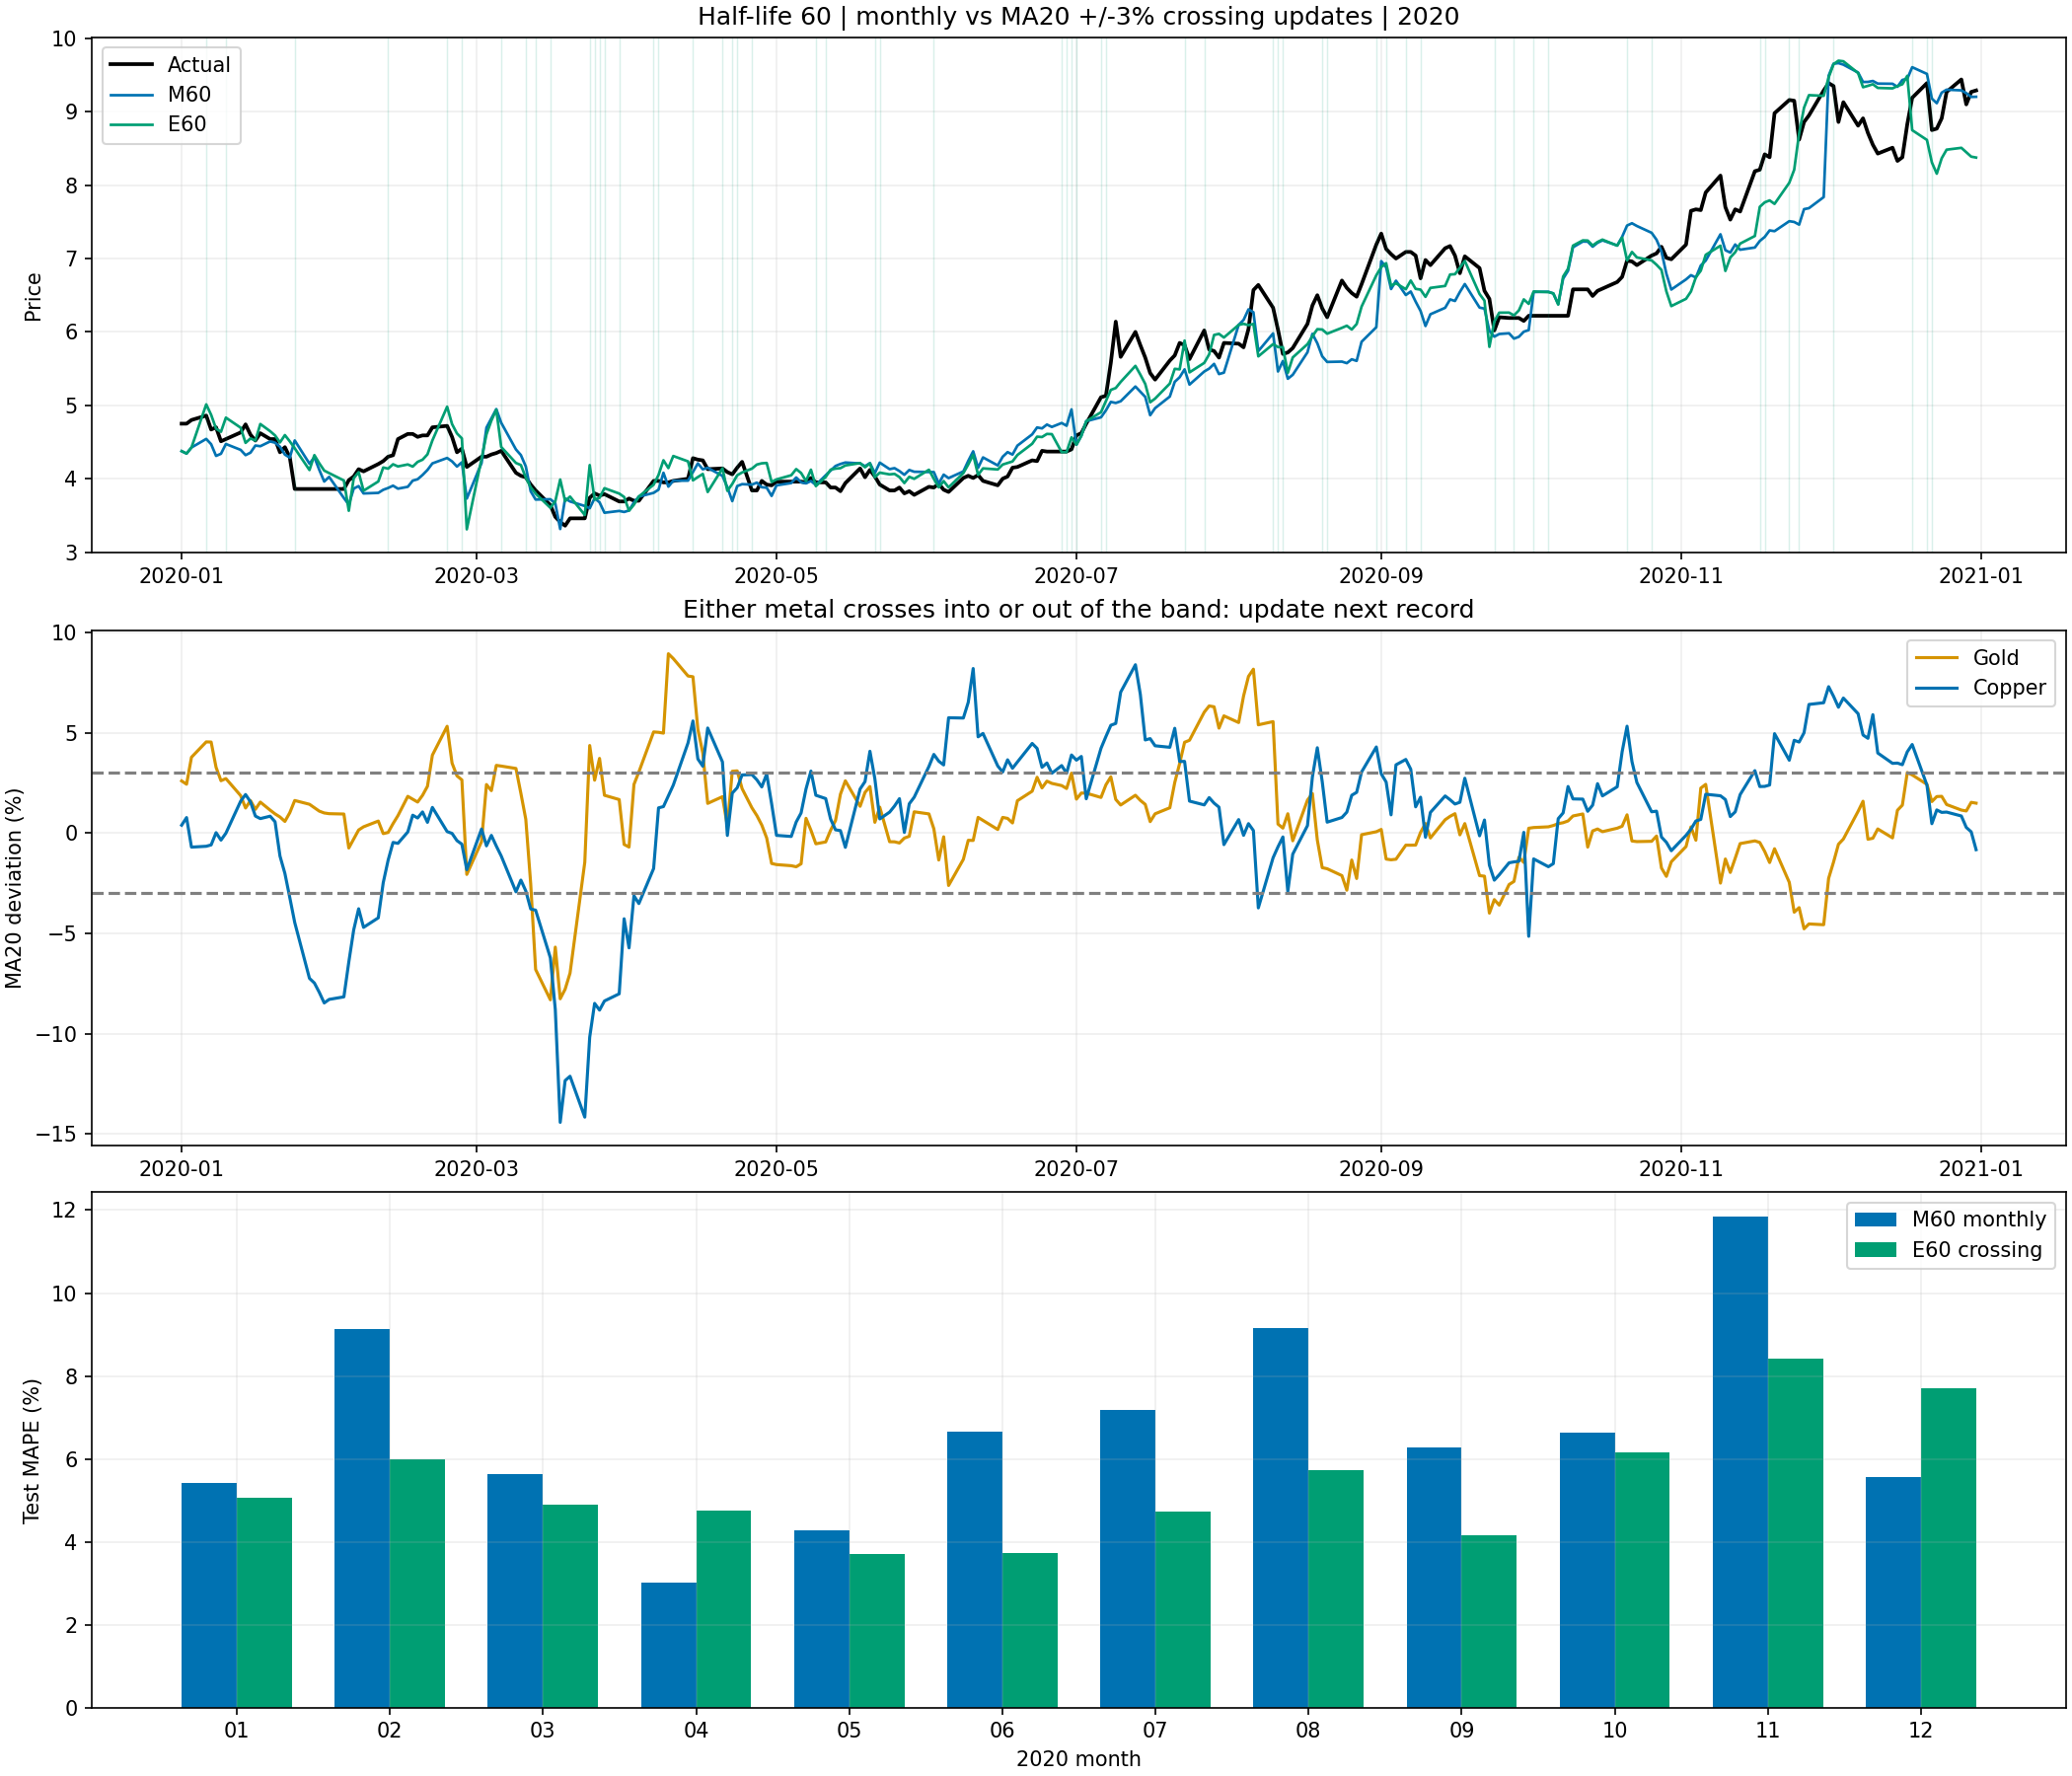

In [4]:
fig,axes=plt.subplots(3,1,figsize=(14,12),constrained_layout=True)
axes[0].plot(comparison.Date,comparison.Actual,color='black',lw=1.8,label='Actual')
for m,color in [('M60','#0072B2'),('E60','#009E73')]:axes[0].plot(comparison.Date,comparison[m],color=color,lw=1.3,label=m)
for dt in schedule.Effective_date.iloc[1:]:axes[0].axvline(dt,color='#009E73',alpha=.15,lw=.7)
axes[0].set(title='Half-life 60 | monthly vs MA20 +/-3% crossing updates | 2020',ylabel='Price');axes[0].legend()
for metal,col,color in [('Gold','gold_vs_ma20','#D59400'),('Copper','copper_vs_ma20','#0072B2')]:axes[1].plot(whole,x.loc[whole,col]*100,color=color,label=metal)
for v in [-3,3]:axes[1].axhline(v,color='gray',ls='--')
axes[1].set(ylabel='MA20 deviation (%)',title='Either metal crosses into or out of the band: update next record');axes[1].legend()
pos=np.arange(12)
axes[2].bar(pos-.18,monthly.M60_MAPE,width=.36,color='#0072B2',label='M60 monthly')
axes[2].bar(pos+.18,monthly.E60_MAPE,width=.36,color='#009E73',label='E60 crossing')
axes[2].set(xticks=pos,xticklabels=monthly.Month.str[-2:],ylabel='Test MAPE (%)',xlabel='2020 month');axes[2].legend()
for ax in axes:ax.grid(alpha=.2)
fig.savefig(OUT/'comparison.png',dpi=150);plt.close(fig);display(Image(filename=str(OUT/'comparison.png')))


## 本轮结果

| 方案 | 全年MAPE | 普通MSE | 最差月份MAPE | 年内重训次数（不含初始化） |
|---|---:|---:|---:|---:|
| A 月度等权 | 8.1499% | 0.338087 | 14.0170% | 11 |
| 等权3%双向触发 | 6.3819% | 0.211321 | 10.8738% | 58 |
| M60 月度更新 | 6.6577% | 0.250269 | 11.8386% | 11 |
| E60 3%双向触发 | **5.3870%** | **0.168516** | **8.4098%** | 58 |

E60相对M60，全年MAPE降低1.2707个百分点，普通MSE降低32.67%。10/12个月的MAPE和MSE改善；4月MAPE由3.02%升至4.76%，12月由5.57%升至7.71%。相对原等权触发策略，E60的全年MAPE也降低0.9949个百分点。

**当前实验中，半衰期60结合3%双向触发的总体误差更低。** 但它部署59个模型（月度12个，均含初始化），并不能单凭本次比较证明3%阈值本身优于同等更新次数的固定周期；种子也随各自历史验证窗口变化。更频繁重训亦不保证预测曲线消除跳变，不能把误差下降等同于平滑性改善。

触发重训每次均使用截至触发日的信息，下一条记录才生效。年初首段预测与M60一致，触发日程与12完全一致；118个阶段模型、11800条逐轮记录、271条对齐测试记录检查通过。模型、逐月指标、更新日期和同输入下新旧模型切换差值均保存于本节结果目录。


### 从20年来看,我们认为多次更新,加上权重MSE更好的适应趋势,跟上变化.下面我们再用15到26年进行测试,看看是否验证这个结论.

# 2015—2026：四种训练/更新方式的跨年比较

四组均采用两阶段Stacking、每阶段16→32两隐藏层、ReLU、Adam学习率0.01、全批量各100轮，同日特征预测同日股价：

1. **每月更新·等权**：每月验证选种子后，将月前全部有效历史纳入等权重训。
2. **每月更新·半衰期60**：与第一组同训练日期、同种子，只把最终两阶段重训损失改为半衰期60条有效记录的加权MSE。
3. **双向触发·半衰期60**：金或铜相对MA20的绝对偏离在 `<3%` 与 `>=3%` 间切换，下一条有效记录更新；同日信号合并，不设冷却期。仅年初初始化，不额外叠加月度更新。
4. **每年一次·旧结果**：直接读取11的 `mlp_annual_ten_ma_11` 中Stacking的100轮、10种子测试结果，每年仅在年初训练并全年冻结。本轮完全不重训这一组，也不把十个预测平均成集成模型；柱高是十个种子各自误差的均值。

三种更新策略沿用本章固定的10个候选种子。非2020年份在每次更新前，用此前三个日历月验证MAPE选择等权候选，精确并列按候选顺序，再纳入验证数据从头重训；半衰期仅用于最终重训，候选选择仍等权，避免同时改动选择协议。2020复用已保存的选择记录，并验证三组预测复现前文结果。三组每年重新初始化，年初共享1月1日选择起点，确保第一段加权模型一致。

**比较边界**：旧全年模式是另一组10个固定种子的误差均值，更新模式是验证选种后的单一模型序列；旧全年模式还使用等权损失。所以它是历史整体方案参照，不是只改变更新频率的完全配对试验。只比较共同测试日期，验证旧120个种子-年份指标与原结果一致。触发模型不使用生效日或之后的标签。

**平均口径**：主指标是各年MAPE的等权平均；同时列按记录数加权的整体MAPE、MSE。2015—2025为11个完整年份；2015—2026汇总另含2026年1月1日至7月23日的152条记录，不把它称为完整2026年表现。跨年绝对MSE受股价水平影响，作为补充。半衰期60此前在2020筛选过，本轮不是全新盲测。

以下保留完整可运行实现；已完成年份按本节专用目录缓存，重新运行会复用，旧全年结果始终只读。


In [1]:
from pathlib import Path
import os,json,hashlib,random,argparse,time
os.environ.setdefault('OMP_NUM_THREADS','1')
os.environ.setdefault('MKL_NUM_THREADS','1')
os.environ.setdefault('OPENBLAS_NUM_THREADS','1')
import numpy as np
import pandas as pd
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler
from concurrent.futures import ProcessPoolExecutor,as_completed
import multiprocessing as mp
ROOT=Path('/Users/admin/数据分析/ZiJin-Mining/ZiJin-Mining-stock-prediction-')
OUT=Path(os.environ.get('MLP13_FOUR_OUT',str(ROOT/'results/mlp_four_modes_2015_2026_13')));OUT.mkdir(parents=True,exist_ok=True)
SEEDS=[965409,640934,550343,798291,374583,42716,785634,565766,385735,741131]
BASE=['A_500','Dollar Index','cn_10y_rate','us_10y_rate','brent','Copper Futures Price','Gold Futures Price']
RETURNS=['gold_daily','gold_vs_ma5','gold_vs_ma20','copper_daily','copper_vs_ma5','copper_vs_ma20']
EPOCHS=100

def locate(name):
    p=OUT.parent/name
    return p if p.exists() else ROOT/'results'/name

def initialize():
    global x,y
    torch.set_num_threads(1);torch.use_deterministic_algorithms(True)
    data=pd.read_csv(OUT/'features_and_target.csv',parse_dates=['Date']).set_index('Date')
    x=data[BASE+RETURNS];y=data.Actual

def fit(X,idx,seed,half):
    random.seed(seed);np.random.seed(seed);torch.manual_seed(seed)
    sx=StandardScaler().fit(X.loc[idx]);sy=StandardScaler().fit(y.loc[idx].to_numpy().reshape(-1,1))
    xt=torch.tensor(sx.transform(X.loc[idx]),dtype=torch.float32)
    yt=torch.tensor(sy.transform(y.loc[idx].to_numpy().reshape(-1,1)),dtype=torch.float32)
    model=nn.Sequential(nn.Linear(X.shape[1],16),nn.ReLU(),nn.Linear(16,32),nn.ReLU(),nn.Linear(32,1))
    if half:
        w=2.0**(-np.arange(len(idx)-1,-1,-1)/half)
        assert np.isclose(w[-half-1]/w[-1],.5)
        wt=torch.tensor(w/w.mean(),dtype=torch.float32).reshape(-1,1)
    opt=torch.optim.Adam(model.parameters(),lr=.01)
    for epoch in range(EPOCHS):
        model.train();opt.zero_grad();err=(model(xt)-yt)**2
        loss=(wt*err).mean() if half else err.mean()
        assert torch.isfinite(loss)
        loss.backward();opt.step()
    model.eval()
    return model,sx,sy

def predict(bundle,X):
    model,sx,sy=bundle
    with torch.no_grad():z=model(torch.tensor(sx.transform(X),dtype=torch.float32)).numpy()
    p=sy.inverse_transform(z).ravel();assert np.isfinite(p).all()
    return pd.Series(p,index=X.index)

def train_stack(idx,seed,half):
    known=x.loc[idx]
    base=fit(known[BASE],idx,seed,half)
    meta=known[RETURNS].copy();meta.insert(0,'base_prediction',predict(base,known[BASE]))
    stack=fit(meta,idx,seed,half)
    return base,stack

def stack_predict(bundle,X):
    base,stack=bundle
    meta=X[RETURNS].copy();meta.insert(0,'base_prediction',predict(base,X[BASE]))
    return predict(stack,meta)

def save_bundle(bundle,path,seed,half,idx):
    packs=[]
    for model,sx,sy in bundle:
        packs.append(dict(state_dict=model.state_dict(),sx_mean=sx.mean_.tolist(),sx_scale=sx.scale_.tolist(),sy_mean=sy.mean_.tolist(),sy_scale=sy.scale_.tolist()))
    torch.save(dict(stages=packs,seed=seed,half_life=half,train_start=str(idx.min()),train_end=str(idx.max()),epochs=100),path)

def select_seed(anchor,folder):
    key=anchor.strftime('%Y-%m-%d');path=folder/f'selection_{key}.json'
    tr=x.index[x.index<anchor-pd.DateOffset(months=3)]
    va=x.index[(x.index>=anchor-pd.DateOffset(months=3))&(x.index<anchor)]
    assert tr.max()<va.min() and va.max()<anchor
    if path.exists():return json.loads(path.read_text())
    candidates=[]
    for i,seed in enumerate(SEEDS):
        bundle=train_stack(tr,seed,None)
        pred=stack_predict(bundle,x.loc[va]);err=pred.to_numpy()-y.loc[va].to_numpy()
        candidates.append(dict(Seed=seed,Candidate_order=i,MAPE=float(100*np.mean(np.abs(err)/np.abs(y.loc[va].to_numpy()))),MSE=float(np.mean(err**2))))
    winner=min(candidates,key=lambda r:(r['MAPE'],r['Candidate_order']))
    decision=dict(Anchor=key,Selected_seed=winner['Seed'],Validation_MAPE=winner['MAPE'],Train_end=str(tr.max().date()),Validation_start=str(va.min().date()),Validation_end=str(va.max().date()),Candidates=candidates,Source='new equal-MSE validation selection')
    path.write_text(json.dumps(decision,indent=2));return decision

def year_run(year):
    initialize();folder=OUT/str(year);folder.mkdir(exist_ok=True)
    te=x.index[x.index.year==year]
    if (folder/'done.json').exists():return json.loads((folder/'done.json').read_text())
    start=pd.Timestamp(f'{year}-01-01');end=pd.Timestamp(f'{year+1}-01-01')
    outside=x[['gold_vs_ma20','copper_vs_ma20']].abs().ge(.03)
    prev=outside.shift(1);cross=outside.ne(prev)&prev.notna()
    events=[]
    for day in te:
        if cross.loc[day].any():
            pos=x.index.get_loc(day);effective=x.index[pos+1] if pos+1<len(x) else pd.NaT
            if pd.notna(effective) and effective.year==year:
                events.append(dict(Trigger_date=day,Effective_date=effective,Gold_trigger=bool(cross.loc[day,'gold_vs_ma20']),Copper_trigger=bool(cross.loc[day,'copper_vs_ma20'])))
    monthly=[]
    for month in sorted(te.to_period('M').unique()):
        dates=te[te.to_period('M')==month]
        monthly.append(dict(Anchor=month.start_time,Effective_date=dates.min(),Trigger_date=pd.NaT))
    event=[dict(Anchor=start,Effective_date=te.min(),Trigger_date=pd.NaT)]+[dict(Anchor=r['Effective_date'],Effective_date=r['Effective_date'],Trigger_date=r['Trigger_date']) for r in events]
    schedules={'Monthly_equal':monthly,'Monthly_H60':monthly,'Crossing_H60':event}
    predictions=pd.DataFrame({'Date':te,'Actual':y.loc[te].to_numpy()})
    updates=[];selection_cache={};model_cache={};trained=0;started=time.time()
    # Reuse original 2020 decisions to preserve this chapter's exact controls.
    if year==2020:
        old_month=pd.read_csv(locate('mlp_monthly_validation_12')/'selection.csv')
        old_event=pd.read_csv(locate('mlp_crossing_update_12')/'updates.csv')
        for r in old_month.itertuples(index=False):
            selection_cache[pd.Timestamp(r.Month+'-01')]=dict(Selected_seed=int(r.Selected_seed),Validation_MAPE=r.Validation_MAPE,Source='reused 12 monthly selection')
        for r in old_event.itertuples(index=False):
            key=start if r.Kind=='Initial' else pd.Timestamp(r.Effective_date)
            decision=dict(Selected_seed=int(r.Selected_seed),Validation_MAPE=r.Validation_MAPE,Source='reused 12 crossing selection')
            if key in selection_cache:assert decision['Selected_seed']==selection_cache[key]['Selected_seed']
            selection_cache[key]=decision
        assert [pd.Timestamp(r['Effective_date']) for r in event]==pd.to_datetime(old_event.Effective_date).tolist()
    anchors=sorted(set(r['Anchor'] for rows in schedules.values() for r in rows))
    for i,anchor in enumerate(anchors):
        if anchor not in selection_cache:selection_cache[anchor]=select_seed(anchor,folder)
        if (i+1)%10==0:print(f'{year} selection {i+1}/{len(anchors)} ({time.time()-started:.0f}s)',flush=True)
    for method,rows in schedules.items():
        half=None if method=='Monthly_equal' else 60
        method_frames=[]
        for j,r in enumerate(rows):
            effective=r['Effective_date'];anchor=r['Anchor'];stop=rows[j+1]['Effective_date'] if j+1<len(rows) else end
            idx=x.index[x.index<effective];applied=te[(te>=effective)&(te<stop)]
            decision=selection_cache[anchor];seed=decision['Selected_seed']
            assert idx.max()<applied.min() and len(applied)>0
            if pd.notna(r['Trigger_date']):assert idx.max()==r['Trigger_date']
            key=(str(idx.max()),seed,half)
            if key not in model_cache:
                bundle=train_stack(idx,seed,half);model_cache[key]=bundle;trained+=2
                save_bundle(bundle,folder/f'{method}_{effective.strftime("%Y%m%d")}.pt',seed,half,idx)
            bundle=model_cache[key]
            pred=stack_predict(bundle,x.loc[applied])
            method_frames.append(pd.DataFrame({'Date':applied,method:pred.to_numpy()}))
            updates.append(dict(Year=year,Method=method,Anchor=anchor,Effective_date=effective,Trigger_date=r['Trigger_date'],Seed=seed,Train_start=idx.min(),Train_end=idx.max(),Train_N=len(idx),Applied_start=applied.min(),Applied_end=applied.max(),Applied_N=len(applied),Validation_MAPE=decision['Validation_MAPE'],Selection_source=decision['Source']))
        frame=pd.concat(method_frames,ignore_index=True)
        assert pd.DatetimeIndex(frame.Date).equals(te)
        predictions=predictions.merge(frame,on='Date',validate='one_to_one')
    initial_stop=min(monthly[1]['Effective_date'] if len(monthly)>1 else end,event[1]['Effective_date'] if len(event)>1 else end)
    first=predictions.Date<initial_stop
    assert np.allclose(predictions.loc[first,'Monthly_H60'],predictions.loc[first,'Crossing_H60'],rtol=0,atol=1e-5)
    if year==2020:
        old=pd.read_csv(locate('mlp_crossing_h60_13')/'predictions.csv',parse_dates=['Date'])
        assert pd.DatetimeIndex(old.Date).equals(te)
        for new,prior in [('Monthly_equal','A'),('Monthly_H60','M60'),('Crossing_H60','E60')]:
            assert np.allclose(predictions[new],old[prior],atol=1e-5,rtol=0),(new,'2020 mismatch')
    predictions['Year']=year
    predictions.to_csv(folder/'predictions.csv',index=False)
    pd.DataFrame(updates).to_csv(folder/'updates.csv',index=False)
    pd.DataFrame(events).to_csv(folder/'events.csv',index=False)
    result=dict(Year=year,N=len(te),Start=str(te.min().date()),End=str(te.max().date()),Monthly_models=len(monthly),Crossing_models=len(event),Unique_selection_dates=len(anchors),New_final_stage_trainings=trained,Seconds=time.time()-started)
    (folder/'done.json').write_text(json.dumps(result,indent=2))
    print(f'{year} DONE: {len(monthly)} monthly / {len(event)} crossing models; {time.time()-started:.0f}s',flush=True)
    return result

def prepare():
    dataset=ROOT/'src/pickle/Dataset.pkl';d=pd.read_pickle(dataset)
    raw=d['X'].copy();target=d['Y'].copy();assert raw.index.equals(target.index)
    assert raw.index.is_monotonic_increasing and raw.index.is_unique
    raw=raw.loc[raw.index.year<=2026];data=raw.copy()
    for metal,col in [('gold','Gold Futures Price'),('copper','Copper Futures Price')]:
        data[metal+'_daily']=raw[col]/raw[col].shift(1)-1
        for k in [5,20]:data[f'{metal}_vs_ma{k}']=raw[col]/raw[col].rolling(k,min_periods=k).mean()-1
    actual=pd.Series(np.asarray(target).reshape(-1),index=target.index).loc[raw.index]
    mask=np.isfinite(data.to_numpy()).all(axis=1)&np.isfinite(actual)
    data=data.loc[mask];data['Actual']=actual.loc[data.index]
    data.to_csv(OUT/'features_and_target.csv',index_label='Date')
    old=locate('mlp_annual_ten_ma_11');cfg=json.loads((old/'config.json').read_text())
    digest=hashlib.sha256(dataset.read_bytes()).hexdigest();assert cfg['dataset_sha256']==digest
    config=dict(years=list(range(2015,2027)),dataset_sha256=digest,epochs_per_stage=100,hidden=[16,32],activation='ReLU',optimizer='Adam',lr=.01,seeds=SEEDS,half_life=60,age_unit='valid records',selection='equal-MSE candidates; preceding three calendar months validation MAPE; fixed seeds and tie order; refit all pre-effective data',annual_initialization='reset each year; shared Jan 1 selection anchor for monthly and crossing',trigger='either metal absolute MA20 deviation crosses 3%, next-record effective, merged same-day signals',old_annual_source=str(old),old_annual_model='Stacking',old_annual_aggregation='mean of ten seed metrics, NOT metrics of ensemble prediction',old_annual_loss='equal MSE',old_annual_seeds=cfg['seeds'],old_annual_metrics_sha256=hashlib.sha256((old/'metrics.csv').read_bytes()).hexdigest(),partial_2026_end=str(data.index.max().date()),torch_version=str(torch.__version__))
    if (OUT/'config.json').exists():
        previous_config=json.loads((OUT/'config.json').read_text())
        assert {k:v for k,v in previous_config.items() if k!='old_annual_source'}=={k:v for k,v in config.items() if k!='old_annual_source'}, 'Configuration changed: use a new results directory before rerunning.'
    (OUT/'config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))



In [2]:
prepare()
coverage_results=[year_run(year) for year in range(2015,2027)]
print('12 years ready; annual frozen baseline was not trained.')

12 years ready; annual frozen baseline was not trained.


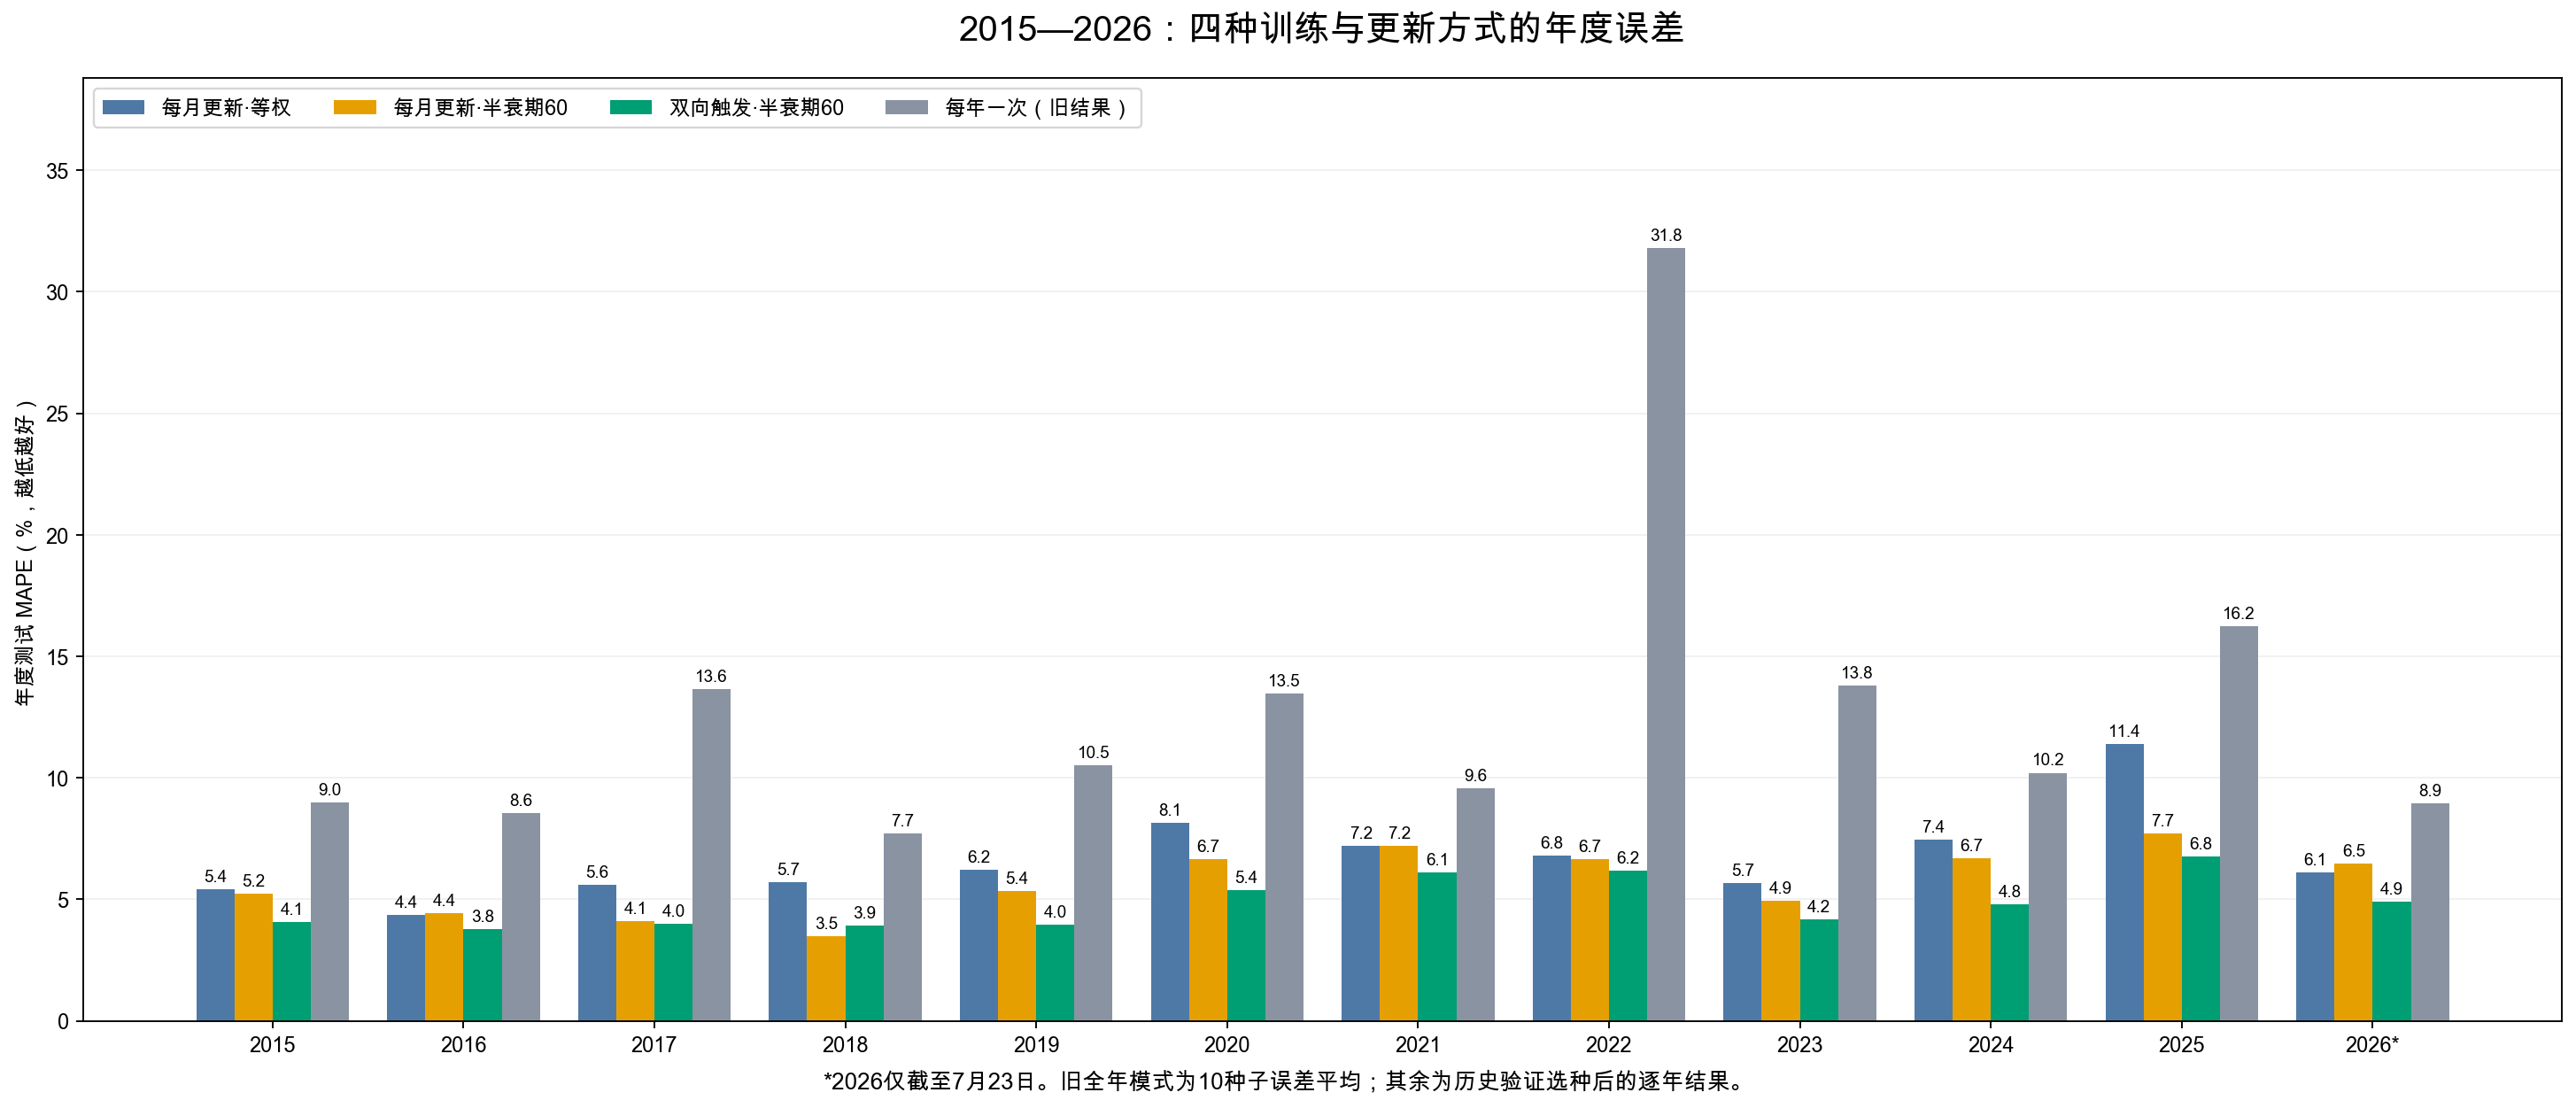

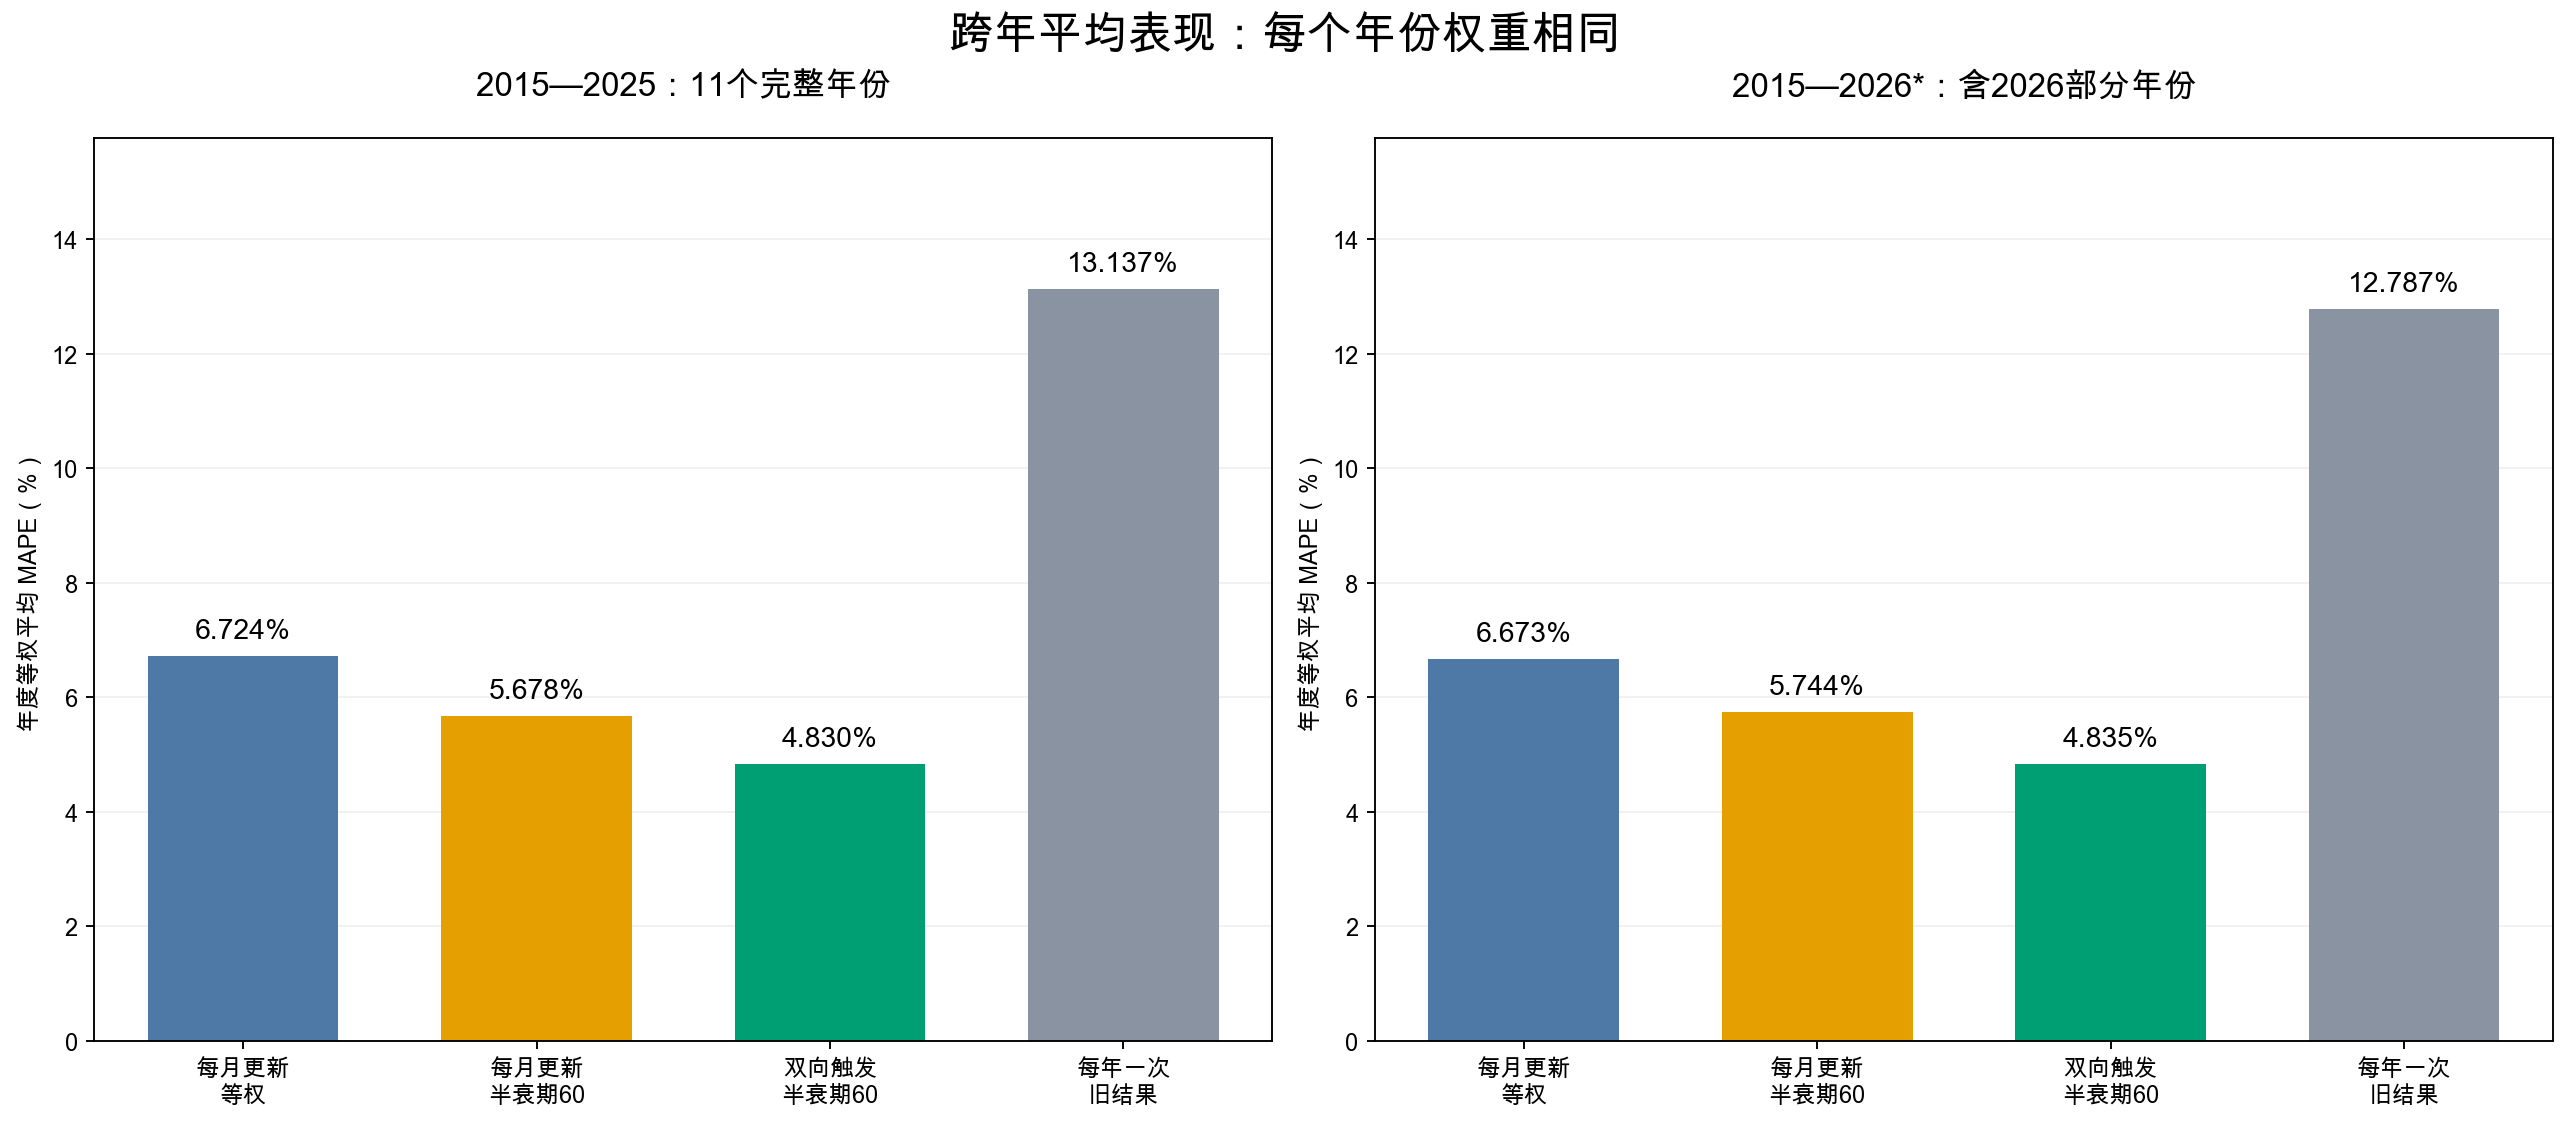

,Period,Method,Years,N,Annual_equal_MAPE,Record_weighted_MAPE,Annual_equal_MSE,Record_weighted_MSE,Worst_year,Worst_year_MAPE,Total_models,Total_updates_excluding_year_initializations
0,2015-2025_complete,Annual_frozen_old,11,2972,13.13668,13.16424,3.71743,3.72675,2022,31.79898,11,0
1,2015-2025_complete,Monthly_equal,11,2972,6.72446,6.72659,1.50422,1.49966,2025,11.39432,132,121
2,2015-2025_complete,Monthly_H60,11,2972,5.67829,5.68352,0.84760,0.84754,2025,7.70101,132,121
3,2015-2025_complete,Crossing_H60,11,2972,4.82982,4.83324,0.59331,0.59290,2025,6.76360,636,625
4,2015-2026_partial,Annual_frozen_old,12,3124,12.78723,12.95886,4.42959,4.14211,2022,31.79898,12,0
5,2015-2026_partial,Monthly_equal,12,3124,6.67286,6.69636,1.84596,1.69941,2025,11.39432,139,127
6,2015-2026_partial,Monthly_H60,12,3124,5.74351,5.72135,1.34224,1.13635,2025,7.70101,139,127
7,2015-2026_partial,Crossing_H60,12,3124,4.83523,4.83623,0.90498,0.77490,2025,6.76360,689,677


Method  Annual_frozen_old  Monthly_equal  Monthly_H60  Crossing_H60
Year                                                               
2015               8.9895         5.4145       5.2245        4.0811
2016               8.5512         4.3664       4.4437        3.7776
2017              13.6441         5.5809       4.1206        3.9990
2018               7.7041         5.7021       3.4709        3.9202
2019              10.5241         6.2090       5.3565        3.9595
2020              13.4757         8.1499       6.6577        5.3870
2021               9.5718         7.2085       7.2088        6.1078
2022              31.7990         6.8175       6.6610        6.1768
2023              13.7930         5.6798       4.9397        4.1677
2024              10.2090         7.4460       6.6768        4.7878
2025              16.2421        11.3943       7.7010        6.7636
2026               8.9432         6.1053       6.4609        4.8946
            Period            Method  Years    N

In [3]:
from pathlib import Path
import os,json
os.environ['MPLCONFIGDIR']='/private/tmp/mlp13-annual-mpl'
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
cfg=json.loads((OUT/'config.json').read_text())
OLD=Path(cfg['old_annual_source'])
METHODS=['Annual_frozen_old','Monthly_equal','Monthly_H60','Crossing_H60']
LABELS={'Annual_frozen_old':'每年一次（旧结果）','Monthly_equal':'每月更新·等权','Monthly_H60':'每月更新·半衰期60','Crossing_H60':'双向触发·半衰期60'}
COLORS={'Annual_frozen_old':'#8a93a2','Monthly_equal':'#4e79a7','Monthly_H60':'#e69f00','Crossing_H60':'#009e73'}
font=FontProperties(fname='/System/Library/Fonts/Supplemental/Arial Unicode.ttf')
plt.rcParams['font.family']=font.get_name();plt.rcParams['axes.unicode_minus']=False
allpred=[];annual=[];allupdates=[];coverage=[]
oldpred=pd.read_csv(OLD/'predictions.csv',parse_dates=['Date'])
oldpred=oldpred[(oldpred.Model=='Stacking')&(oldpred.Split=='Test')&(oldpred.Budget==100)]
oldmetrics=pd.read_csv(OLD/'metrics.csv')
oldmetrics=oldmetrics[(oldmetrics.Model=='Stacking')&(oldmetrics.Split=='Test')&(oldmetrics.Budget==100)]
assert len(oldmetrics)==120
for year in range(2015,2027):
    folder=OUT/str(year);assert (folder/'done.json').exists()
    p=pd.read_csv(folder/'predictions.csv',parse_dates=['Date']);allpred.append(p)
    u=pd.read_csv(folder/'updates.csv',parse_dates=['Effective_date','Train_end','Applied_start']);allupdates.append(u)
    assert (u.Train_end<u.Applied_start).all()
    done=json.loads((folder/'done.json').read_text());coverage.append(done)
    assert p.Date.is_unique and p.Date.is_monotonic_increasing
    for method in METHODS[1:]:
        err=p[method]-p.Actual;records=u[u.Method==method]
        annual.append(dict(Year=year,Method=method,N=len(p),MAPE=100*(err.abs()/p.Actual.abs()).mean(),MSE=(err**2).mean(),Seed_MAPE_SD=np.nan,Models=len(records),Updates_excluding_initial=len(records)-1,Start=str(p.Date.min().date()),End=str(p.Date.max().date())))
    op=oldpred[oldpred.Year==year]
    assert op.Seed.nunique()==10 and not op.duplicated(['Seed','Date']).any()
    for seed,g in op.groupby('Seed'):
        g=g.sort_values('Date');assert g.Date.tolist()==p.Date.tolist()
        assert np.allclose(g.Actual,p.Actual,rtol=0,atol=1e-9)
        err=g.Predicted-g.Actual;mape=100*(err.abs()/g.Actual.abs()).mean();mse=(err**2).mean()
        metric=oldmetrics[(oldmetrics.Year==year)&(oldmetrics.Seed==seed)].iloc[0]
        assert np.isclose(metric.MAPE,mape,rtol=1e-6) and np.isclose(metric.MSE,mse,rtol=1e-6)
    om=oldmetrics[oldmetrics.Year==year]
    assert (om.N==len(p)).all()
    annual.append(dict(Year=year,Method=METHODS[0],N=len(p),MAPE=om.MAPE.mean(),MSE=om.MSE.mean(),Seed_MAPE_SD=om.MAPE.std(),Models=1,Updates_excluding_initial=0,Start=str(p.Date.min().date()),End=str(p.Date.max().date())))
a=pd.DataFrame(annual);p=pd.concat(allpred,ignore_index=True);u=pd.concat(allupdates,ignore_index=True)
a.to_csv(OUT/'annual_metrics.csv',index=False);p.to_csv(OUT/'predictions.csv',index=False);u.to_csv(OUT/'updates.csv',index=False);pd.DataFrame(coverage).to_csv(OUT/'coverage.csv',index=False)
pivot=a.pivot(index='Year',columns='Method',values='MAPE')[METHODS];pivot.to_csv(OUT/'annual_mape.csv')
rows=[]
for period,maxyear in [('2015-2025_complete',2025),('2015-2026_partial',2026)]:
    selected=a[a.Year<=maxyear]
    for method in METHODS:
        g=selected[selected.Method==method]
        rows.append(dict(Period=period,Method=method,Years=len(g),N=int(g.N.sum()),Annual_equal_MAPE=g.MAPE.mean(),Record_weighted_MAPE=np.average(g.MAPE,weights=g.N),Annual_equal_MSE=g.MSE.mean(),Record_weighted_MSE=np.average(g.MSE,weights=g.N),Worst_year=int(g.loc[g.MAPE.idxmax(),'Year']),Worst_year_MAPE=g.MAPE.max(),Total_models=int(g.Models.sum()),Total_updates_excluding_year_initializations=int(g.Updates_excluding_initial.sum())))
summary=pd.DataFrame(rows);summary.to_csv(OUT/'summary.csv',index=False)
oldsummary=pd.read_csv(OLD/'summary.csv')
for period,oldperiod in [('2015-2025_complete','2015-2025'),('2015-2026_partial','2015-2026_partial')]:
    current=summary[(summary.Period==period)&(summary.Method==METHODS[0])].iloc[0]
    old=oldsummary[(oldsummary.Period==oldperiod)&(oldsummary.Model=='Stacking')].iloc[0]
    assert np.isclose(current.Annual_equal_MAPE,old.Annual_equal_mean_MAPE)
    assert np.isclose(current.Record_weighted_MAPE,old.Sample_weighted_MAPE)
paired=[]
for baseline,alternative in [('Monthly_equal','Monthly_H60'),('Monthly_H60','Crossing_H60'),('Annual_frozen_old','Monthly_equal'),('Annual_frozen_old','Crossing_H60')]:
    for period,limit in [('2015-2025_complete',2025),('2015-2026_partial',2026)]:
        s=summary[summary.Period==period].set_index('Method');base=s.loc[baseline];alt=s.loc[alternative]
        pp=base.Annual_equal_MAPE-alt.Annual_equal_MAPE;years=pivot.loc[pivot.index<=limit]
        paired.append(dict(Period=period,Baseline=baseline,Alternative=alternative,MAPE_reduction_pp=pp,MAPE_relative_reduction_pct=100*pp/base.Annual_equal_MAPE,Years_improved=int((years[alternative]<years[baseline]).sum()),Years=len(years)))
pd.DataFrame(paired).to_csv(OUT/'paired_comparisons.csv',index=False)
PLOT_ORDER=['Monthly_equal','Monthly_H60','Crossing_H60','Annual_frozen_old']
# Annual grouped bars: fixed method order, same-date coverage, 2026 explicitly partial.
fig,ax=plt.subplots(figsize=(17,7),layout='constrained');pos=np.arange(12);width=.20
for i,m in enumerate(PLOT_ORDER):
    bars=ax.bar(pos+(i-1.5)*width,pivot[m],width=width,color=COLORS[m],label=LABELS[m])
    ax.bar_label(bars,fmt='%.1f',fontsize=8,padding=2)
ax.set_xticks(pos,[str(y) if y!=2026 else '2026*' for y in pivot.index]);ax.set_ylabel('年度测试 MAPE（%，越低越好）');ax.set_title('2015—2026：四种训练与更新方式的年度误差',fontsize=17,pad=18)
ax.legend(ncol=4,loc='upper left');ax.grid(axis='y',alpha=.18);ax.set_axisbelow(True);ax.set_ylim(0,pivot.to_numpy().max()*1.22)
fig.text(.5,-.025,'*2026仅截至7月23日。旧全年模式为10种子误差平均；其余为历史验证选种后的逐年结果。',ha='center',fontsize=11)
fig.savefig(OUT/'annual_bars.png',dpi=170,bbox_inches='tight');plt.close(fig)
fig,axes=plt.subplots(1,2,figsize=(15,6.5),layout='constrained')
short=['每月更新\n等权','每月更新\n半衰期60','双向触发\n半衰期60','每年一次\n旧结果']
for ax,(period,title) in zip(axes,[('2015-2025_complete','2015—2025：11个完整年份'),('2015-2026_partial','2015—2026*：含2026部分年份')]):
    vals=summary[summary.Period==period].set_index('Method').loc[PLOT_ORDER,'Annual_equal_MAPE']
    bars=ax.bar(np.arange(4),vals,color=[COLORS[m] for m in PLOT_ORDER],width=.65)
    ax.bar_label(bars,labels=[f'{v:.3f}%' for v in vals],padding=5,fontsize=12,fontweight='bold')
    ax.set_xticks(np.arange(4),short);ax.set_title(title,fontsize=14,pad=18);ax.set_ylabel('年度等权平均 MAPE（%）');ax.grid(axis='y',alpha=.18);ax.set_axisbelow(True)
    ax.set_ylim(0,summary.Annual_equal_MAPE.max()*1.20)
fig.suptitle('跨年平均表现：每个年份权重相同',fontsize=19)
fig.savefig(OUT/'average_bars.png',dpi=170,bbox_inches='tight');plt.close(fig)
print(pivot.round(4).to_string());print(summary.round(5).to_string(index=False));print(pd.DataFrame(paired).round(4).to_string(index=False))
(OUT/'verification.json').write_text(json.dumps(dict(years=12,test_records=len(p),old_seed_year_checks=120,old_annual_summary_reproduced=True,matching_test_dates=True,chronology_verified=True,replicated_2020=True,annual_baseline_retrained=False),indent=2))

from IPython.display import display, Image
display(Image(filename=str(OUT/'annual_bars.png')))
display(Image(filename=str(OUT/'average_bars.png')))
display(summary.round(5))

## 数字汇总与结论

主表为**各年MAPE等权平均**，越低越好：

| 方案 | 2015—2025完整年份 | 2015—2026（含部分2026） |
|---|---:|---:|
| 每月更新·等权 | 6.7245% | 6.6729% |
| 每月更新·半衰期60 | 5.6783% | 5.7435% |
| 双向触发·半衰期60 | 4.8298% | 4.8352% |
| 每年一次·旧结果 | 13.1367% | 12.7872% |

补充：把所有测试记录合并后的指标如下，旧全年模式仍为各种子指标平均，不是预测集成：

| 方案 | 整体MAPE | 整体普通MSE |
|---|---:|---:|
| 每月更新·等权 | 6.6964% | 1.699408 |
| 每月更新·半衰期60 | 5.7213% | 1.136354 |
| 双向触发·半衰期60 | 4.8362% | 0.774897 |
| 每年一次·旧结果 | 12.9589% | 4.142106 |

**本轮排序：双向触发＋半衰期60最佳，其次月度＋半衰期60，再次月度等权，旧全年冻结模式误差最高。** 在2015—2025完整年份和包含2026部分年份两种汇总口径下，排序一致。

- 月度等权 → 月度半衰期60：年度平均MAPE从6.6729%降至5.7435%，下降0.9293个百分点（13.93%），9/12年改善；2016、2021、2026略有退步，其中2021几乎持平。
- 月度半衰期60 → 双向触发半衰期60：从5.7435%降至4.8352%，进一步下降0.9083个百分点（15.81%），11/12年改善；仅2018由3.4709%升至3.9202%。
- 旧全年冻结 → 双向触发半衰期60：从12.7872%降至4.8352%，低7.9520个百分点（62.19%）。这是整体方案差异，含训练损失、更新日期、候选种子和选择方式变化，不能解释为单纯触发机制的因果效果。
- 三种更新策略在这12个年份的MAPE均低于旧全年10种子平均。2022年旧全年均值为31.7990%，三个更新方案分别为6.8175%、6.6610%、6.1768%。
- 2015—2026累计：月度方案各部署139个模型（含12次年初初始化，年内更新127次）；触发方案部署689个模型（含12次初始化，年内更新677次）。更高更新频率也是改善的可能来源，尚未与相同更新次数的固定周期对照。

逐年MAPE明细（2026截至7月23日）：

| 年份 | 月度等权 | 月度60 | 双向触发60 | 旧全年冻结 |
|---|---:|---:|---:|---:|
| 2015 | 5.4145% | 5.2245% | 4.0811% | 8.9895% |
| 2016 | 4.3664% | 4.4437% | 3.7776% | 8.5512% |
| 2017 | 5.5809% | 4.1206% | 3.9990% | 13.6441% |
| 2018 | 5.7021% | 3.4709% | 3.9202% | 7.7041% |
| 2019 | 6.2090% | 5.3565% | 3.9595% | 10.5241% |
| 2020 | 8.1499% | 6.6577% | 5.3870% | 13.4757% |
| 2021 | 7.2085% | 7.2088% | 6.1078% | 9.5718% |
| 2022 | 6.8175% | 6.6610% | 6.1768% | 31.7990% |
| 2023 | 5.6798% | 4.9397% | 4.1677% | 13.7930% |
| 2024 | 7.4460% | 6.6768% | 4.7878% | 10.2090% |
| 2025 | 11.3943% | 7.7010% | 6.7636% | 16.2421% |
| 2026* | 6.1053% | 6.4609% | 4.8946% | 8.9432% |

检查通过：12年共3124条共同测试记录；旧全年模式120个种子-年份指标及既有汇总一致；2020三种更新策略复现前文；所有模型的训练日期早于应用日期。旧全年模型本轮未重训。不能因2026只有152条记录而将其表现外推为全年。


# 双向触发＋半衰期60：2015—2026逐年预测图

直接读取上一节保存的 `Crossing_H60` 预测，不重新训练、不改变种子或预测值。黑线为真实股价，绿色为预测股价；先展示12年总览，再给出每年独立大图。各年纵轴独立，便于查看当年的拟合偏差，不能用线条的视觉距离直接比较不同年份误差。每张图标明MAPE、记录数及数据日期。

独立大图底部的绿色短刻度表示**新模型生效日期**，不含年初初始化；按原规则是触发后的下一条有效记录。2026仅截至7月23日。图中的预测仍为使用同日市场输入的历史样本外结果。


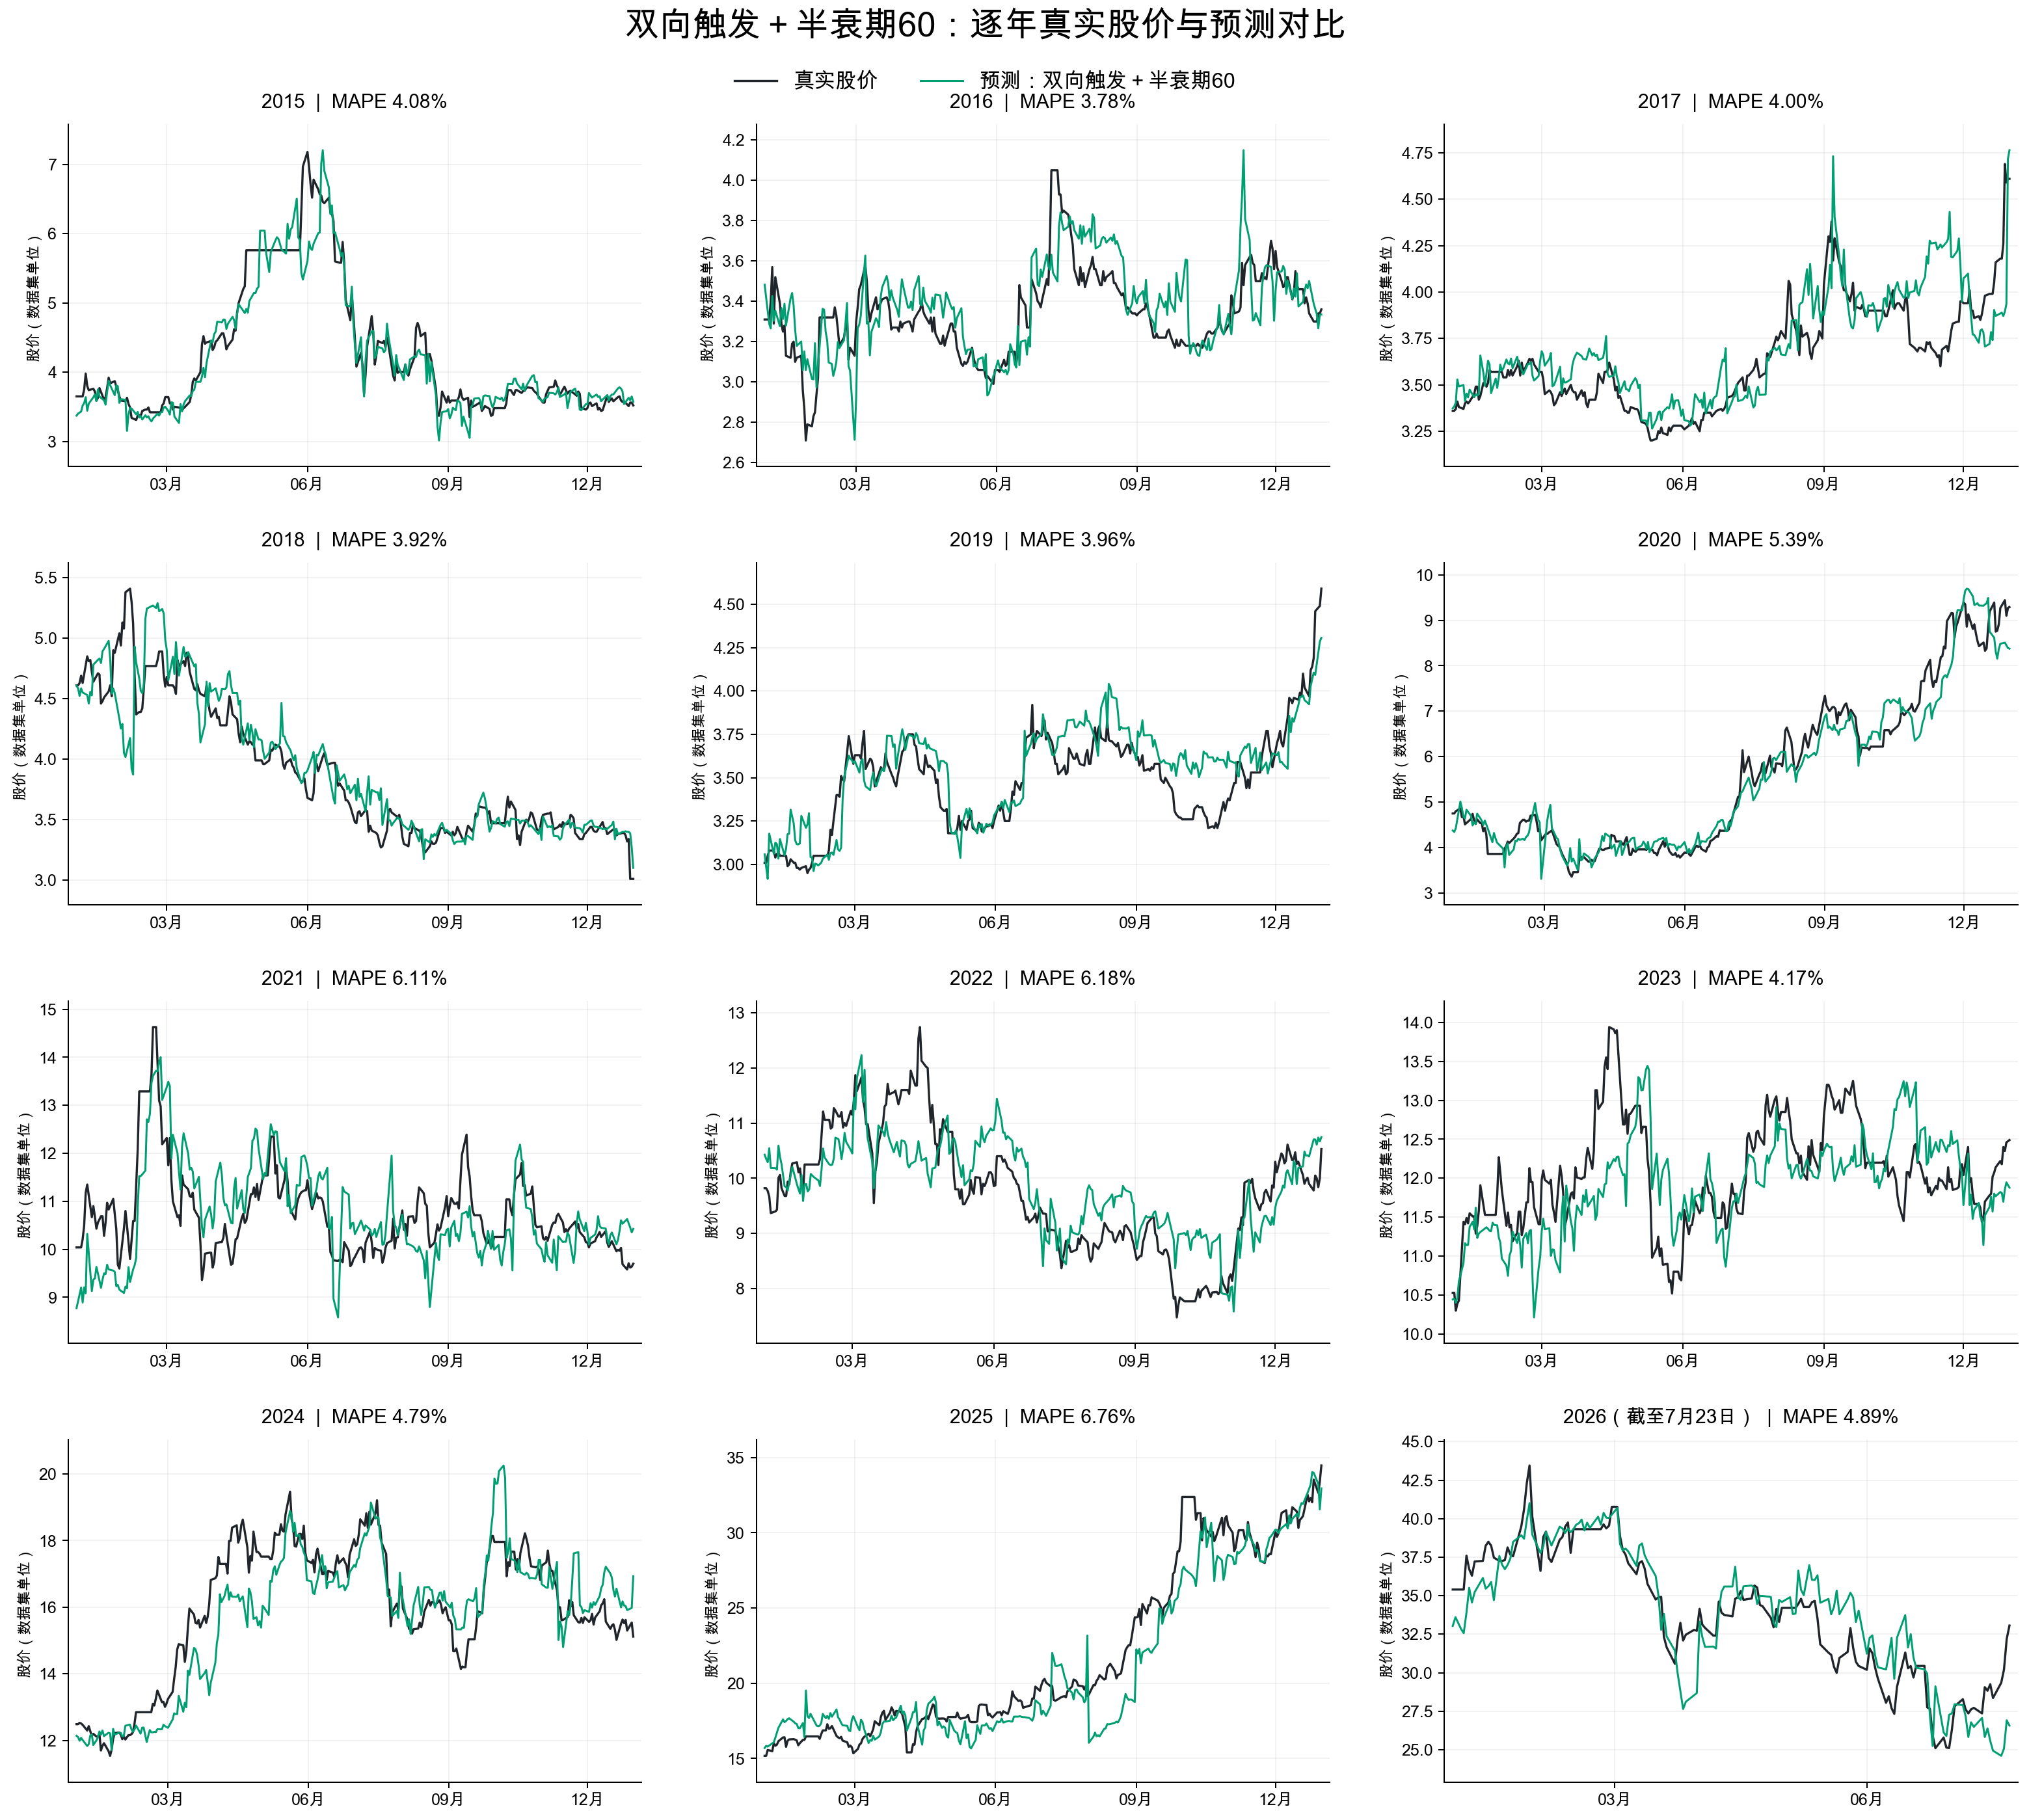

12张年度图＋1张总览图已生成；全部MAPE与上一节保存指标核对一致；未重新训练。


In [1]:
from pathlib import Path
import os,json,hashlib
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.font_manager import FontProperties
from IPython.display import display,Image
ROOT=Path('/Users/admin/数据分析/ZiJin-Mining/ZiJin-Mining-stock-prediction-')
PLOT_OUT=Path(os.environ.get('MLP13_ANNUAL_PLOTS_OUT',str(ROOT/'results/mlp_crossing_h60_annual_plots_13')))
PLOT_OUT.mkdir(parents=True,exist_ok=True)
PRED_SOURCE=PLOT_OUT.parent/'mlp_four_modes_2015_2026_13'
if not (PRED_SOURCE/'predictions.csv').exists():PRED_SOURCE=ROOT/'results/mlp_four_modes_2015_2026_13'
annual_plot_data=pd.read_csv(PRED_SOURCE/'predictions.csv',parse_dates=['Date'])
annual_plot_updates=pd.read_csv(PRED_SOURCE/'updates.csv',parse_dates=['Effective_date'])
annual_plot_metrics=pd.read_csv(PRED_SOURCE/'annual_metrics.csv')
annual_plot_data=annual_plot_data[['Date','Year','Actual','Crossing_H60']].sort_values('Date')
assert annual_plot_data.Date.is_unique and len(annual_plot_data)==3124
assert set(annual_plot_data.Year)==set(range(2015,2027))
assert np.isfinite(annual_plot_data[['Actual','Crossing_H60']]).all().all()
annual_plot_updates=annual_plot_updates[annual_plot_updates.Method=='Crossing_H60'].copy()
font_path=Path('/System/Library/Fonts/Supplemental/Arial Unicode.ttf')
if font_path.exists():plt.rcParams['font.family']=FontProperties(fname=str(font_path)).get_name()
plt.rcParams['axes.unicode_minus']=False
ACTUAL_COLOR='#20252b';PRED_COLOR='#009e73'
plot_manifest=[]
def draw_prediction_year(ax,year,large=False):
    g=annual_plot_data[annual_plot_data.Year==year]
    updates=annual_plot_updates[annual_plot_updates.Year==year].sort_values('Effective_date')
    error=g.Crossing_H60-g.Actual
    mape=float(100*(error.abs()/g.Actual.abs()).mean())
    old=annual_plot_metrics[(annual_plot_metrics.Year==year)&(annual_plot_metrics.Method=='Crossing_H60')].iloc[0]
    assert len(g)==int(old.N) and np.isclose(mape,old.MAPE)
    ax.plot(g.Date,g.Actual,color=ACTUAL_COLOR,lw=1.6 if large else 1.35,label='真实股价',zorder=3)
    ax.plot(g.Date,g.Crossing_H60,color=PRED_COLOR,lw=1.5 if large else 1.2,label='预测：双向触发＋半衰期60',zorder=4)
    title=f'{year}'+('（截至7月23日）' if year==2026 else '')
    ax.set_title(f'{title}  |  MAPE {mape:.2f}%',fontsize=15 if large else 12,pad=10)
    ax.set_ylabel('股价（数据集单位）',fontsize=11 if large else 9)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1 if large else 3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m月'))
    ax.grid(alpha=.16);ax.margins(x=.015,y=.09)
    ax.spines[['top','right']].set_visible(False)
    if large:
        ax.vlines(updates.Effective_date.iloc[1:],0,.045,transform=ax.get_xaxis_transform(),color=PRED_COLOR,alpha=.65,lw=1)
        ax.text(.01,.97,f'{g.Date.min():%Y-%m-%d} 至 {g.Date.max():%Y-%m-%d}  ·  {len(g)}条记录  ·  年内更新{len(updates)-1}次',transform=ax.transAxes,va='top',fontsize=10,color='#515a64')
        ax.legend(loc='upper left',bbox_to_anchor=(0,1.19),ncol=2,frameon=False,fontsize=11)
        ax.set_xlabel('月份；底部绿色短刻度为新模型生效日（不含年初初始化）',fontsize=10,labelpad=12)
    return dict(Year=year,Start=str(g.Date.min().date()),End=str(g.Date.max().date()),N=len(g),MAPE=mape,Updates_excluding_initial=len(updates)-1)
fig,axes=plt.subplots(4,3,figsize=(18,16))
fig.subplots_adjust(top=.93,bottom=.045,left=.065,right=.99,hspace=.28,wspace=.20)
for ax,year in zip(axes.flat,range(2015,2027)):draw_prediction_year(ax,year)
handles,labels=axes[0,0].get_legend_handles_labels()
fig.legend(handles,labels,loc='upper center',bbox_to_anchor=(.5,.968),ncol=2,frameon=False,fontsize=13)
fig.suptitle('双向触发＋半衰期60：逐年真实股价与预测对比',fontsize=21,y=.99)
fig.savefig(PLOT_OUT/'all_years_predictions.png',dpi=180,bbox_inches='tight');plt.close(fig)
for year in range(2015,2027):
    fig,ax=plt.subplots(figsize=(14,5.6),layout='constrained')
    record=draw_prediction_year(ax,year,large=True)
    name=f'{year}_crossing_h60_prediction.png'
    fig.savefig(PLOT_OUT/name,dpi=170,bbox_inches='tight');plt.close(fig)
    record['File']=name;plot_manifest.append(record)
pd.DataFrame(plot_manifest).to_csv(PLOT_OUT/'plot_manifest.csv',index=False)
annual_plot_data.to_csv(PLOT_OUT/'plot_data.csv',index=False)
(PLOT_OUT/'config.json').write_text(json.dumps(dict(source=str(PRED_SOURCE),predictions_sha256=hashlib.sha256((PRED_SOURCE/'predictions.csv').read_bytes()).hexdigest(),years=list(range(2015,2027)),method='Crossing_H60',retrained=False,individual_charts=12,overview_charts=1),ensure_ascii=False,indent=2))
print('12张年度图＋1张总览图已生成；全部MAPE与上一节保存指标核对一致；未重新训练。')
display(Image(filename=str(PLOT_OUT/'all_years_predictions.png')))


## 各年度独立大图

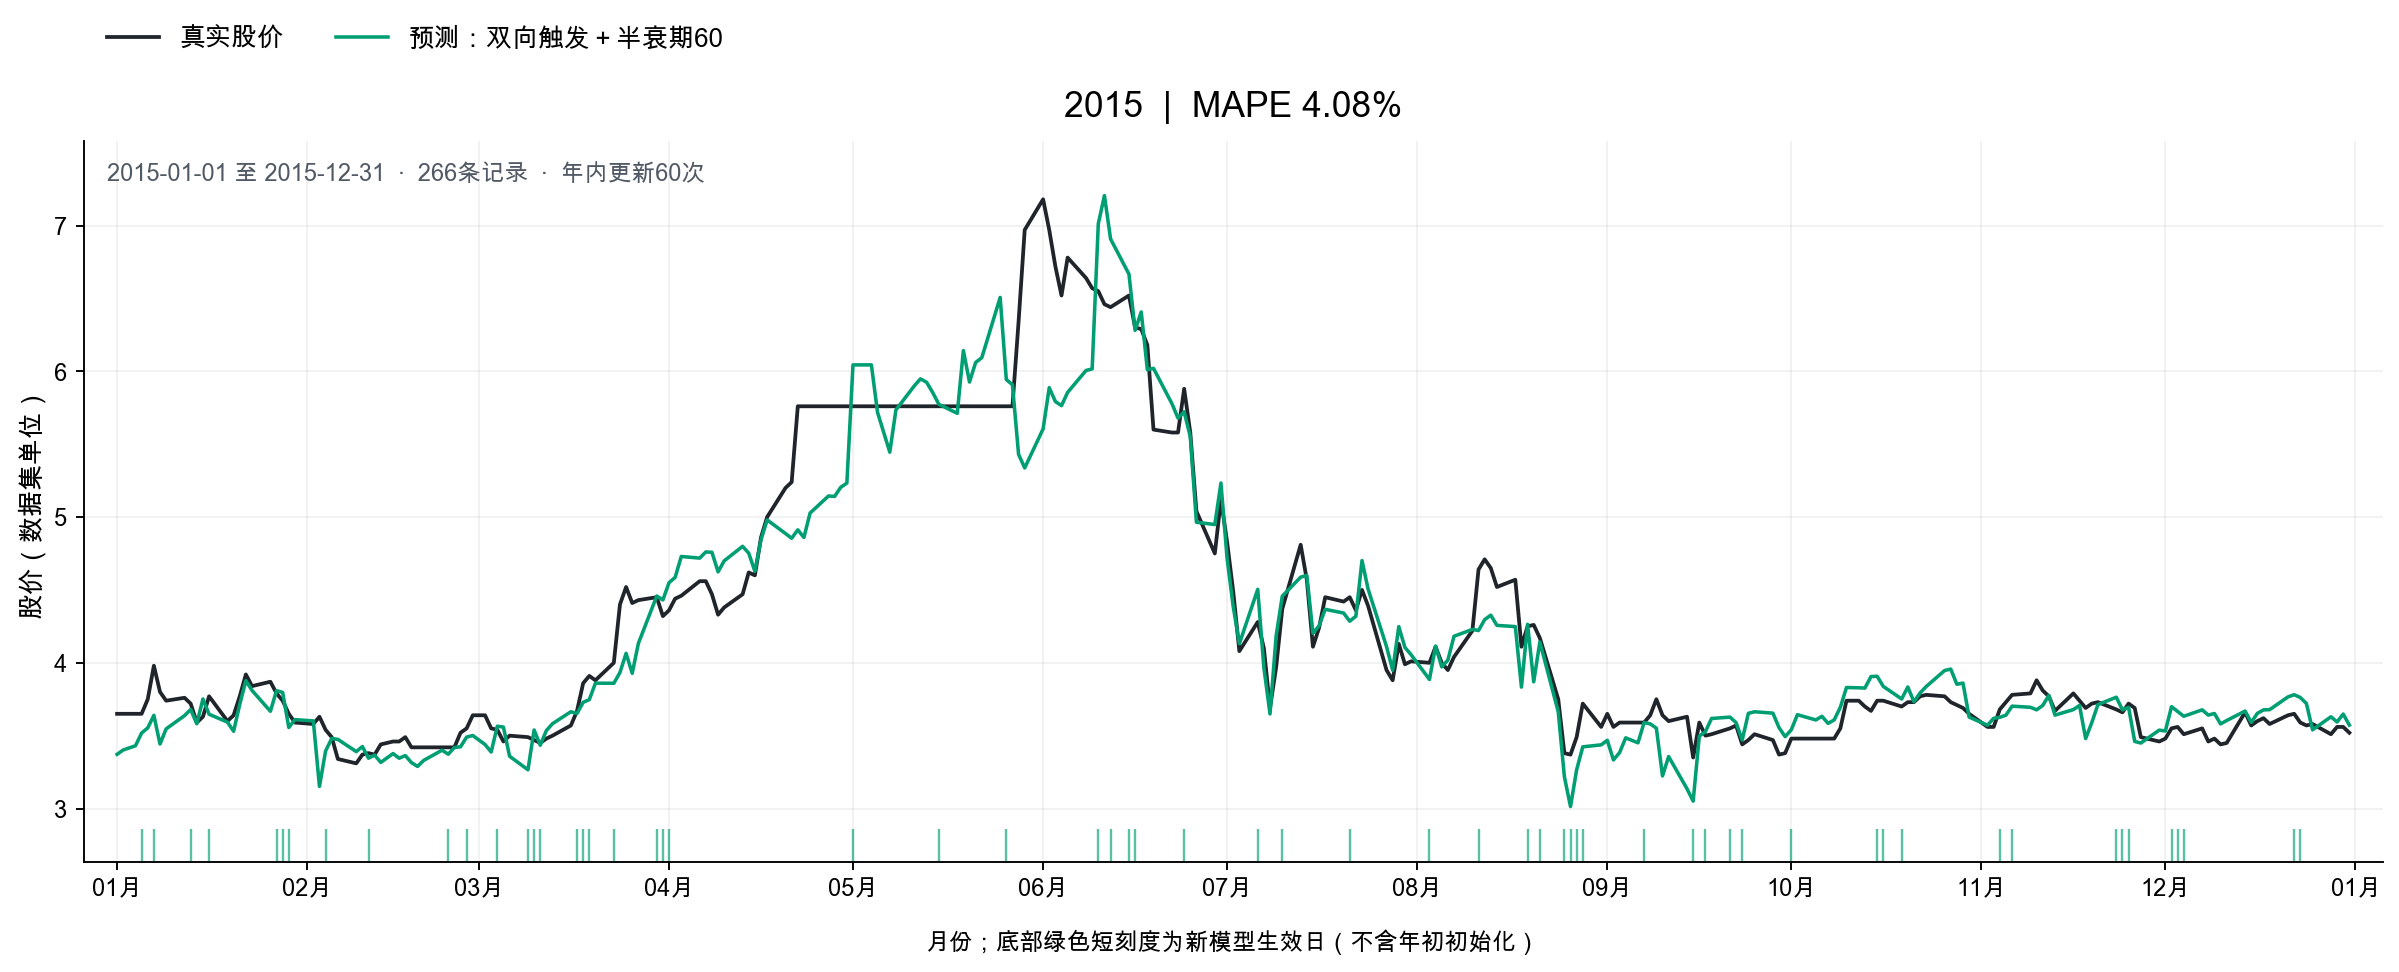

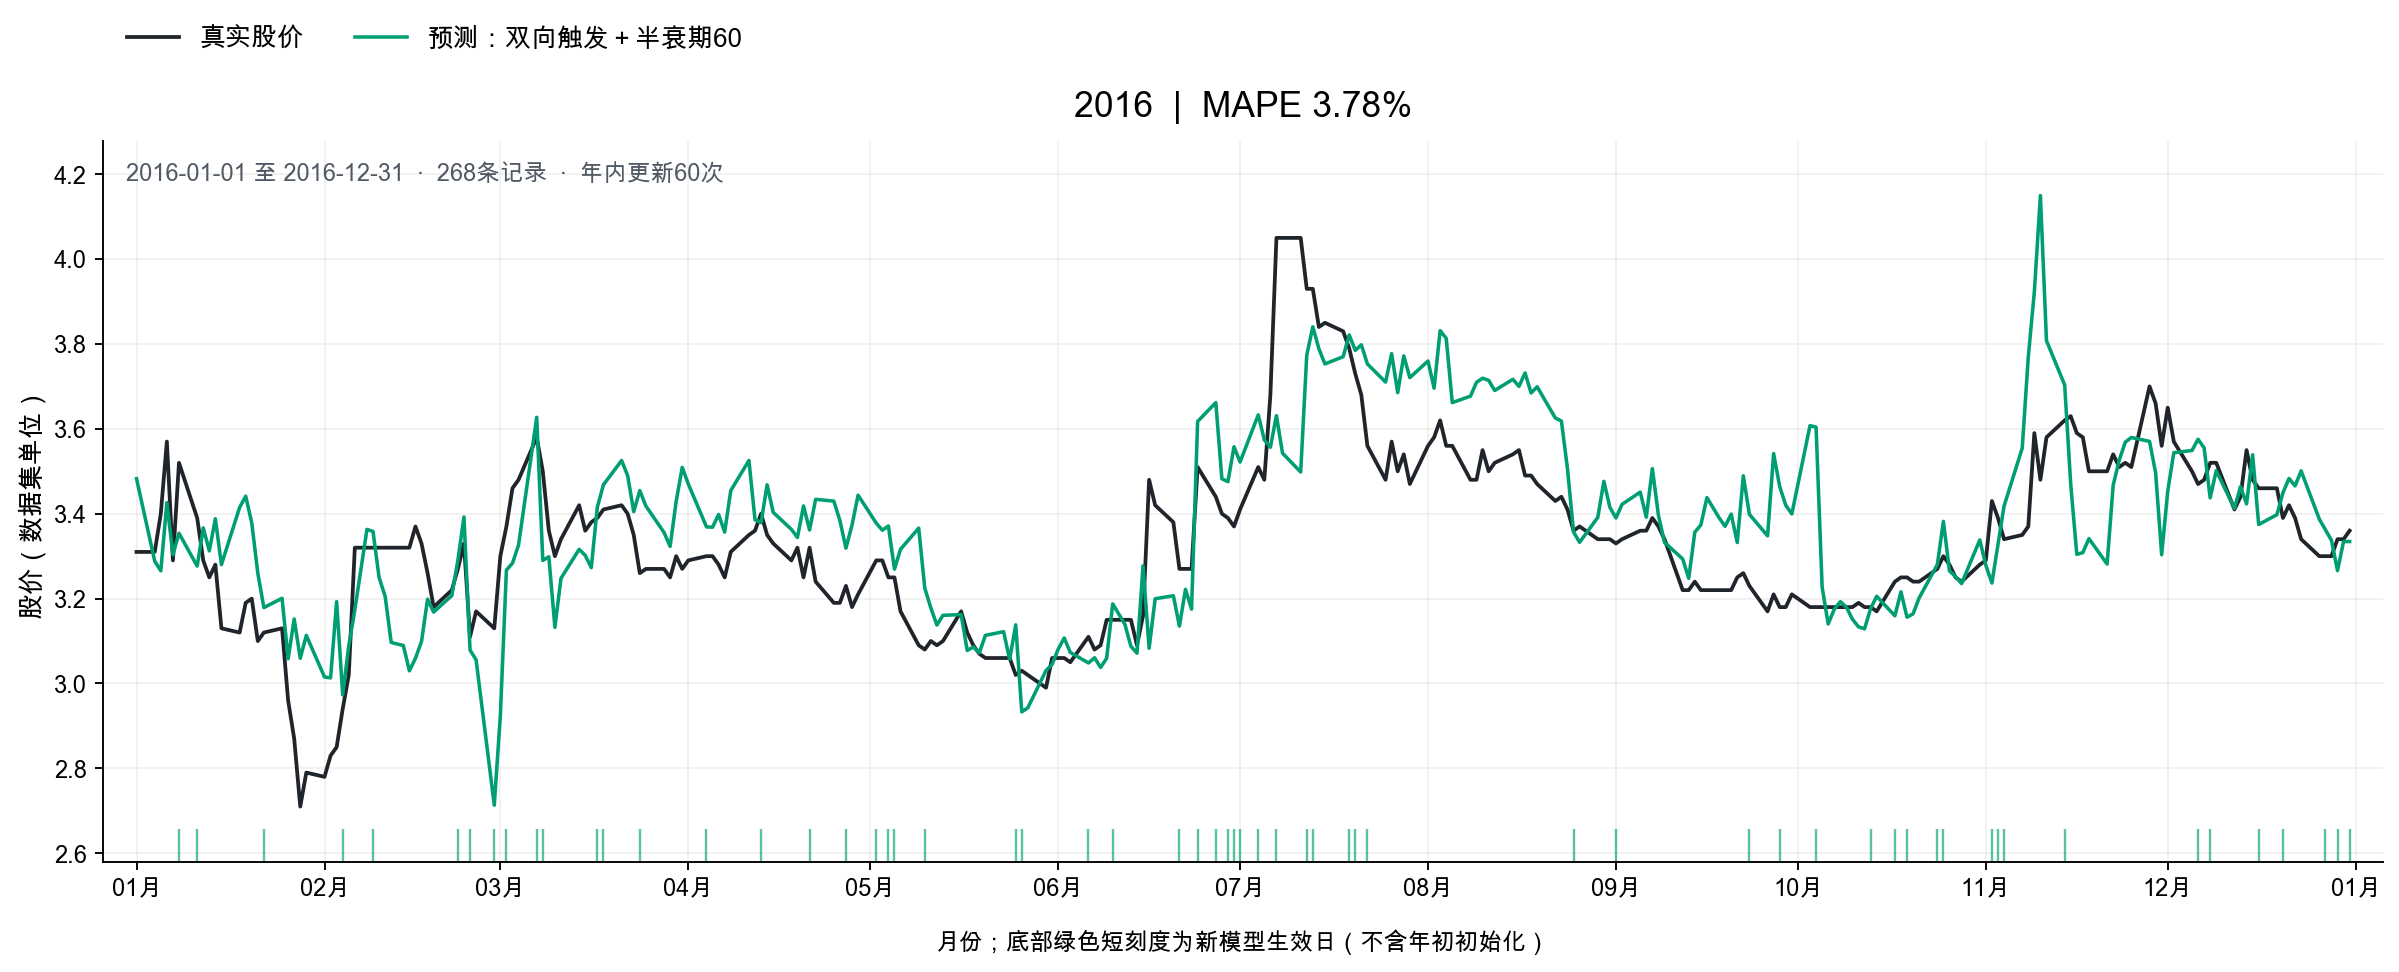

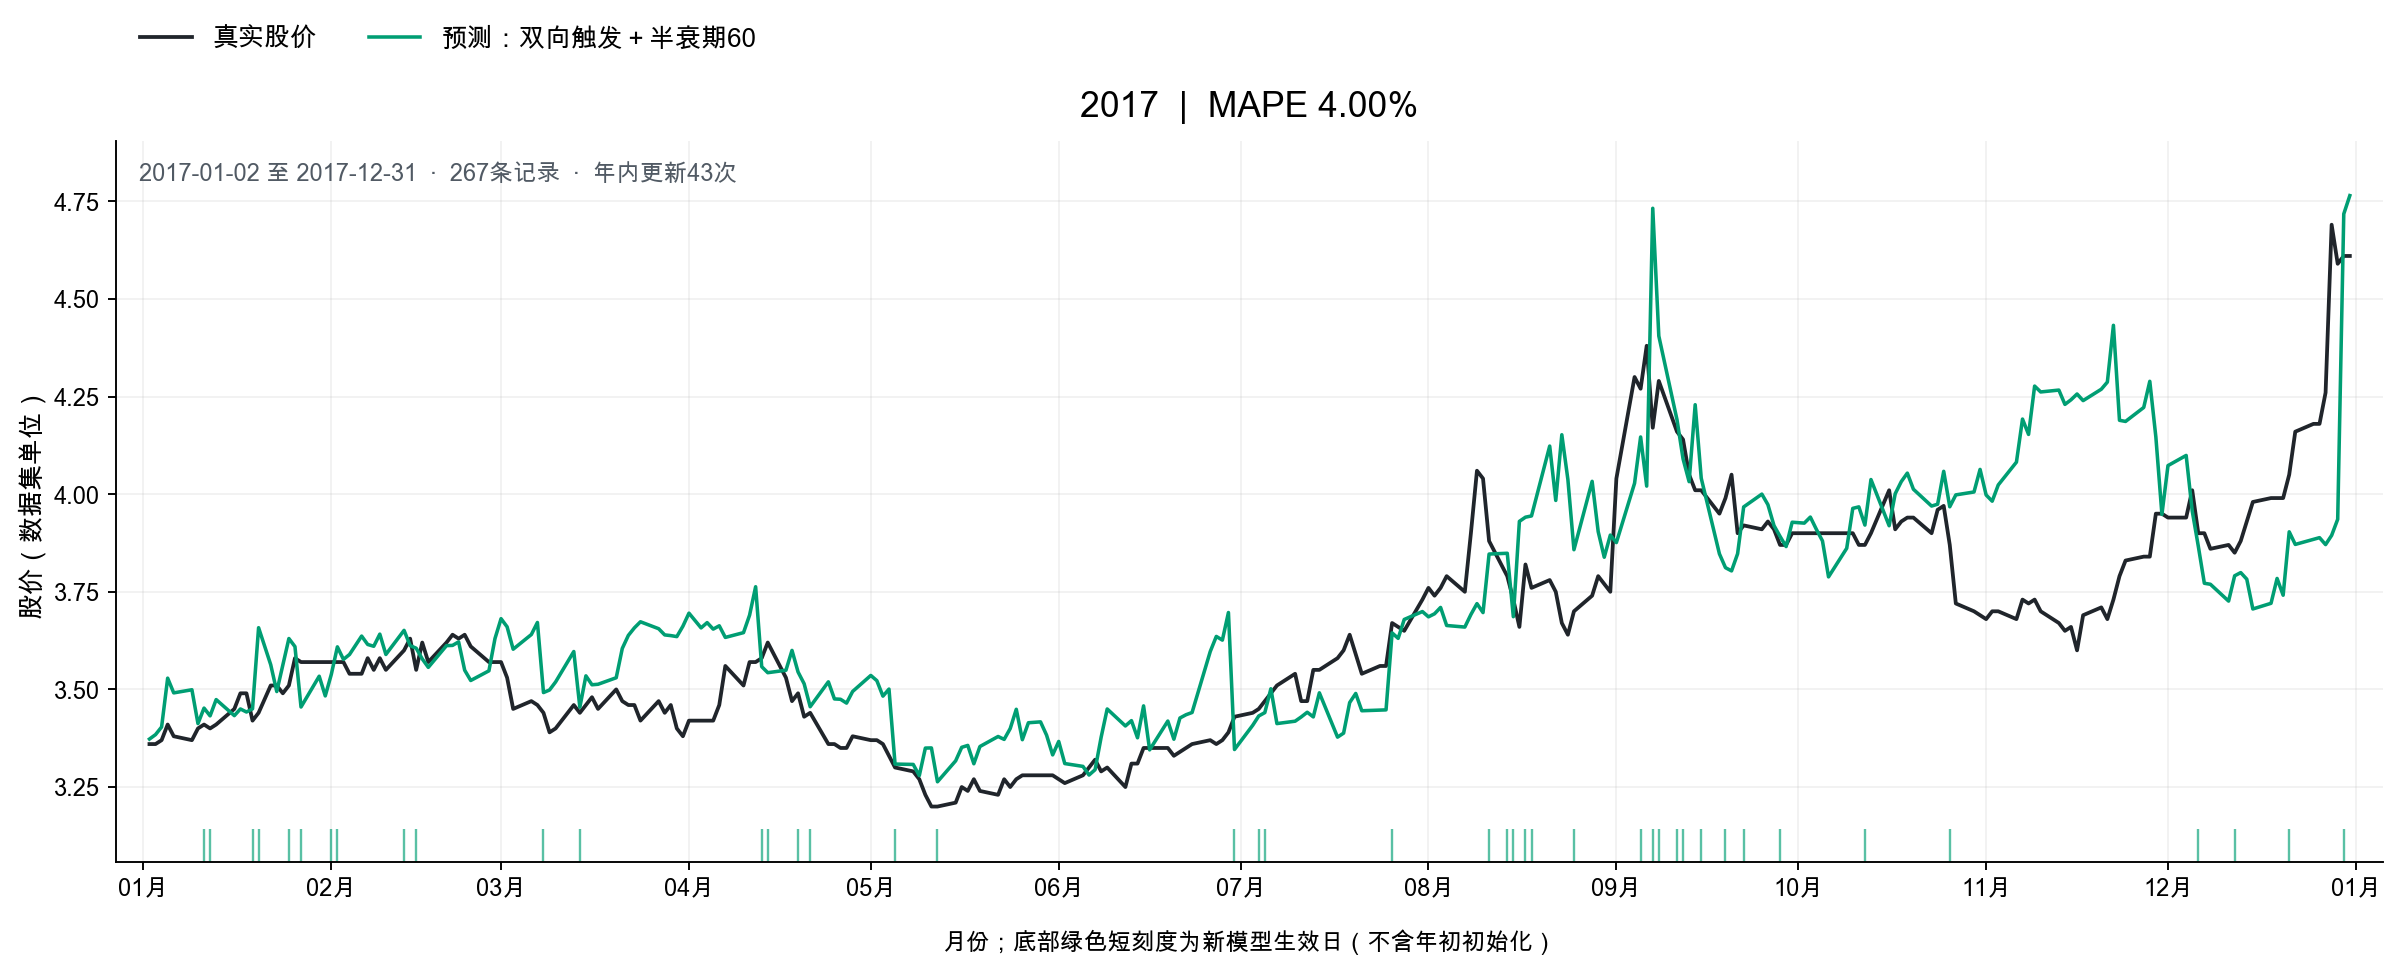

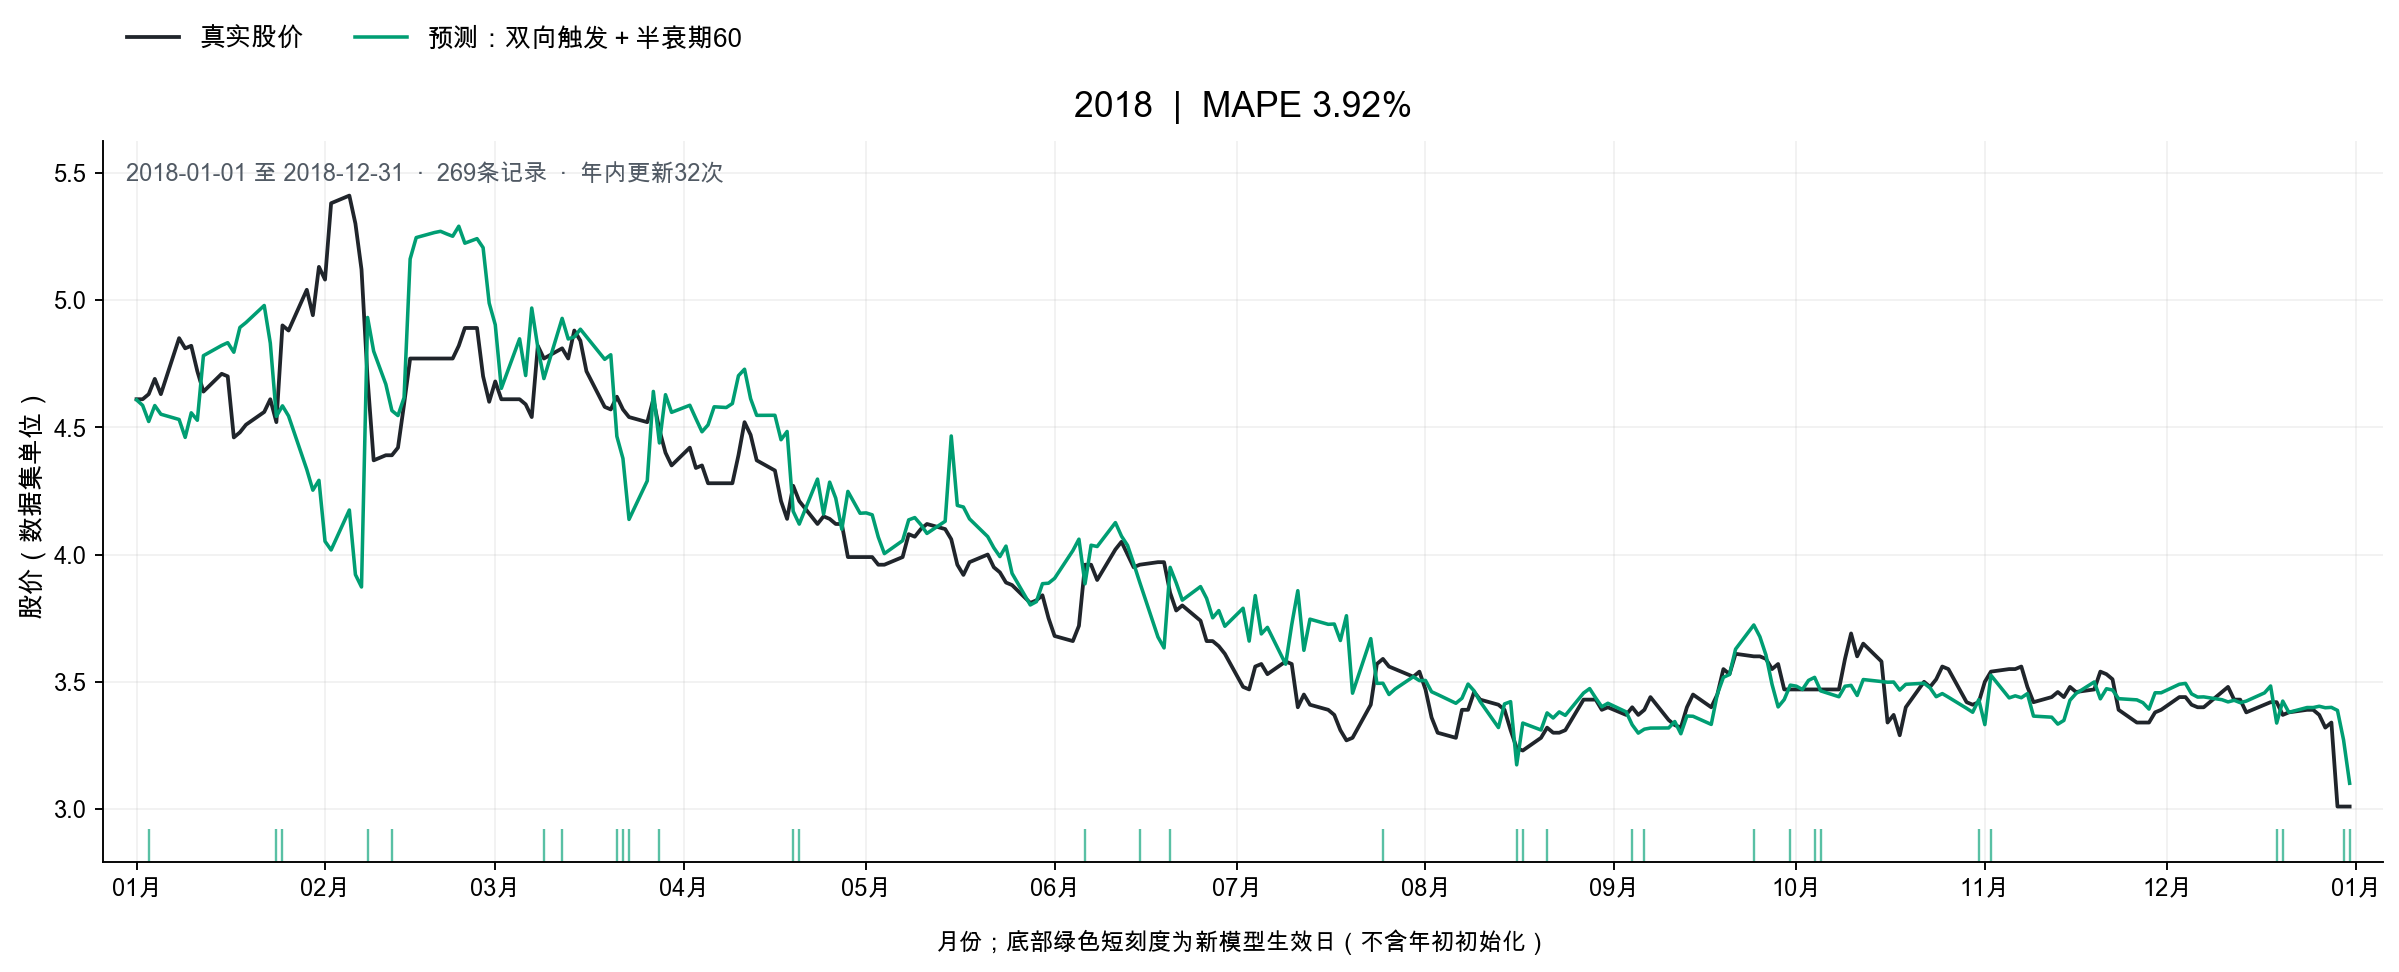

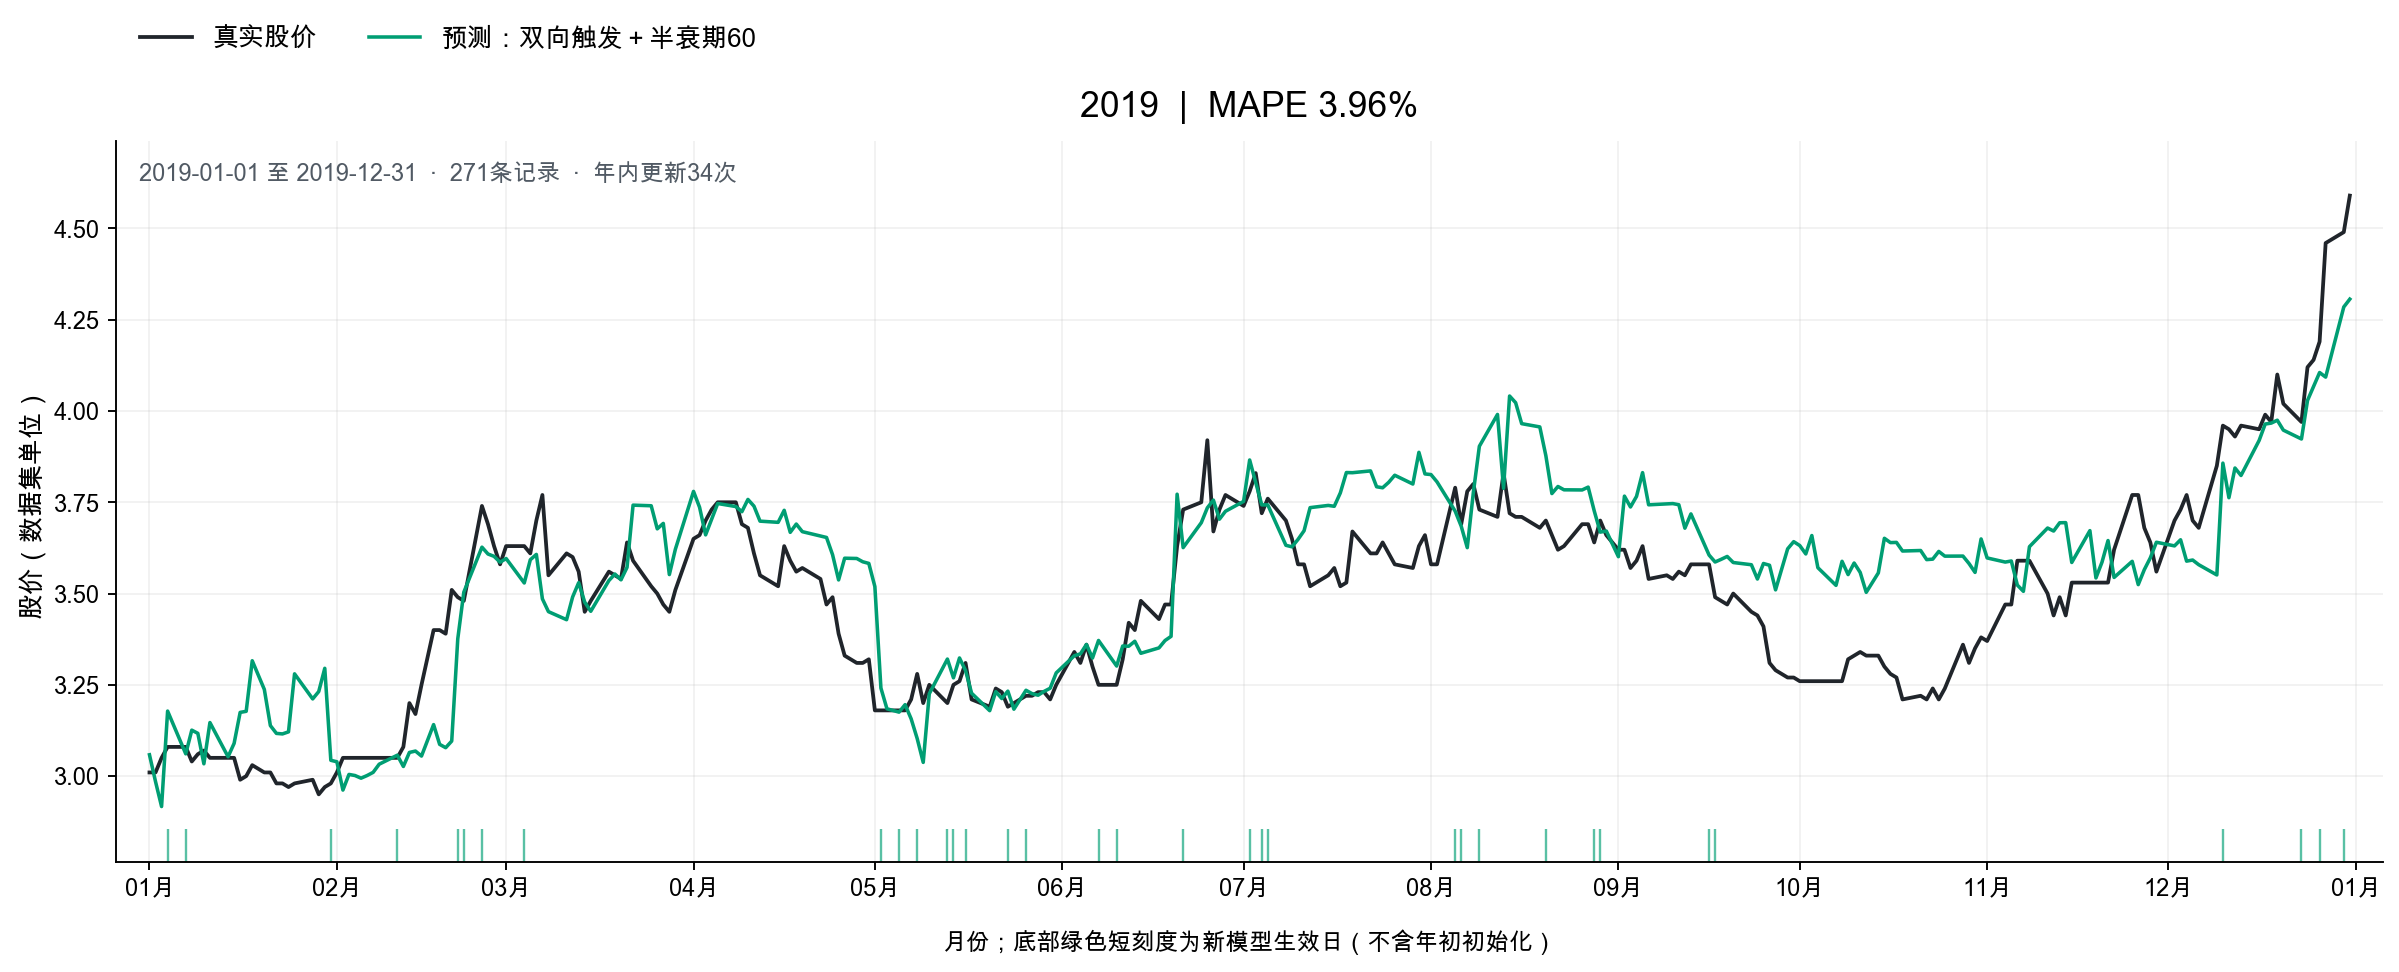

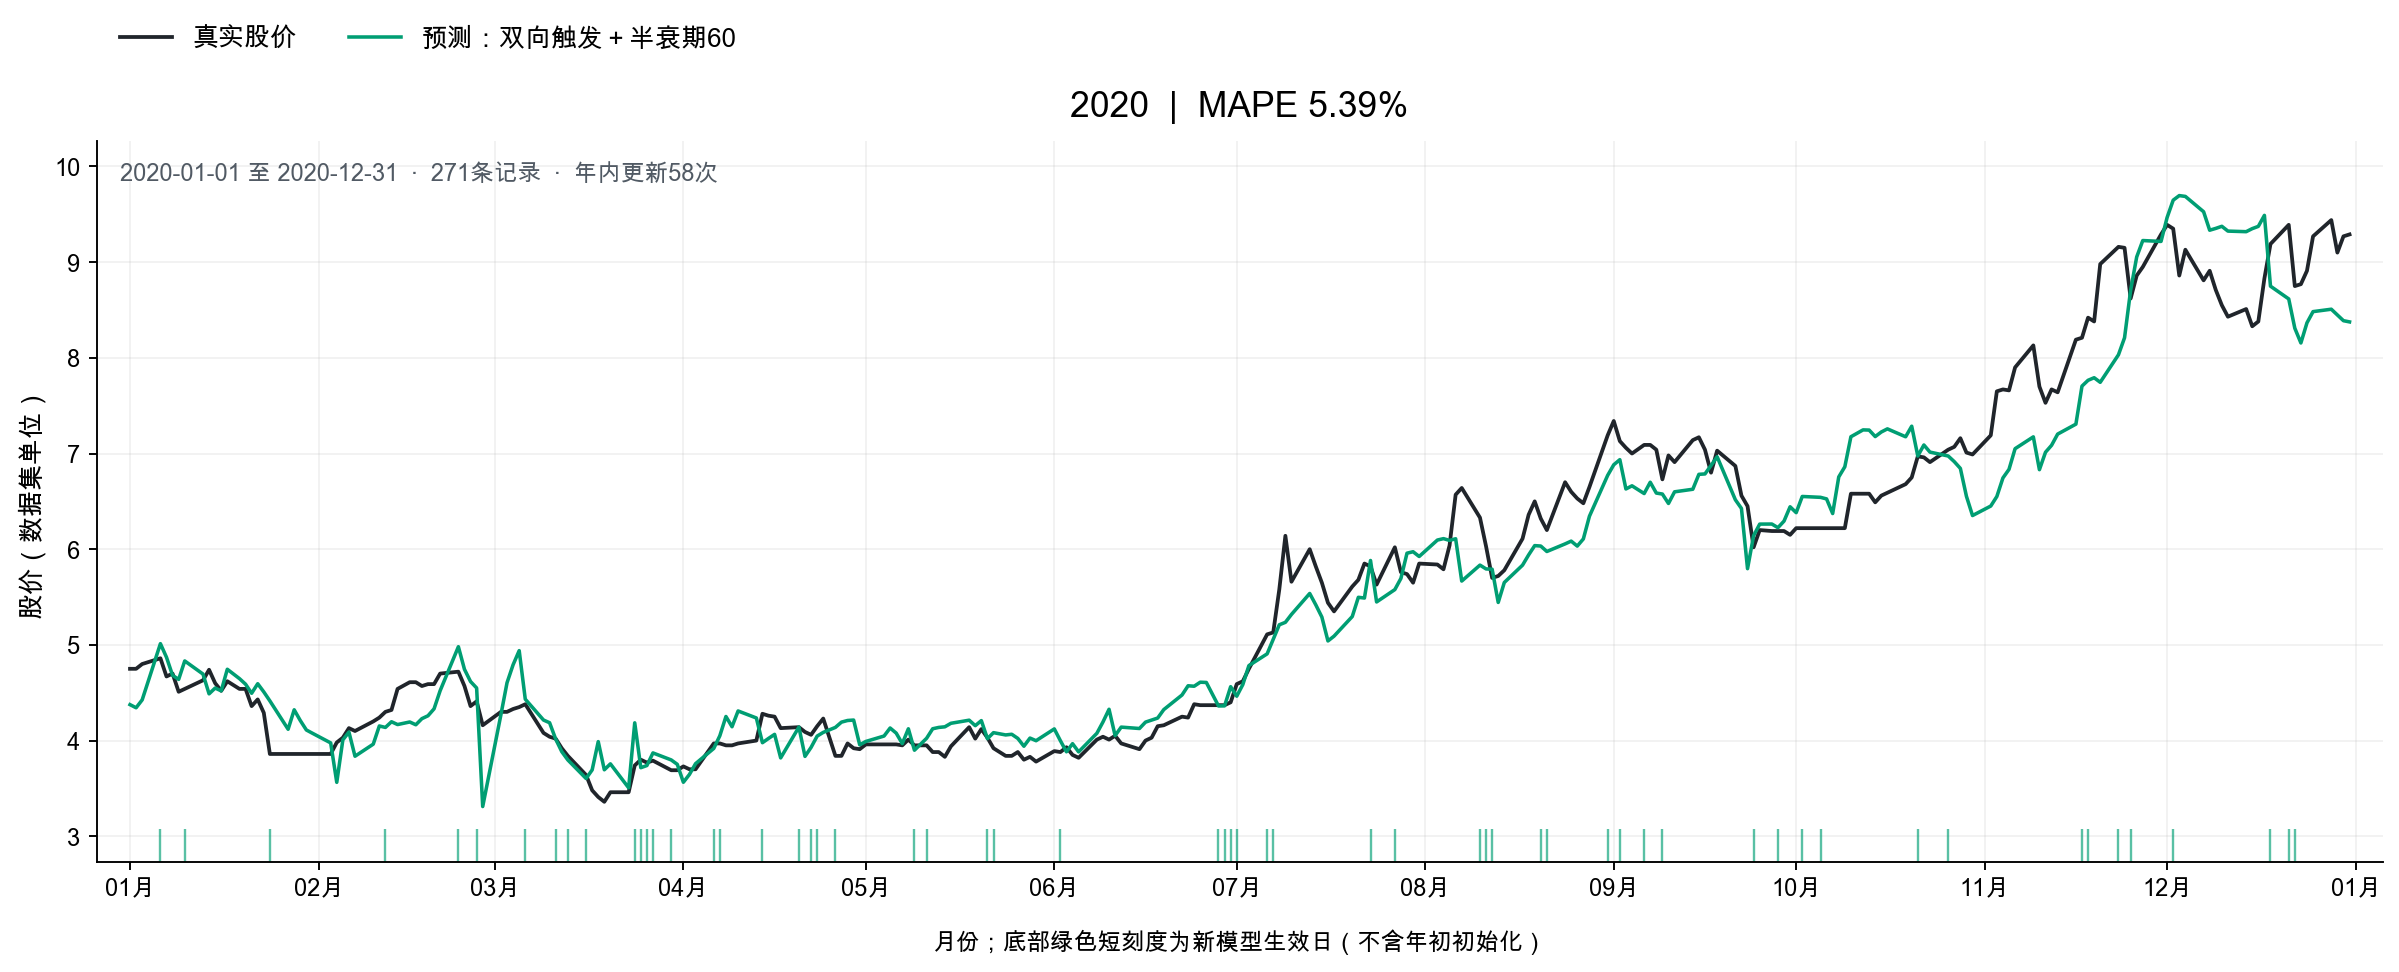

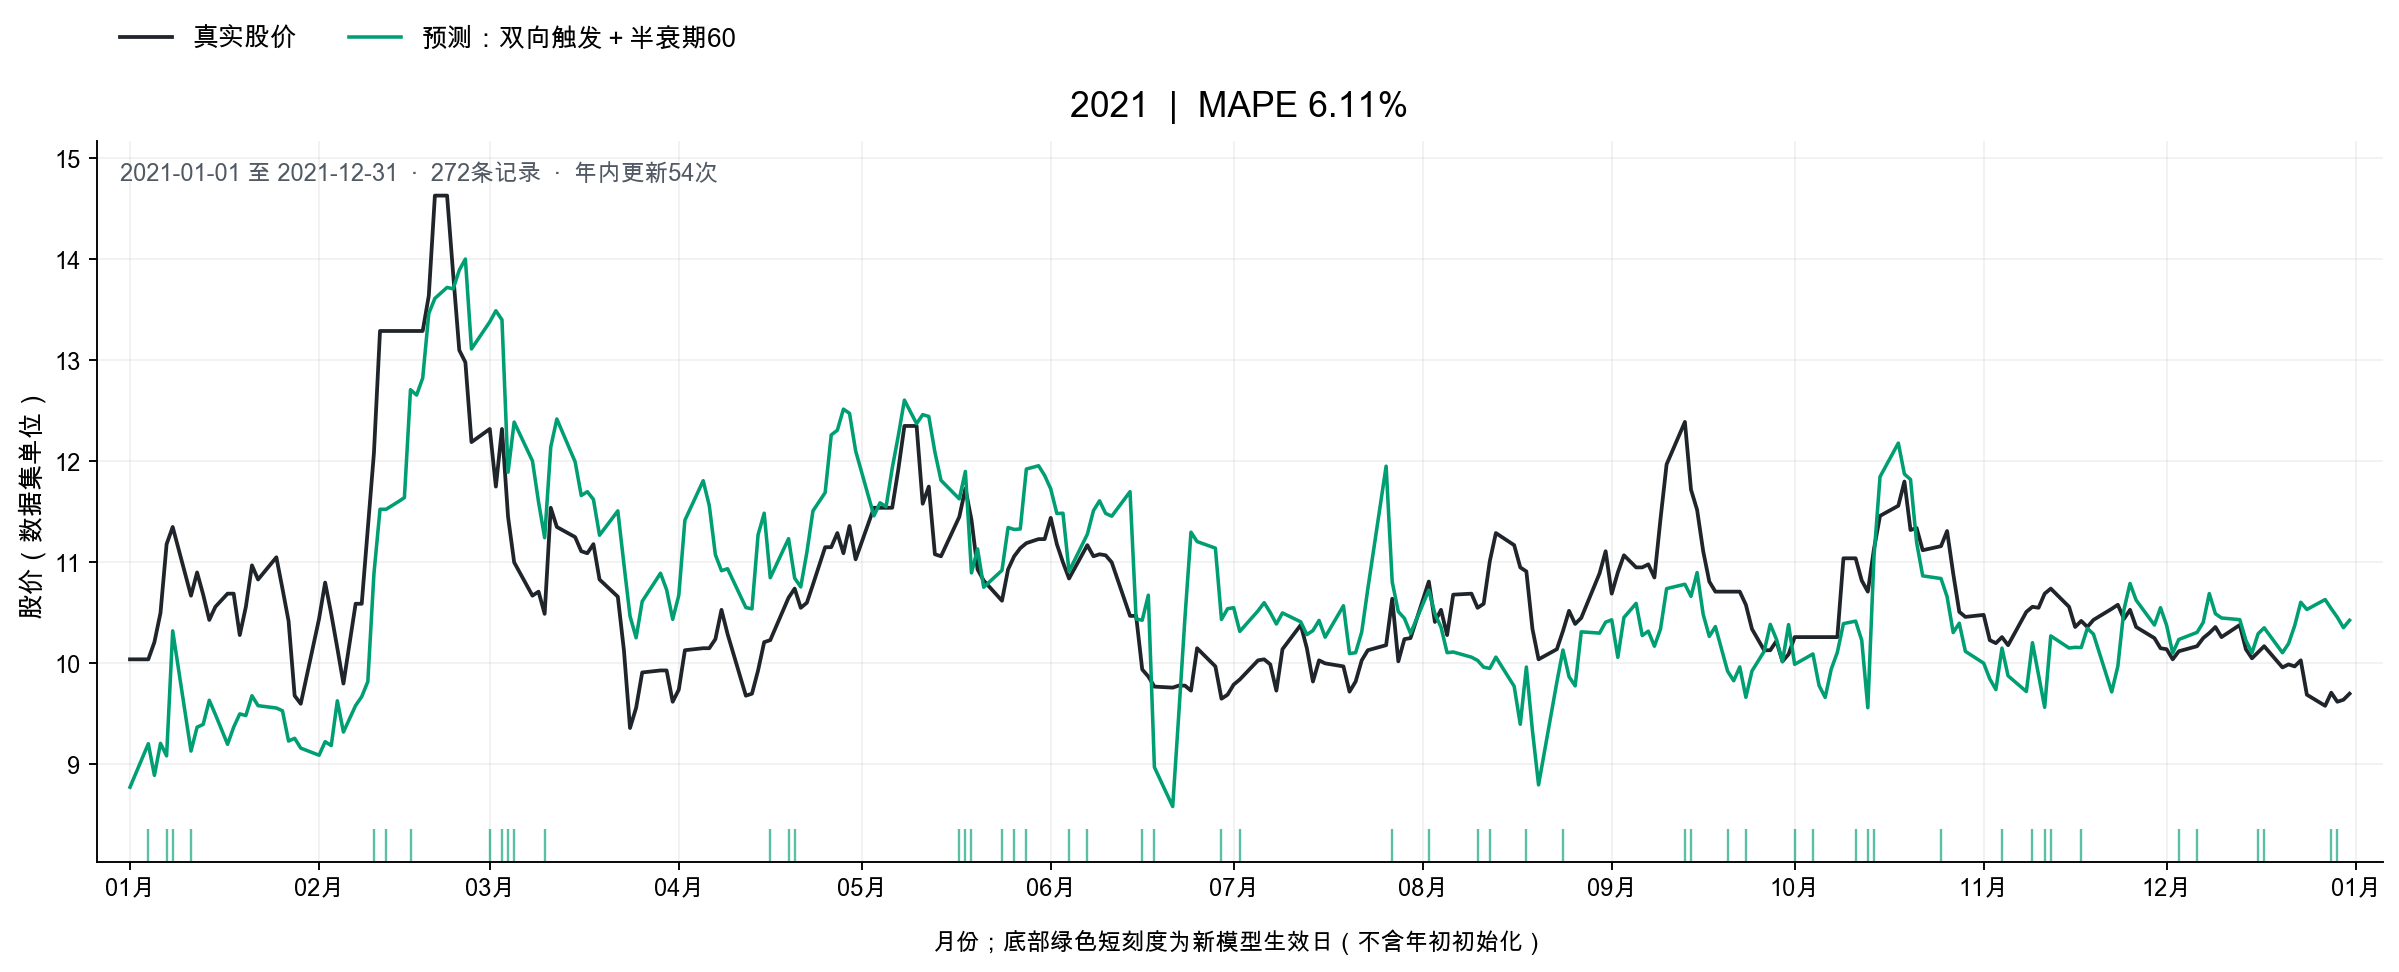

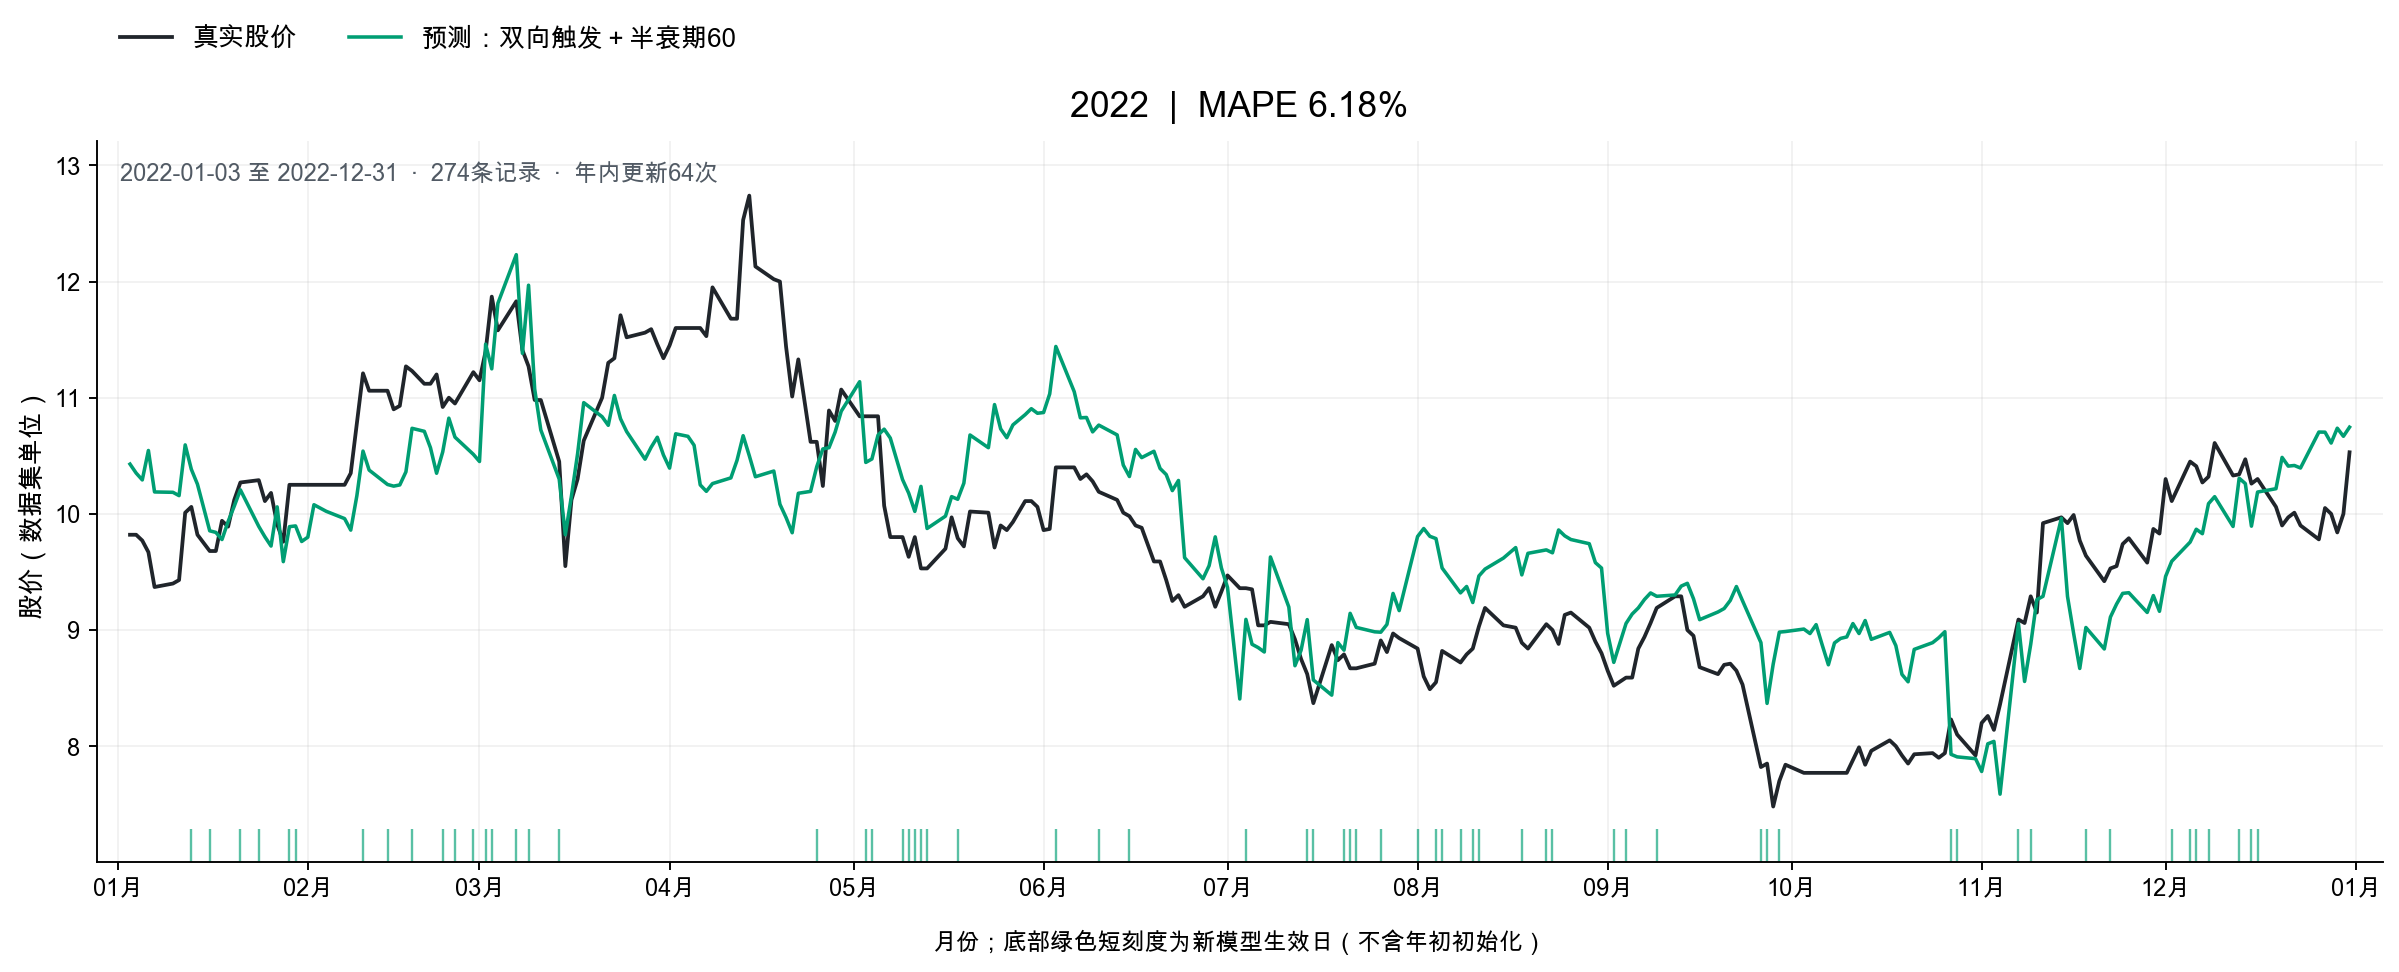

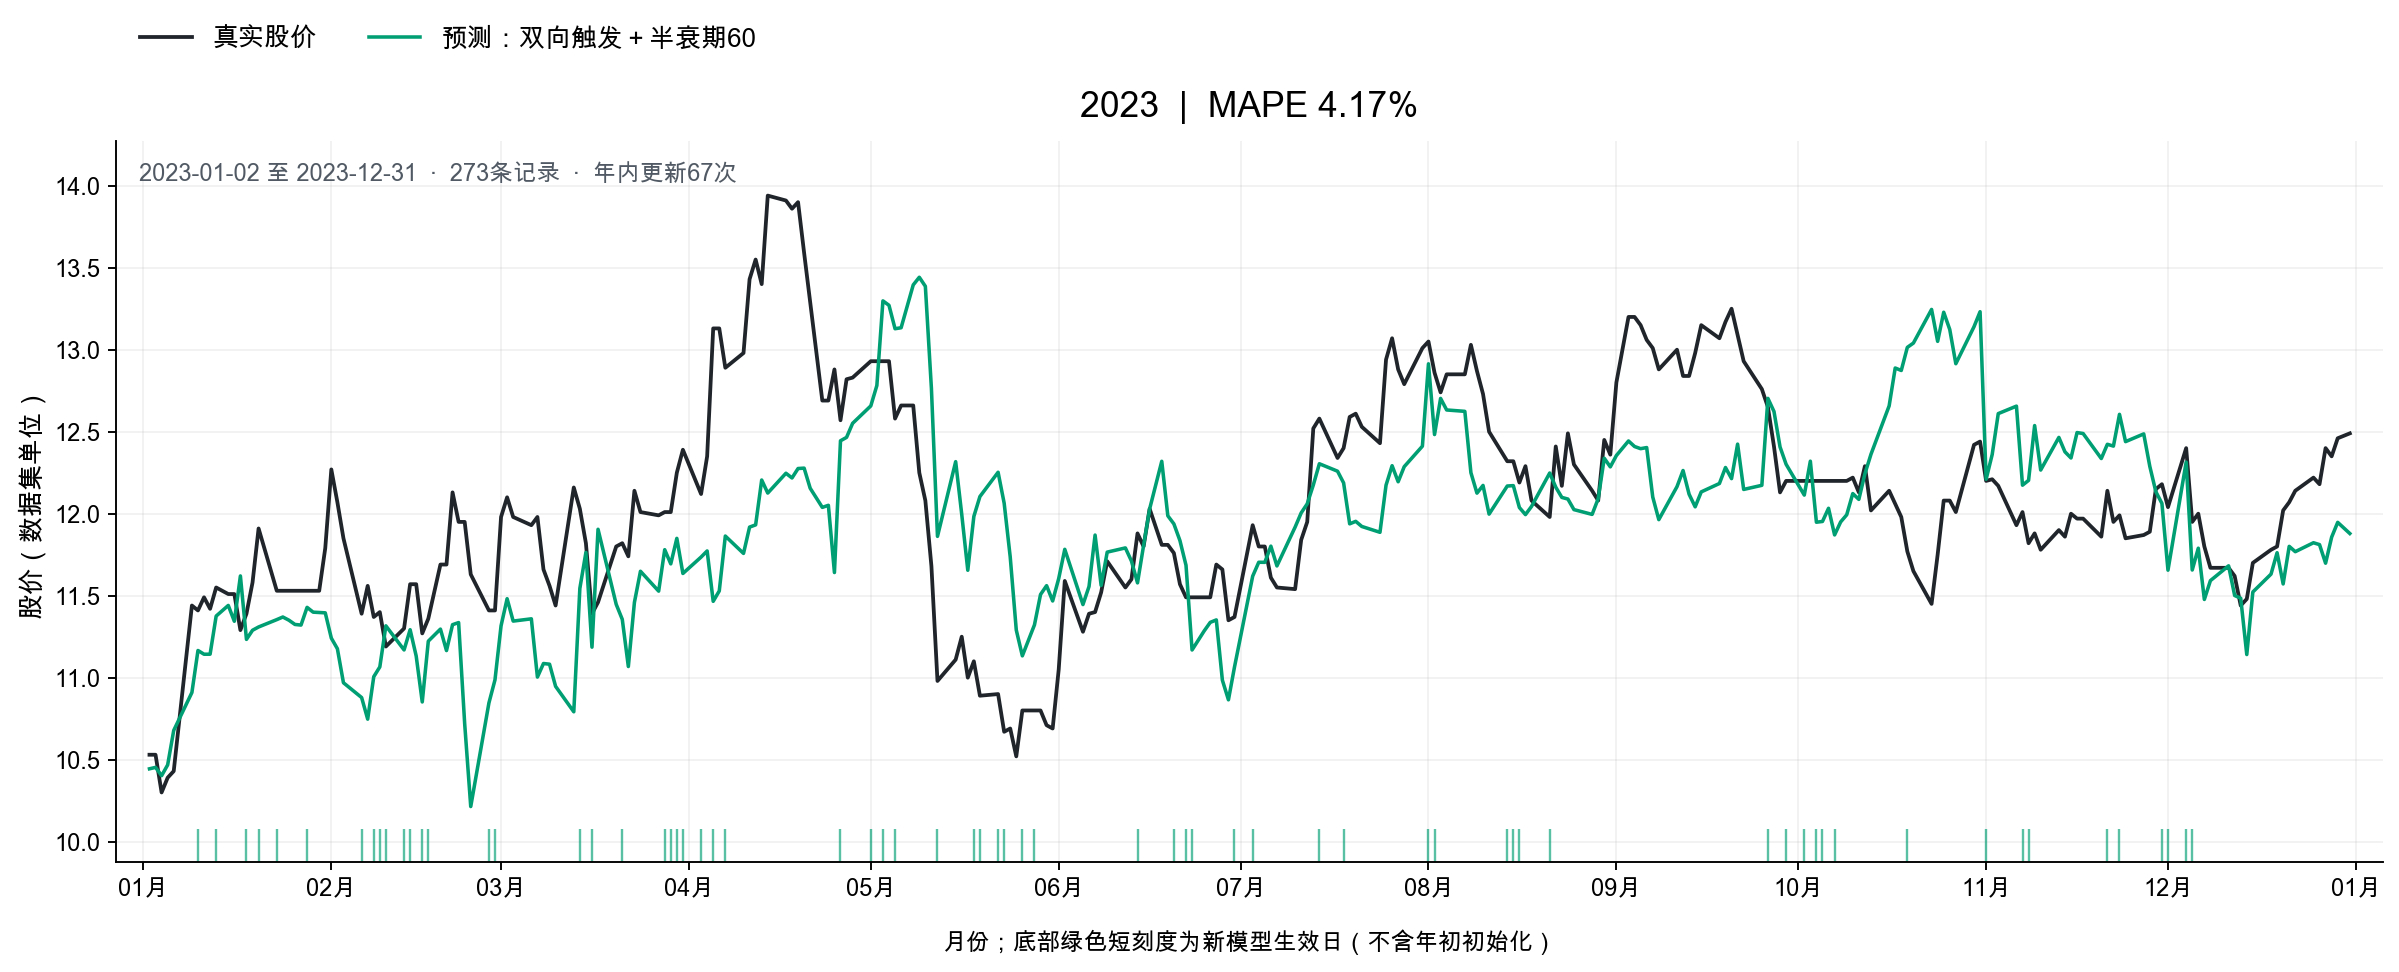

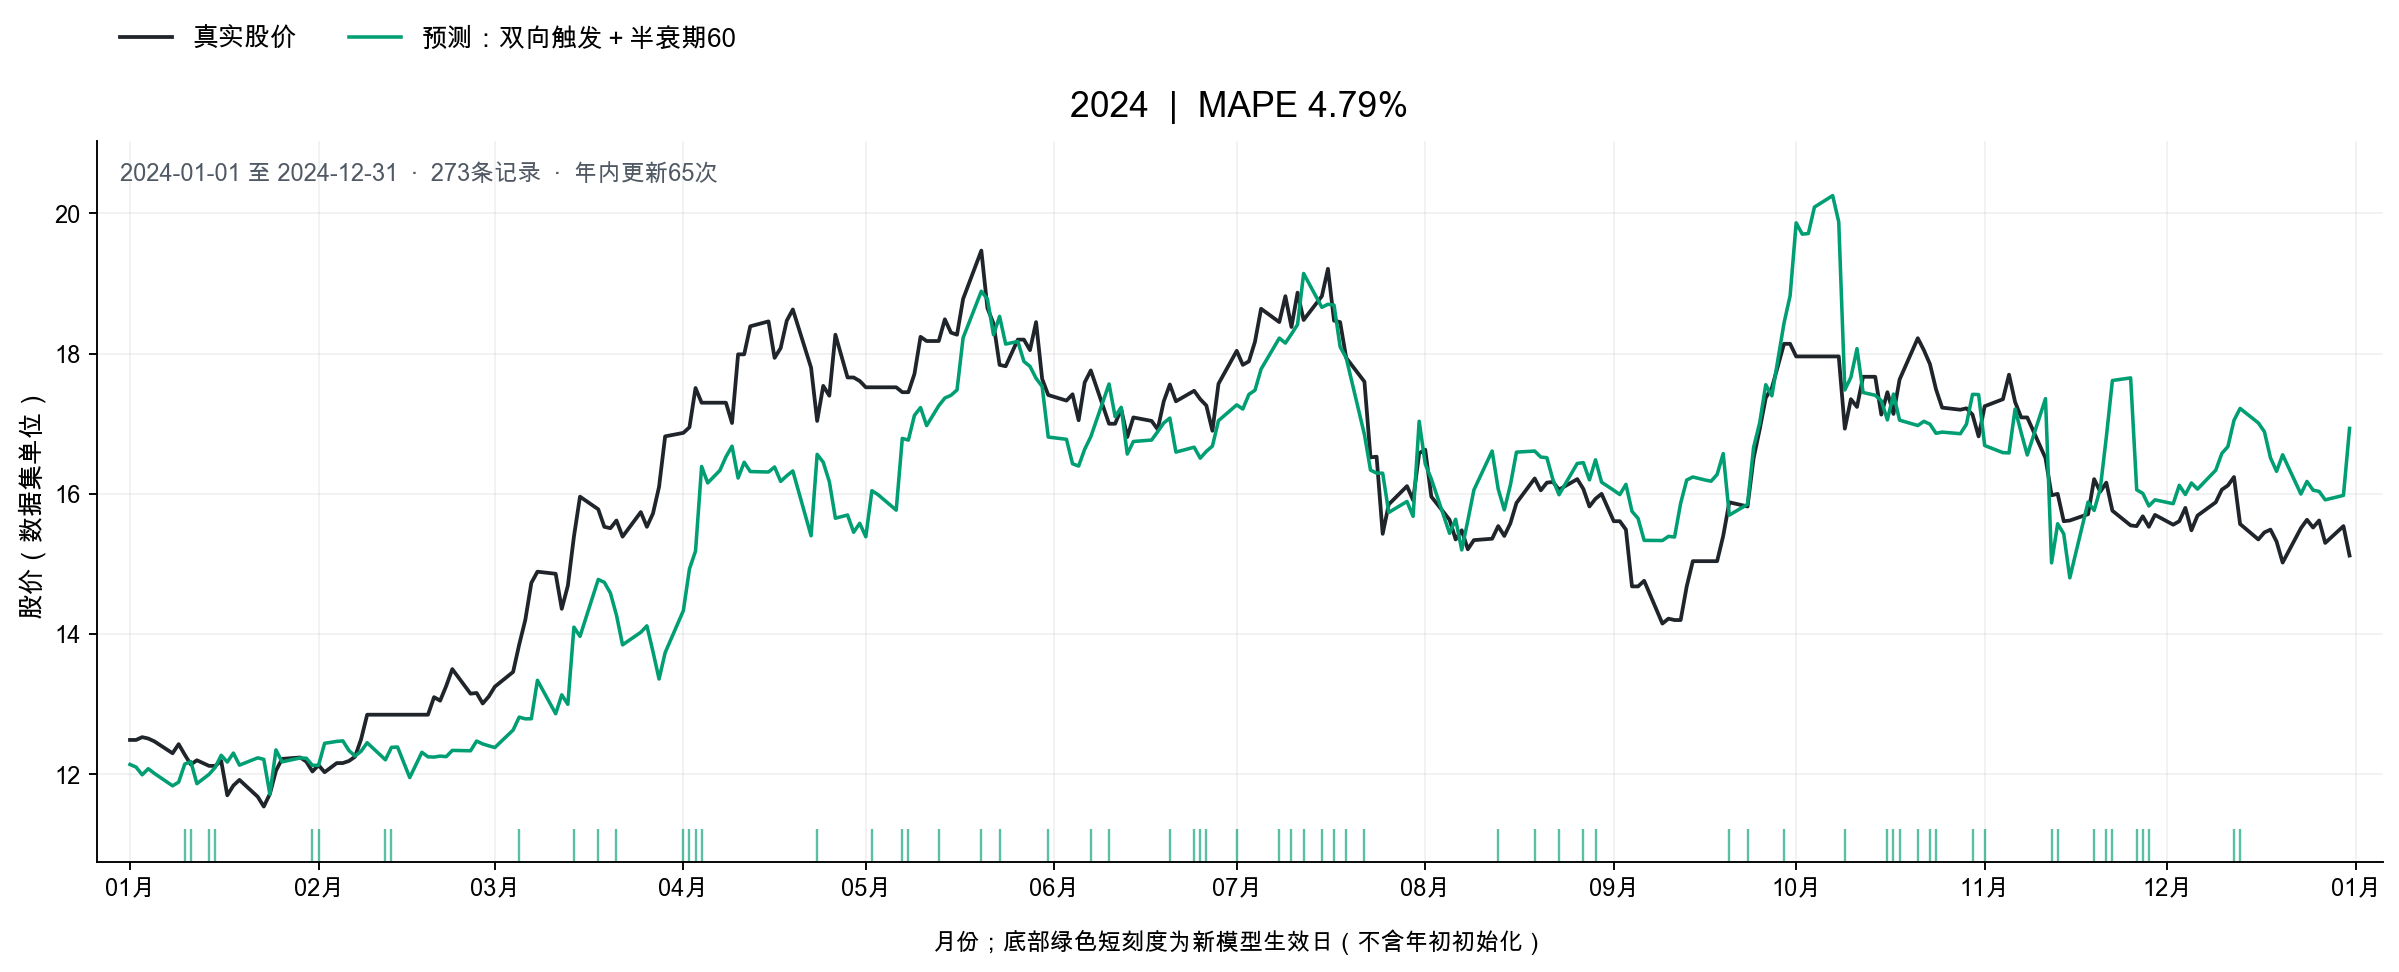

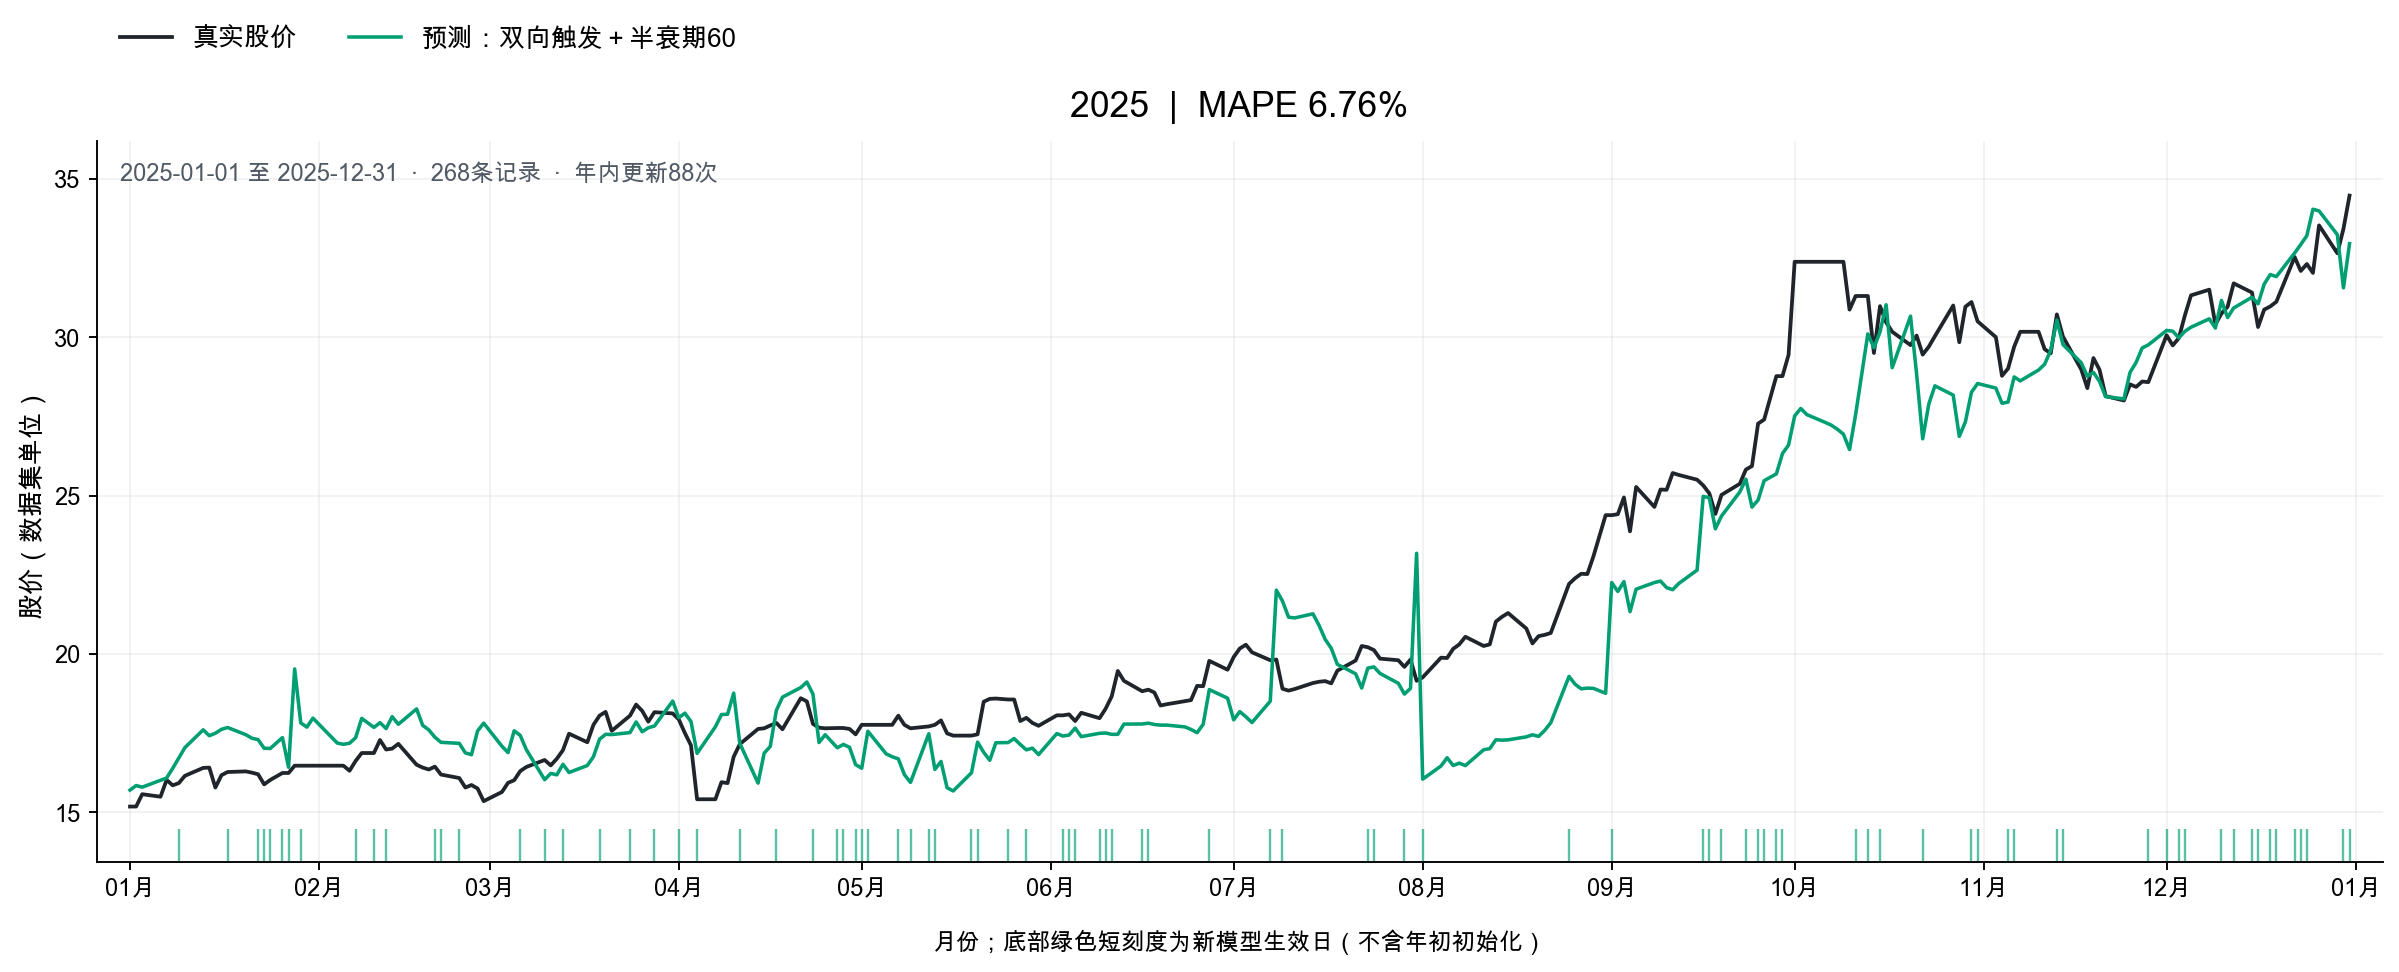

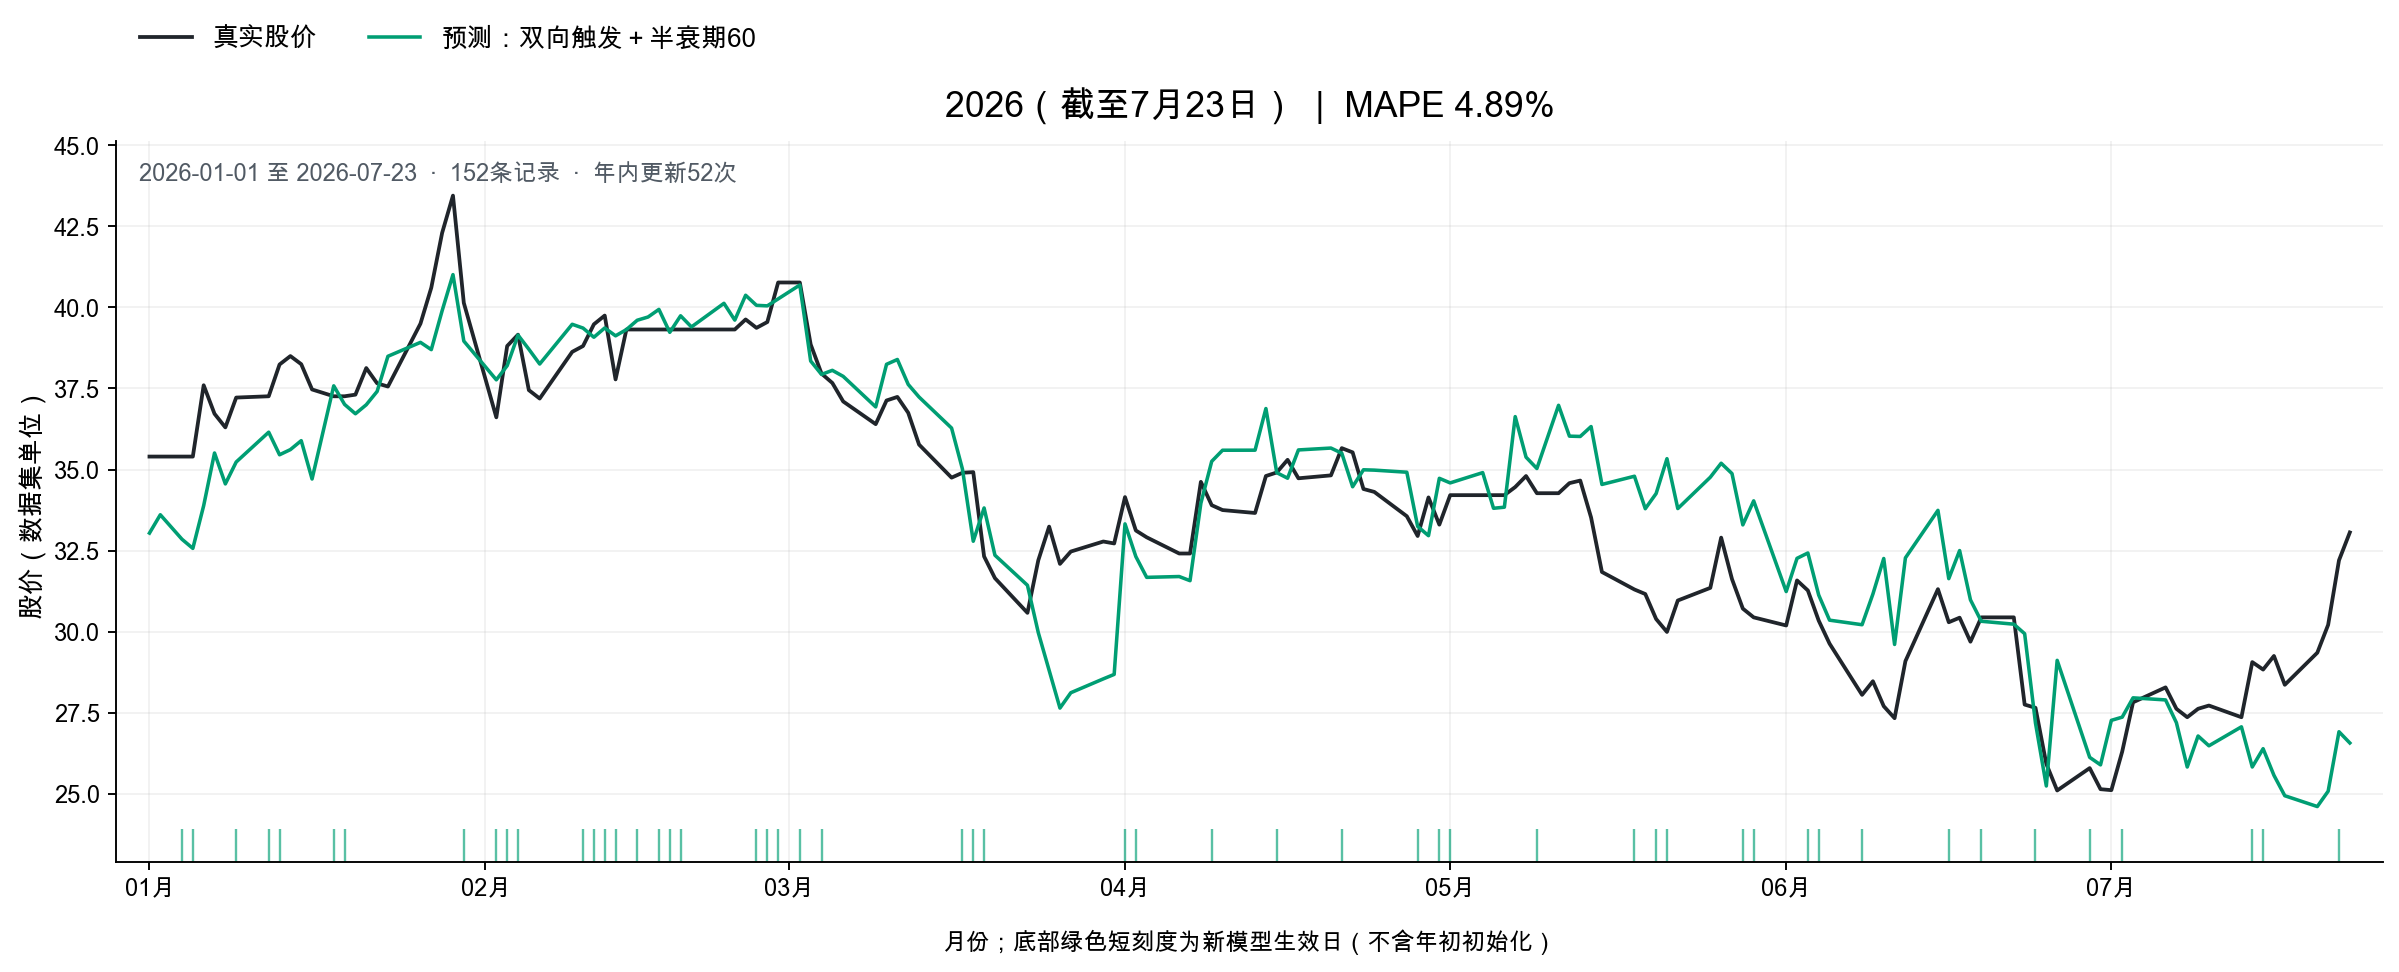

In [2]:
for year in range(2015,2027):
    display(Image(filename=str(PLOT_OUT/f'{year}_crossing_h60_prediction.png')))

从上图看出,尽管MAPE被压的较低,但是具体到折线图上,仍然会出现与趋势明显背离的跳变.  
我们针对20年定的规则,匹配较好.但是对于16,17,19,22,23,25,26年仍然有偏离.下面,我们继续去根据每一年的特征变化情况,增加新的更新条件,看看是否有所改善.